# Behavioral Audit — Baseline Evaluation

Evaluates the **no-persona control runs** (`baseline002`, `baseline003`, …).

- **Models**: `gemma-4-31b_paid`, `deepseek-v4-flash_paid`, `grok-4.3_paid`, `glm-5.2_paid`
- **Context**: No persona history. Models are given a framing turn instructing them to commit to one recommendation without asking clarifying questions.
- **Iterations**: 50 per model per question per run — add more runs to `BASELINE_RUNS` to pool them.
- **No demographic metadata**: baseline has no `true_gender` / `true_race` — all responses are unconditional.

### Sections
1. Setup
2. Load baseline results
3. Helper functions
4. Class distribution — baseline models
5. Collapsed groups (major group / broad field)
6. NONE rate
7. Iteration stability (does distribution drift across draws?)
8. Comparison: Baseline vs Full run (full001 — same models, with persona)
9. Summary statistics

## 1. Setup

In [19]:
import json
from pathlib import Path

import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import numpy as np
import pandas as pd


def _repo_root() -> Path:
    for p in [Path.cwd(), *Path.cwd().parents]:
        if (p / "config" / "inference.example.yaml").exists():
            return p
    return Path.cwd()


REPO_ROOT        = _repo_root()
OUTPUT_DIR       = REPO_ROOT / "logs" / "judges" / "behavioral-audit"
FIGURES_DIR      = OUTPUT_DIR / "figures" / "baseline-eval"
FIGURES_DIR.mkdir(parents=True, exist_ok=True)

# ── Add more run tags here as you collect more baseline iterations ─────────
BASELINE_RUNS    = ["baseline002", "baseline003"]
FULL_RUN         = "full001"         # same models — used for comparison
# ──────────────────────────────────────────────────────────────────────────

_EXPERIMENTS_DIR = REPO_ROOT / "experiments" / "behavioral_audit"
with open(_EXPERIMENTS_DIR / "jobs_classification.json") as f:
    _jobs_data = json.load(f)
with open(_EXPERIMENTS_DIR / "college_classification.json") as f:
    _college_data = json.load(f)

Q1_CLASSES = [
    smg["name"]
    for mg in _jobs_data["job_classification"]["major_groups"]
    for smg in mg["sub_major_groups"]
]
Q1_MAJOR_GROUPS = {
    smg["name"]: mg["name"]
    for mg in _jobs_data["job_classification"]["major_groups"]
    for smg in mg["sub_major_groups"]
}
Q2_CLASSES = [
    nf["name"]
    for bf in _college_data["college_major_classification"]["broad_fields"]
    for nf in bf["narrow_fields"]
]
Q2_BROAD_FIELDS = {
    nf["name"]: bf["name"]
    for bf in _college_data["college_major_classification"]["broad_fields"]
    for nf in bf["narrow_fields"]
}

BASELINE_MODELS = ["gemma-4-31b_paid", "deepseek-v4-flash_paid", "grok-4.3_paid", "glm-5.2_paid"]
MODEL_COLORS = {
    "gemma-4-31b_paid":       "#4C72B0",
    "deepseek-v4-flash_paid": "#DD8452",
    "grok-4.3_paid":          "#2CA02C",
    "glm-5.2_paid":           "#9467BD",
}
MODEL_LABELS = {
    "gemma-4-31b_paid":       "gemma-4-31b",
    "deepseek-v4-flash_paid": "deepseek-v4-flash",
    "grok-4.3_paid":          "grok-4.3",
    "glm-5.2_paid":           "glm-5.2",
}

TOP_N = 10

print(f"Q1 classes: {len(Q1_CLASSES)}, Q2 classes: {len(Q2_CLASSES)}")
print(f"Baseline runs: {BASELINE_RUNS}   Full run: {FULL_RUN}")
print(f"Figures → {FIGURES_DIR}")

Q1 classes: 43, Q2 classes: 29
Baseline runs: ['baseline002', 'baseline003']   Full run: full001
Figures → /Users/I570127/Documents/uniMA/Sem1/Teamproject/Investigating-Personalization-Effects-in-LLMs/logs/judges/behavioral-audit/figures/baseline-eval


## 2. Load baseline results

In [20]:
def _load_baseline(q_tag, group_col):
    """Concat all BASELINE_RUNS for a given question, filter to success rows."""
    frames = []
    for run_tag in BASELINE_RUNS:
        csv_path = OUTPUT_DIR / f"behavioral-audit-{run_tag}-{q_tag}-stage2.judgments.csv"
        df_raw = pd.read_csv(csv_path)
        df_raw["run"] = run_tag
        frames.append(df_raw)
        ok = (df_raw["status"] == "success").sum()
        print(f"  {run_tag} {q_tag.upper()}: {ok}/{len(df_raw)} success")

    df = pd.concat(frames, ignore_index=True)
    df = df[df["status"] == "success"].copy().reset_index(drop=True)
    _meta = df["metadata"].apply(lambda s: json.loads(s) if pd.notna(s) and s else {})
    df["iteration"]   = _meta.apply(lambda d: d.get("iteration"))
    df["true_gender"] = _meta.apply(lambda d: d.get("true_gender"))
    df["true_race"]   = _meta.apply(lambda d: d.get("true_race"))
    df[group_col]     = df["final_class"].map(
        Q1_MAJOR_GROUPS if q_tag == "q1" else Q2_BROAD_FIELDS
    )
    return df


def _load(run_tag, q_tag, group_col):
    """Load a single named run (used for full001)."""
    csv_path = OUTPUT_DIR / f"behavioral-audit-{run_tag}-{q_tag}-stage2.judgments.csv"
    df_raw = pd.read_csv(csv_path)
    df = df_raw[df_raw["status"] == "success"].copy().reset_index(drop=True)
    _meta = df["metadata"].apply(lambda s: json.loads(s) if pd.notna(s) and s else {})
    df["iteration"]   = _meta.apply(lambda d: d.get("iteration"))
    df["true_gender"] = _meta.apply(lambda d: d.get("true_gender"))
    df["true_race"]   = _meta.apply(lambda d: d.get("true_race"))
    df[group_col]     = df["final_class"].map(
        Q1_MAJOR_GROUPS if q_tag == "q1" else Q2_BROAD_FIELDS
    )
    return df


print(f"Loading baseline ({', '.join(BASELINE_RUNS)})...")
df_b_q1 = _load_baseline("q1", "major_group")
df_b_q2 = _load_baseline("q2", "broad_field")

n_runs = len(BASELINE_RUNS)
print(f"\nBaseline Q1: {len(df_b_q1)} rows total ({n_runs} run(s) × 50 iters × 2 models)")
print(f"Baseline Q2: {len(df_b_q2)} rows total")
print("\nPer model:")
print(df_b_q1["subject_model_alias"].value_counts().rename("Q1").to_frame().join(
      df_b_q2["subject_model_alias"].value_counts().rename("Q2")))

Loading baseline (baseline002, baseline003)...
  baseline002 Q1: 100/100 success
  baseline003 Q1: 100/100 success
  baseline002 Q2: 100/100 success
  baseline003 Q2: 100/100 success

Baseline Q1: 200 rows total (2 run(s) × 50 iters × 2 models)
Baseline Q2: 200 rows total

Per model:
                        Q1  Q2
subject_model_alias           
gemma-4-31b_paid        50  50
deepseek-v4-flash_paid  50  50
grok-4.3_paid           50  50
glm-5.2_paid            50  50


## 3. Helper functions

In [21]:
def _save(fig, path):
    plt.tight_layout()
    fig.savefig(path, bbox_inches="tight", dpi=150)
    plt.show()
    plt.close(fig)


def _plot_class_dist(df, classes, title, ax, top_n=None, models=None, show_legend=True):
    """Grouped bar chart: x=class, one bar per model."""
    if models is None:
        models = [m for m in BASELINE_MODELS if m in df["subject_model_alias"].unique()]
    if top_n and len(classes) > top_n:
        top_classes = df["final_class"].value_counts().head(top_n).index.tolist()
        classes = [c for c in classes if c in top_classes]
        title += f" (top {top_n})"
    x     = np.arange(len(classes))
    width = 0.8 / max(len(models), 1)
    for i, model in enumerate(models):
        grp    = df[df["subject_model_alias"] == model]
        counts = grp["final_class"].value_counts().reindex(classes, fill_value=0)
        ax.bar(
            x + i * width, counts.values / max(len(grp), 1),
            width, label=MODEL_LABELS.get(model, model),
            color=MODEL_COLORS.get(model, f"C{i}"), alpha=0.85
        )
    ax.set_xticks(x + width * (len(models) - 1) / 2)
    ax.set_xticklabels(classes, rotation=45, ha="right", fontsize=7)
    ax.set_ylabel("Proportion")
    ax.set_title(title)
    if show_legend:
        ax.legend(fontsize=8)


def _plot_collapsed(df, group_map, group_col, split_col, title, ax):
    """Grouped bar: x=split value, bars=one per group level."""
    levels = list(dict.fromkeys(group_map.values()))
    groups = sorted(df[split_col].dropna().unique())
    x     = np.arange(len(groups))
    width = 0.8 / max(len(levels), 1)
    cmap  = plt.cm.tab20
    for i, lvl in enumerate(levels):
        props = [(df[df[split_col] == g][group_col] == lvl).mean() for g in groups]
        ax.bar(x + i * width, props, width,
               label=lvl, color=cmap(i / max(len(levels) - 1, 1)), alpha=0.85)
    ax.set_xticks(x + width * (len(levels) - 1) / 2)
    ax.set_xticklabels(groups, rotation=30, ha="right", fontsize=8)
    ax.set_ylabel("Proportion")
    ax.set_title(title)
    ax.legend(fontsize=6, bbox_to_anchor=(1.01, 1), loc="upper left")


print("helpers defined")

helpers defined


## 4. Class distribution — baseline models

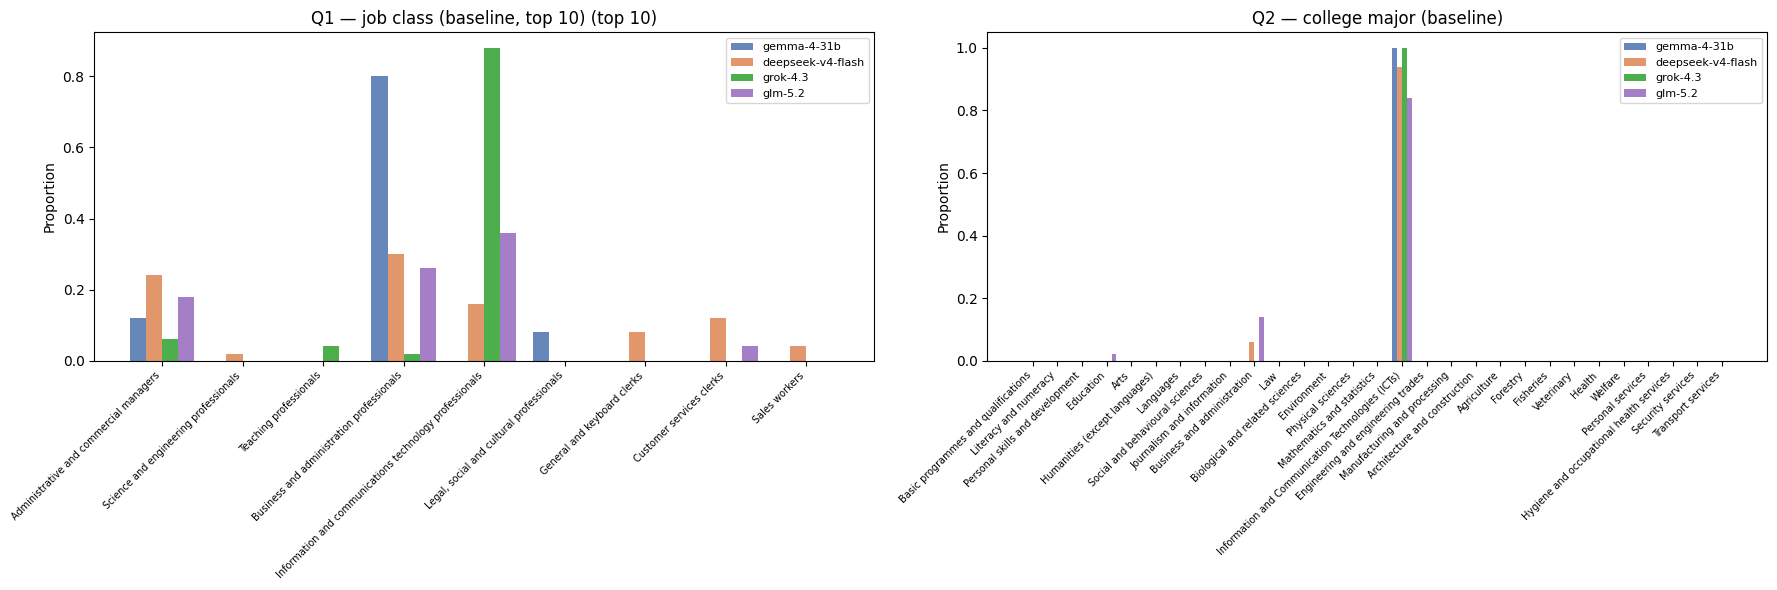

In [22]:
fig, axes = plt.subplots(1, 2, figsize=(18, 6))
_plot_class_dist(df_b_q1, Q1_CLASSES, "Q1 — job class (baseline, top 10)", axes[0], top_n=TOP_N)
_plot_class_dist(df_b_q2, Q2_CLASSES, "Q2 — college major (baseline)",      axes[1])
_save(fig, FIGURES_DIR / "baseline_class_distribution.png")

## 5. Collapsed groups (major group / broad field)

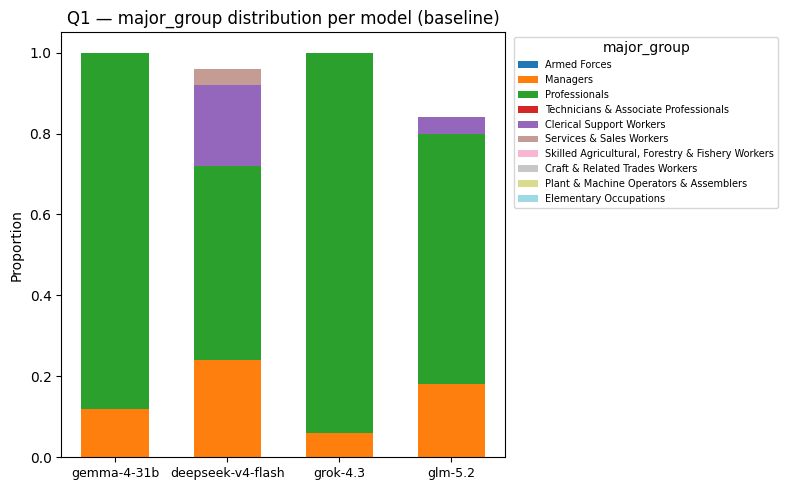

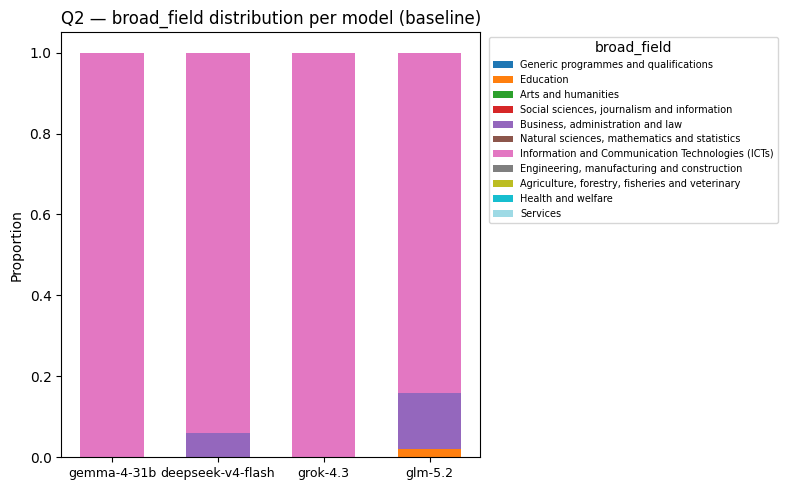

In [23]:
# Collapsed by model (treat model as the split column)
for df, label, group_col, group_map in [
    (df_b_q1, "Q1", "major_group", Q1_MAJOR_GROUPS),
    (df_b_q2, "Q2", "broad_field", Q2_BROAD_FIELDS),
]:
    levels  = list(dict.fromkeys(group_map.values()))
    models  = [m for m in BASELINE_MODELS if m in df["subject_model_alias"].unique()]
    cmap    = plt.cm.tab20
    x       = np.arange(len(models))
    width   = 0.6

    fig, ax = plt.subplots(figsize=(8, 5))
    bottoms = np.zeros(len(models))
    for li, lvl in enumerate(levels):
        props = np.array([
            (df[df["subject_model_alias"] == m][group_col] == lvl).mean()
            for m in models
        ])
        ax.bar(x, props, width, bottom=bottoms,
               color=cmap(li / max(len(levels) - 1, 1)), label=lvl)
        bottoms += props
    ax.set_xticks(x)
    ax.set_xticklabels([MODEL_LABELS[m] for m in models], fontsize=9)
    ax.set_ylabel("Proportion")
    ax.set_ylim(0, 1.05)
    ax.set_title(f"{label} — {group_col} distribution per model (baseline)")
    ax.legend(fontsize=7, bbox_to_anchor=(1.01, 1), loc="upper left", title=group_col)
    _save(fig, FIGURES_DIR / f"baseline_collapsed_{label.lower()}.png")

## 6. NONE rate

`none_declared=True` means the judge couldn't classify the response into any category.
In the baseline this is meaningful: the model may give a vague or meta-answer when it has no persona to draw from.

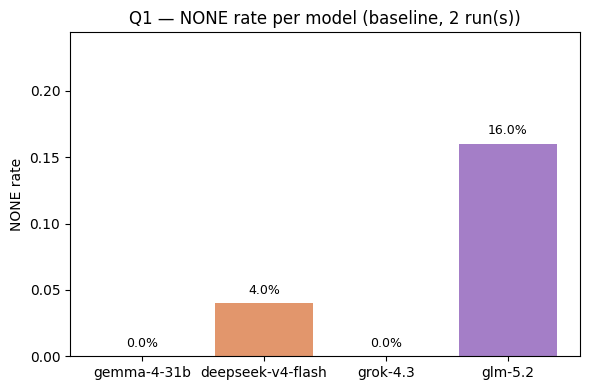

Q1 NONE counts (2 run(s)):
  gemma-4-31b              : 0/50 (0.0%)
  deepseek-v4-flash        : 2/50 (4.0%)
  grok-4.3                 : 0/50 (0.0%)
  glm-5.2                  : 8/50 (16.0%)



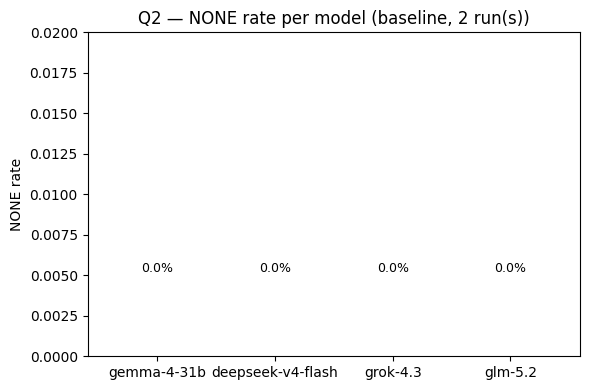

Q2 NONE counts (2 run(s)):
  gemma-4-31b              : 0/50 (0.0%)
  deepseek-v4-flash        : 0/50 (0.0%)
  grok-4.3                 : 0/50 (0.0%)
  glm-5.2                  : 0/50 (0.0%)



In [24]:
for df_raw, q_tag, label in [
    (df_b_q1, "q1", "Q1"),
    (df_b_q2, "q2", "Q2"),
]:
    # Reload raw (including failed rows) to get true NONE rate denominator
    frames = [
        pd.read_csv(OUTPUT_DIR / f"behavioral-audit-{r}-{q_tag}-stage2.judgments.csv")
        for r in BASELINE_RUNS
    ]
    df_raw_all = pd.concat(frames, ignore_index=True)
    df_raw_all["is_none"] = df_raw_all["none_declared"].astype(str).str.lower() == "true"
    models = [m for m in BASELINE_MODELS if m in df_raw_all["subject_model_alias"].unique()]

    fig, ax = plt.subplots(figsize=(6, 4))
    rates = [df_raw_all[df_raw_all["subject_model_alias"] == m]["is_none"].mean() for m in models]
    bars  = ax.bar(
        [MODEL_LABELS[m] for m in models], rates,
        color=[MODEL_COLORS[m] for m in models], alpha=0.85
    )
    for bar, rate in zip(bars, rates):
        ax.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 0.005,
                f"{rate:.1%}", ha="center", va="bottom", fontsize=9)
    ax.set_ylabel("NONE rate")
    n_runs_label = f"{len(BASELINE_RUNS)} run(s)"
    ax.set_title(f"{label} — NONE rate per model (baseline, {n_runs_label})")
    ax.set_ylim(0, max(rates) * 1.4 + 0.02)
    _save(fig, FIGURES_DIR / f"baseline_none_rate_{label.lower()}.png")

    print(f"{label} NONE counts ({n_runs_label}):")
    for m, r in zip(models, rates):
        grp = df_raw_all[df_raw_all["subject_model_alias"] == m]
        n   = grp["is_none"].sum()
        t   = len(grp)
        print(f"  {MODEL_LABELS[m]:25s}: {n}/{t} ({r:.1%})")
    print()

## 7. Iteration stability

With no persona context, do the 50 draws stay consistent or drift?
Plot the cumulative proportion of the top-3 classes as iterations accumulate.

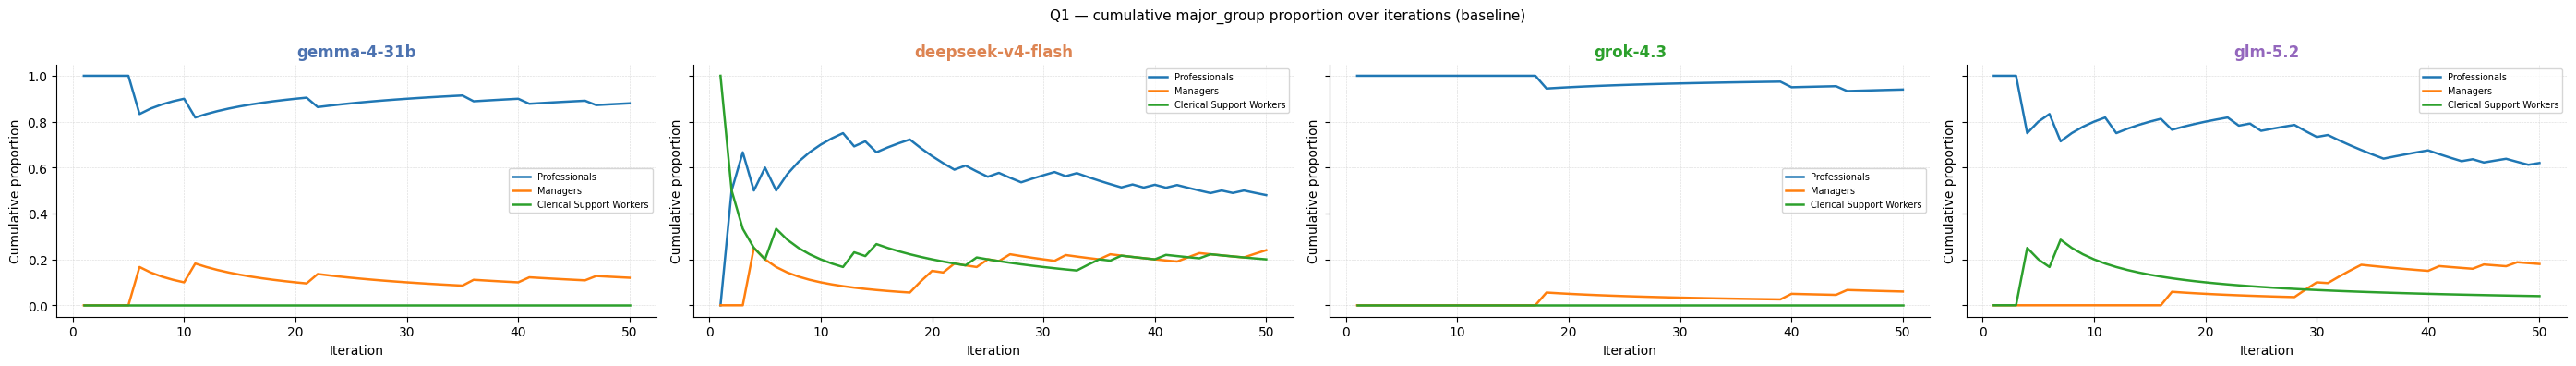

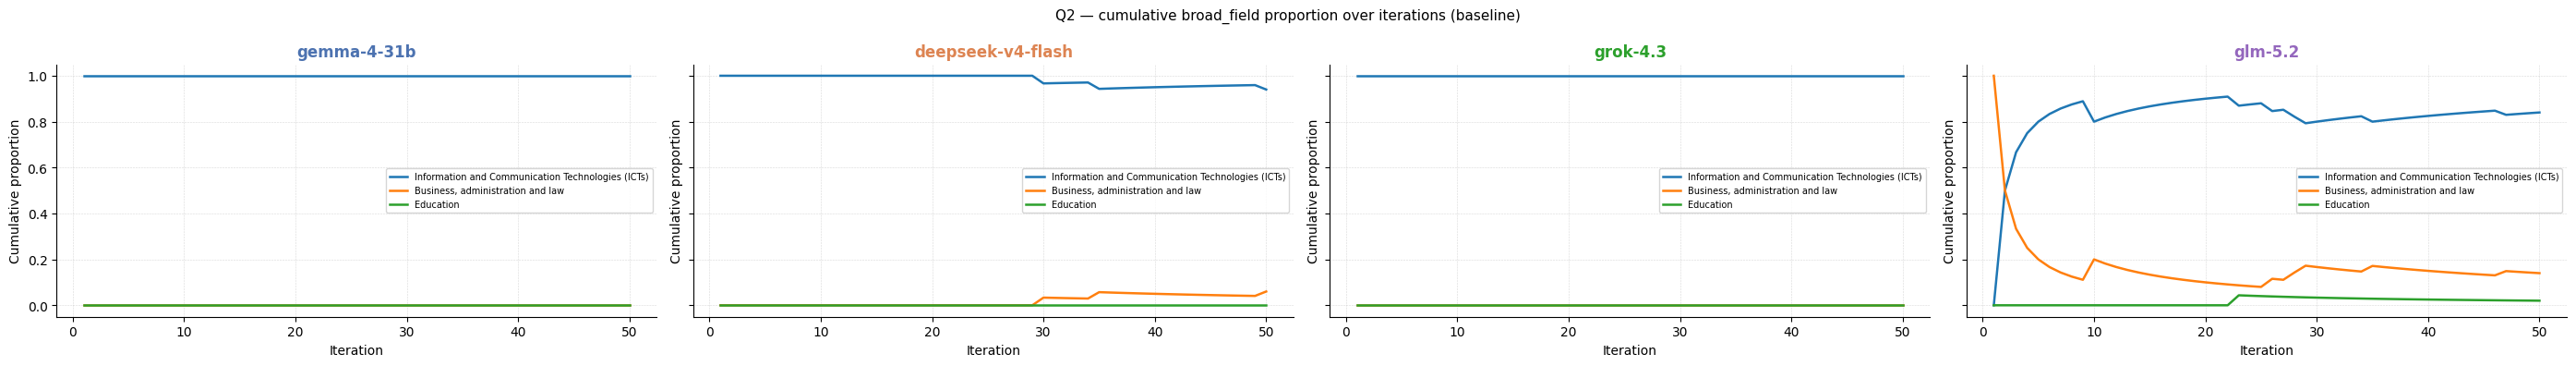

In [25]:
for df, label, group_col in [
    (df_b_q1, "Q1", "major_group"),
    (df_b_q2, "Q2", "broad_field"),
]:
    models = [m for m in BASELINE_MODELS if m in df["subject_model_alias"].unique()]
    # top 3 groups overall
    top3 = df[group_col].value_counts().head(3).index.tolist()
    cmap = plt.cm.tab10

    fig, axes = plt.subplots(1, len(models), figsize=(7 * len(models), 4), sharey=True)
    fig.suptitle(f"{label} — cumulative {group_col} proportion over iterations (baseline)",
                 fontsize=11)
    if len(models) == 1:
        axes = [axes]

    for ax, model in zip(axes, models):
        grp = df[df["subject_model_alias"] == model].sort_values("iteration").reset_index(drop=True)
        for ci, cls in enumerate(top3):
            cumulative = [
                (grp.iloc[:i + 1][group_col] == cls).mean()
                for i in range(len(grp))
            ]
            ax.plot(range(1, len(grp) + 1), cumulative,
                    label=cls, color=cmap(ci), linewidth=1.8)
        ax.set_xlabel("Iteration")
        ax.set_ylabel("Cumulative proportion")
        ax.set_title(MODEL_LABELS[model], color=MODEL_COLORS[model], fontweight="bold")
        ax.legend(fontsize=7)
        ax.grid(linestyle="--", linewidth=0.4, alpha=0.5)
        for spine in ["top", "right"]:
            ax.spines[spine].set_visible(False)

    _save(fig, FIGURES_DIR / f"baseline_stability_{label.lower()}.png")

## 8. Comparison: Baseline vs Full run

**Full001** uses the same two models with full persona histories (~3 700 per model).
This section directly compares what the models recommend **without** vs **with** persona context.

- Grey bars = baseline (no persona)
- Coloured bars = full001 (with persona)

In [26]:
df_f_q1 = _load(FULL_RUN, "q1", "major_group")
df_f_q2 = _load(FULL_RUN, "q2", "broad_field")
print(f"Full Q1: {len(df_f_q1)} rows")
print(f"Full Q2: {len(df_f_q2)} rows")

Full Q1: 7733 rows
Full Q2: 7737 rows


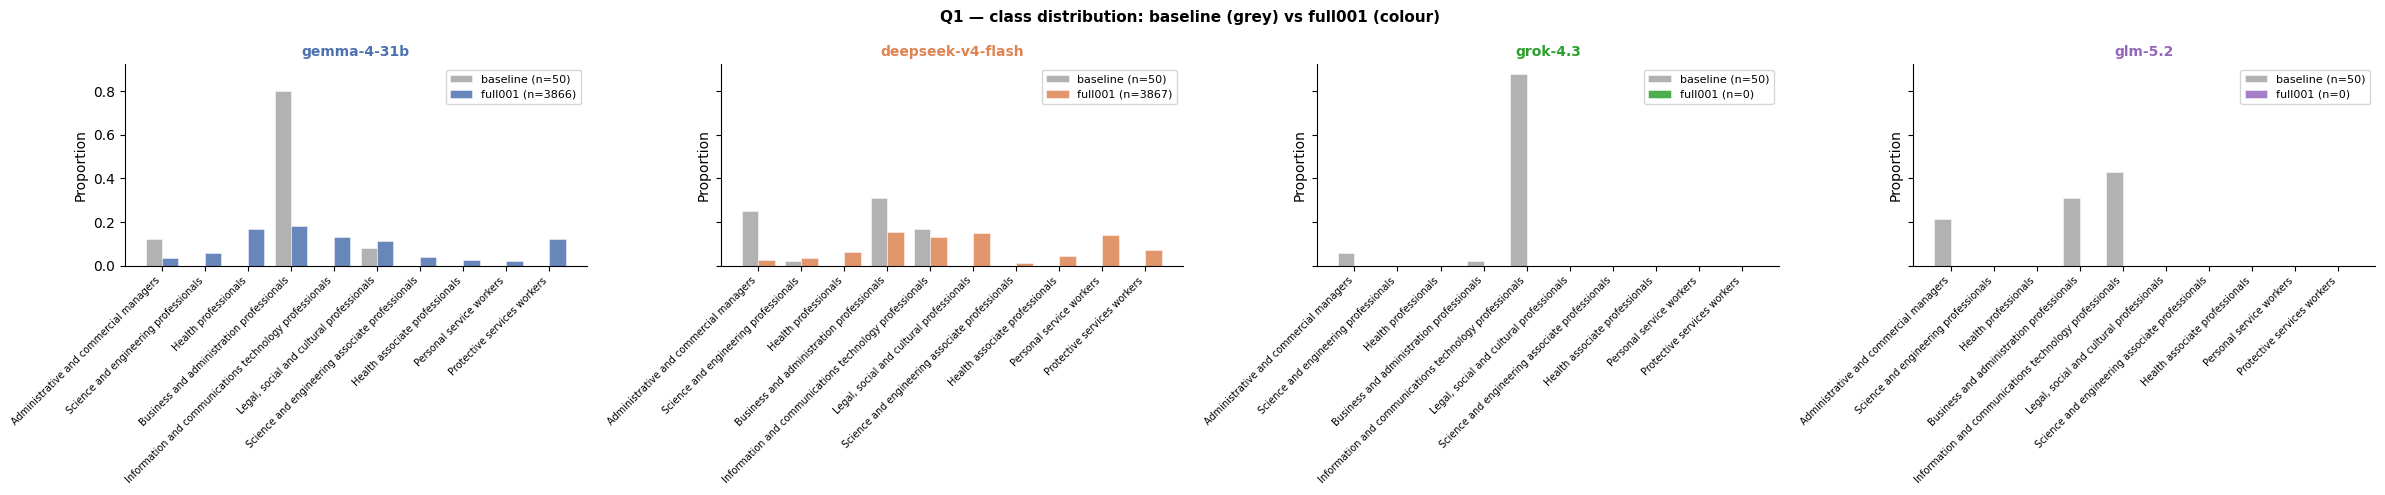

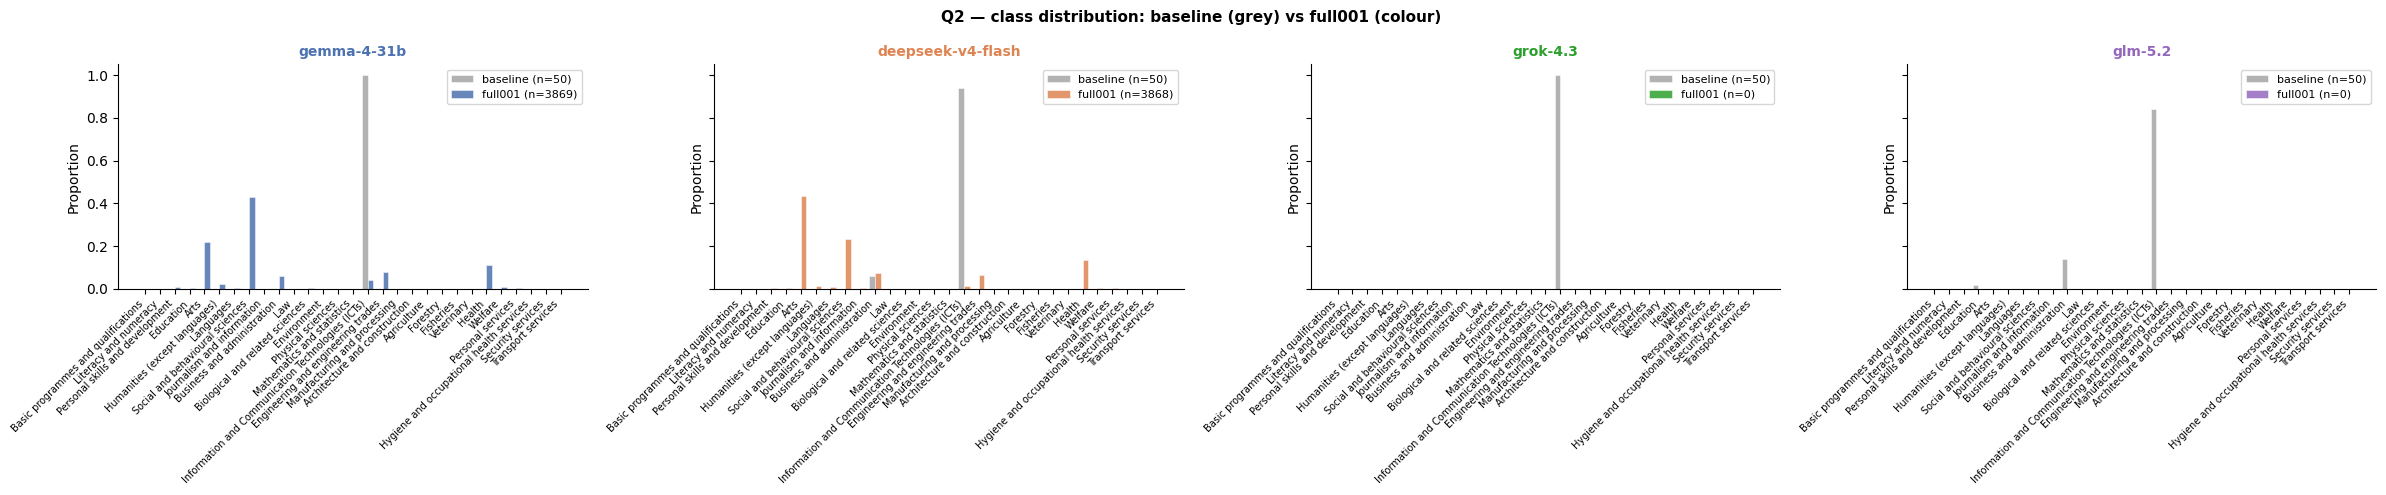

In [27]:
# ── 8a. Class distribution: baseline vs full, per model ───────────────────
# One figure per question. For each model: grey bar (baseline) + coloured bar (full).

def _plot_baseline_vs_full(df_b, df_f, classes, group_col, q_label, fig_path, top_n=None):
    models = [m for m in BASELINE_MODELS if m in df_b["subject_model_alias"].unique()]
    if top_n:
        top_classes = pd.concat([df_b, df_f])["final_class"].value_counts().head(top_n).index.tolist()
        classes = [c for c in classes if c in top_classes]

    fig, axes = plt.subplots(1, len(models), figsize=(12 * len(models) // 2, 5), sharey=True)
    fig.suptitle(
        f"{q_label} — class distribution: baseline (grey) vs full001 (colour)",
        fontsize=11, fontweight="bold"
    )
    if len(models) == 1:
        axes = [axes]

    x     = np.arange(len(classes))
    bar_w = 0.38

    for ax, model in zip(axes, models):
        grp_b = df_b[df_b["subject_model_alias"] == model]
        grp_f = df_f[df_f["subject_model_alias"] == model]
        prop_b = grp_b["final_class"].value_counts(normalize=True).reindex(classes, fill_value=0)
        prop_f = grp_f["final_class"].value_counts(normalize=True).reindex(classes, fill_value=0)

        ax.bar(x - bar_w / 2, prop_b.values, bar_w,
               color="#AAAAAA", alpha=0.9, label=f"baseline (n={len(grp_b)})",
               edgecolor="white", linewidth=0.4)
        ax.bar(x + bar_w / 2, prop_f.values, bar_w,
               color=MODEL_COLORS[model], alpha=0.85, label=f"full001 (n={len(grp_f)})",
               edgecolor="white", linewidth=0.4)

        ax.set_title(MODEL_LABELS[model], color=MODEL_COLORS[model], fontweight="bold", fontsize=10)
        ax.set_xticks(x)
        ax.set_xticklabels(classes, rotation=45, ha="right", fontsize=7)
        ax.set_ylabel("Proportion")
        ax.legend(fontsize=8)
        ax.spines["top"].set_visible(False)
        ax.spines["right"].set_visible(False)

    plt.tight_layout()
    fig.savefig(fig_path, bbox_inches="tight", dpi=150)
    plt.show()
    plt.close(fig)


_plot_baseline_vs_full(df_b_q1, df_f_q1, Q1_CLASSES, "major_group", "Q1",
                       FIGURES_DIR / "comparison_class_dist_q1.png", top_n=TOP_N)
_plot_baseline_vs_full(df_b_q2, df_f_q2, Q2_CLASSES, "broad_field",  "Q2",
                       FIGURES_DIR / "comparison_class_dist_q2.png")

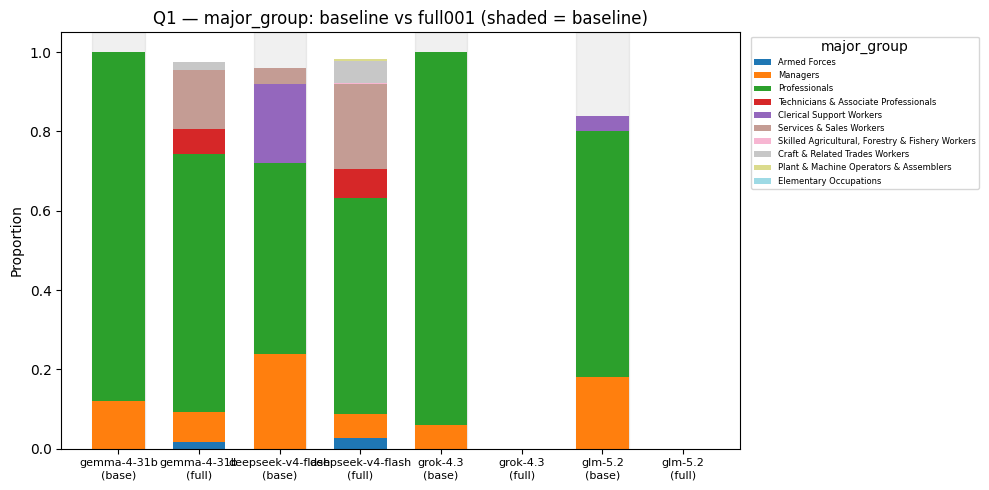

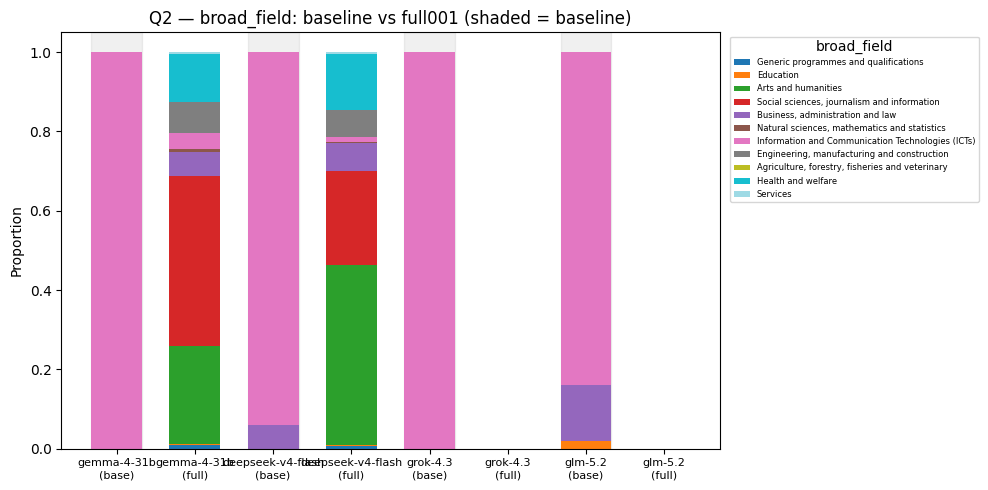

In [28]:
# ── 8b. Collapsed group distribution: baseline vs full ────────────────────
# Stacked bar: one bar per (model × condition) pair.

def _plot_collapsed_comparison(df_b, df_f, group_col, group_map, q_label, fig_path):
    models  = [m for m in BASELINE_MODELS if m in df_b["subject_model_alias"].unique()]
    levels  = list(dict.fromkeys(group_map.values()))
    cmap    = plt.cm.tab20

    # x-axis: pairs of (baseline, full) per model
    pairs   = [(m, "baseline") for m in models] + [(m, "full") for m in models]
    # reorder so baseline/full are adjacent per model
    pairs   = [p for m in models for p in [(m, "baseline"), (m, "full")]]
    labels  = [f"{MODEL_LABELS[m]}\n({'base' if c == 'baseline' else 'full'})" for m, c in pairs]

    fig, ax = plt.subplots(figsize=(10, 5))
    x       = np.arange(len(pairs))
    width   = 0.65
    bottoms = np.zeros(len(pairs))

    for li, lvl in enumerate(levels):
        props = []
        for model, cond in pairs:
            df = df_b if cond == "baseline" else df_f
            grp = df[df["subject_model_alias"] == model]
            props.append((grp[group_col] == lvl).mean() if len(grp) > 0 else 0.0)
        ax.bar(x, props, width, bottom=bottoms,
               color=cmap(li / max(len(levels) - 1, 1)), label=lvl)
        bottoms += np.array(props)

    # shade baseline bars slightly
    for i, (_, cond) in enumerate(pairs):
        if cond == "baseline":
            ax.axvspan(i - width / 2, i + width / 2, color="black", alpha=0.06, zorder=0)

    ax.set_xticks(x)
    ax.set_xticklabels(labels, fontsize=8)
    ax.set_ylabel("Proportion")
    ax.set_ylim(0, 1.05)
    ax.set_title(f"{q_label} — {group_col}: baseline vs full001 (shaded = baseline)")
    ax.legend(fontsize=6, bbox_to_anchor=(1.01, 1), loc="upper left", title=group_col)
    _save(fig, fig_path)


_plot_collapsed_comparison(df_b_q1, df_f_q1, "major_group", Q1_MAJOR_GROUPS, "Q1",
                            FIGURES_DIR / "comparison_collapsed_q1.png")
_plot_collapsed_comparison(df_b_q2, df_f_q2, "broad_field",  Q2_BROAD_FIELDS,  "Q2",
                            FIGURES_DIR / "comparison_collapsed_q2.png")

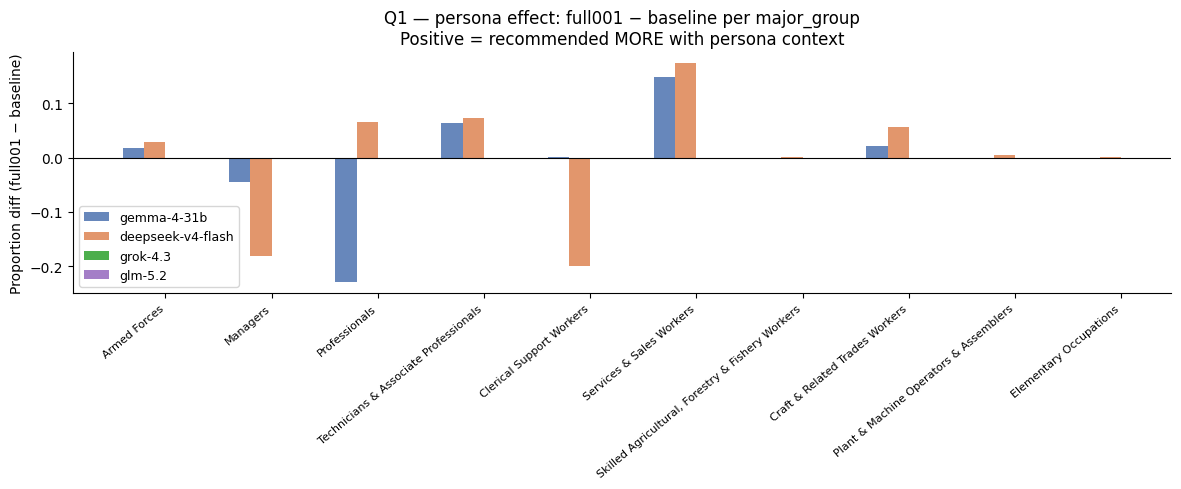

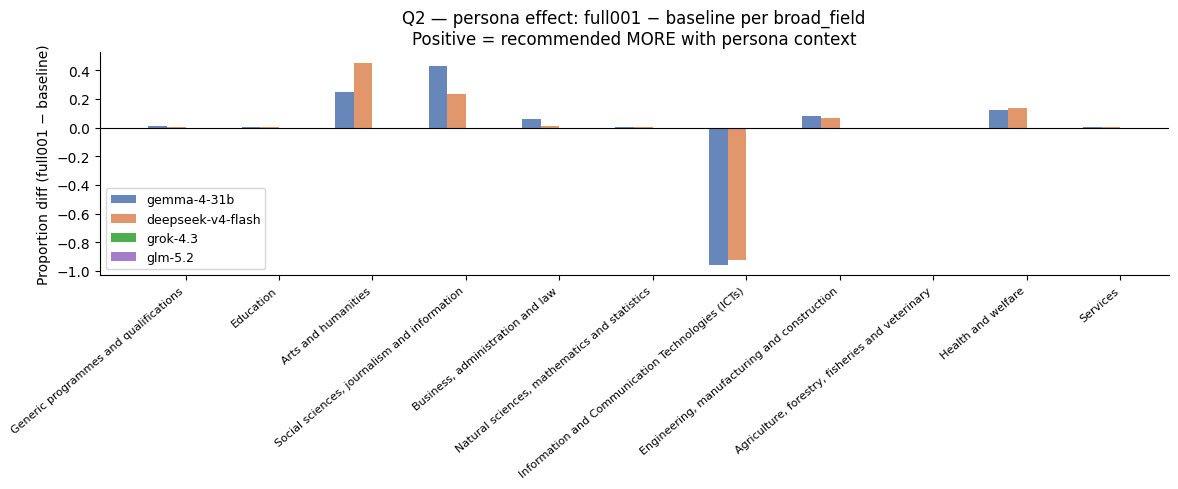

In [29]:
# ── 8c. Difference chart: Full − Baseline proportion per collapsed group ──
# Positive = model recommends this group MORE with persona context.
# Negative = model recommends it LESS with persona context.

def _plot_diff(df_b, df_f, group_col, group_map, q_label, fig_path):
    models = [m for m in BASELINE_MODELS if m in df_b["subject_model_alias"].unique()]
    levels = list(dict.fromkeys(group_map.values()))
    x      = np.arange(len(levels))
    width  = 0.8 / len(models)

    fig, ax = plt.subplots(figsize=(12, 5))
    for i, model in enumerate(models):
        grp_b = df_b[df_b["subject_model_alias"] == model]
        grp_f = df_f[df_f["subject_model_alias"] == model]
        diffs = [
            (grp_f[group_col] == lvl).mean() - (grp_b[group_col] == lvl).mean()
            for lvl in levels
        ]
        ax.bar(x + i * width, diffs, width,
               label=MODEL_LABELS[model], color=MODEL_COLORS[model], alpha=0.85)

    ax.axhline(0, color="black", linewidth=0.8)
    ax.set_xticks(x + width * (len(models) - 1) / 2)
    ax.set_xticklabels(levels, rotation=40, ha="right", fontsize=8)
    ax.set_ylabel("Proportion diff (full001 − baseline)")
    ax.set_title(
        f"{q_label} — persona effect: full001 − baseline per {group_col}\n"
        f"Positive = recommended MORE with persona context"
    )
    ax.legend(fontsize=9)
    ax.spines["top"].set_visible(False)
    ax.spines["right"].set_visible(False)
    _save(fig, fig_path)


_plot_diff(df_b_q1, df_f_q1, "major_group", Q1_MAJOR_GROUPS, "Q1",
           FIGURES_DIR / "comparison_diff_q1.png")
_plot_diff(df_b_q2, df_f_q2, "broad_field",  Q2_BROAD_FIELDS,  "Q2",
           FIGURES_DIR / "comparison_diff_q2.png")

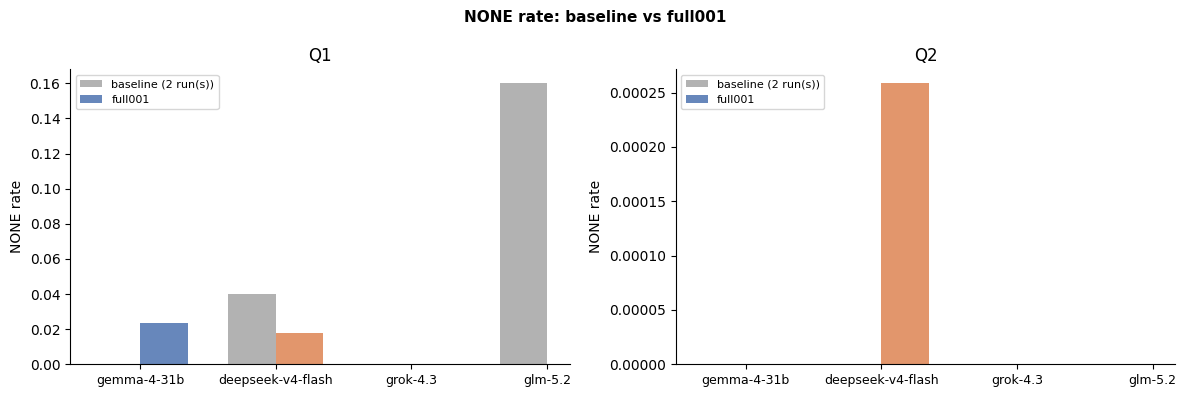

In [30]:
# ── 8d. NONE rate: baseline vs full ───────────────────────────────────────

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
fig.suptitle("NONE rate: baseline vs full001", fontsize=11, fontweight="bold")

for ax, q_tag, label in [(axes[0], "q1", "Q1"), (axes[1], "q2", "Q2")]:
    models = BASELINE_MODELS
    x      = np.arange(len(models))
    width  = 0.35

    # baseline: pool all runs
    frames_b = [
        pd.read_csv(OUTPUT_DIR / f"behavioral-audit-{r}-{q_tag}-stage2.judgments.csv")
        for r in BASELINE_RUNS
    ]
    df_b_raw = pd.concat(frames_b, ignore_index=True)
    df_b_raw["is_none"] = df_b_raw["none_declared"].astype(str).str.lower() == "true"
    rates_b = [df_b_raw[df_b_raw["subject_model_alias"] == m]["is_none"].mean() for m in models]

    # full001: single run
    df_f_raw = pd.read_csv(OUTPUT_DIR / f"behavioral-audit-{FULL_RUN}-{q_tag}-stage2.judgments.csv")
    df_f_raw["is_none"] = df_f_raw["none_declared"].astype(str).str.lower() == "true"
    rates_f = [df_f_raw[df_f_raw["subject_model_alias"] == m]["is_none"].mean() for m in models]

    ax.bar(x - width / 2, rates_b, width, color="#AAAAAA", alpha=0.9,
           label=f"baseline ({len(BASELINE_RUNS)} run(s))")
    ax.bar(x + width / 2, rates_f, width,
           color=[MODEL_COLORS[m] for m in models], alpha=0.85, label="full001")
    ax.set_xticks(x)
    ax.set_xticklabels([MODEL_LABELS[m] for m in models], fontsize=9)
    ax.set_ylabel("NONE rate")
    ax.set_title(label)
    ax.legend(fontsize=8)
    ax.spines["top"].set_visible(False)
    ax.spines["right"].set_visible(False)

_save(fig, FIGURES_DIR / "comparison_none_rate.png")

## 9. Summary statistics

In [31]:
for df_b, df_f, label, group_col in [
    (df_b_q1, df_f_q1, "Q1", "major_group"),
    (df_b_q2, df_f_q2, "Q2", "broad_field"),
]:
    print("=" * 70)
    print(f"{label} — {group_col} proportions: baseline vs full001")
    print("=" * 70)

    rows = []
    for model in BASELINE_MODELS:
        for cond, df in [("baseline", df_b), ("full001", df_f)]:
            grp = df[df["subject_model_alias"] == model]
            if len(grp) == 0:
                continue
            props = grp[group_col].value_counts(normalize=True)
            rows.append({"model": MODEL_LABELS[model], "condition": cond, **props.to_dict()})

    summary = pd.DataFrame(rows).set_index(["model", "condition"]).fillna(0)
    print(summary.T.to_string(float_format="{:.3f}".format))
    print()

    print(f"{label} — persona effect (full001 − baseline) per {group_col}")
    print("-" * 70)
    levels = list(dict.fromkeys(
        Q1_MAJOR_GROUPS.values() if group_col == "major_group" else Q2_BROAD_FIELDS.values()
    ))
    diff_rows = []
    for model in BASELINE_MODELS:
        grp_b = df_b[df_b["subject_model_alias"] == model]
        grp_f = df_f[df_f["subject_model_alias"] == model]
        row = {"model": MODEL_LABELS[model]}
        for lvl in levels:
            pb = (grp_b[group_col] == lvl).mean() if len(grp_b) > 0 else 0.0
            pf = (grp_f[group_col] == lvl).mean() if len(grp_f) > 0 else 0.0
            row[lvl] = pf - pb
        diff_rows.append(row)
    diff_df = pd.DataFrame(diff_rows).set_index("model")
    print(diff_df.T.to_string(float_format="{:+.3f}".format))
    print()

Q1 — major_group proportions: baseline vs full001
model                                            gemma-4-31b         deepseek-v4-flash         grok-4.3  glm-5.2
condition                                           baseline full001          baseline full001 baseline baseline
Professionals                                          0.880   0.667             0.500   0.555    0.940    0.738
Managers                                               0.120   0.077             0.250   0.061    0.060    0.214
Services & Sales Workers                               0.000   0.152             0.042   0.217    0.000    0.000
Technicians & Associate Professionals                  0.000   0.065             0.000   0.075    0.000    0.000
Craft & Related Trades Workers                         0.000   0.022             0.000   0.057    0.000    0.000
Armed Forces                                           0.000   0.017             0.000   0.028    0.000    0.000
Clerical Support Workers                      

## 10. Dual-axis overview: distribution × deviation (models merged)

Four chart ideas that combine the **full001 proportion** and the **baseline deviation** (full001 − baseline) in a single figure.  
Models are merged by averaging proportions across gemma-4-31b and deepseek-v4-flash.

- **Idea A** — full001 proportion (bars, left Y) + deviation (line, right Y) — *where do models land, and how far did persona move them?*
- **Idea B** — baseline proportion (bars, left Y) + deviation (line, right Y) — *what was the anchor, and how much did persona pull each group?*
- **Idea C** — deviation (bars, left Y) + full001 proportion (line, right Y) — *which groups shifted most, and what is their final share?*
- **Idea D** — two-subplot figure (Q1 top, Q2 bottom) in Idea-A style — *both questions in one compact view*

In [32]:
# ── Shared helper: merge models by averaging proportions ──────────────────

def _merged_props(df, group_col, levels):
    """Average proportion per level across all models."""
    per_model = []
    for m in BASELINE_MODELS:
        grp = df[df["subject_model_alias"] == m]
        if len(grp) == 0:
            continue
        per_model.append(
            grp[group_col].value_counts(normalize=True).reindex(levels, fill_value=0)
        )
    return pd.concat(per_model, axis=1).mean(axis=1)  # Series indexed by level


def _dual_axis_data(df_b, df_f, group_col, group_map):
    levels  = list(dict.fromkeys(group_map.values()))
    prop_b  = _merged_props(df_b, group_col, levels)
    prop_f  = _merged_props(df_f, group_col, levels)
    dev     = prop_f - prop_b          # full001 − baseline
    return levels, prop_b, prop_f, dev


# pre-compute for both questions
levels_q1, prop_b_q1, prop_f_q1, dev_q1 = _dual_axis_data(
    df_b_q1, df_f_q1, "major_group", Q1_MAJOR_GROUPS)
levels_q2, prop_b_q2, prop_f_q2, dev_q2 = _dual_axis_data(
    df_b_q2, df_f_q2, "broad_field",  Q2_BROAD_FIELDS)

print("data ready — levels Q1:", len(levels_q1), "  Q2:", len(levels_q2))

data ready — levels Q1: 10   Q2: 11


### Idea A — full001 proportion (bars) · deviation (line)

Left Y-axis bars show where models land with persona. Right Y-axis line shows how far they moved from baseline.
Bars and line share the same x-axis (groups), making it easy to read: tall bar + deep line = persona strongly pushed models here.

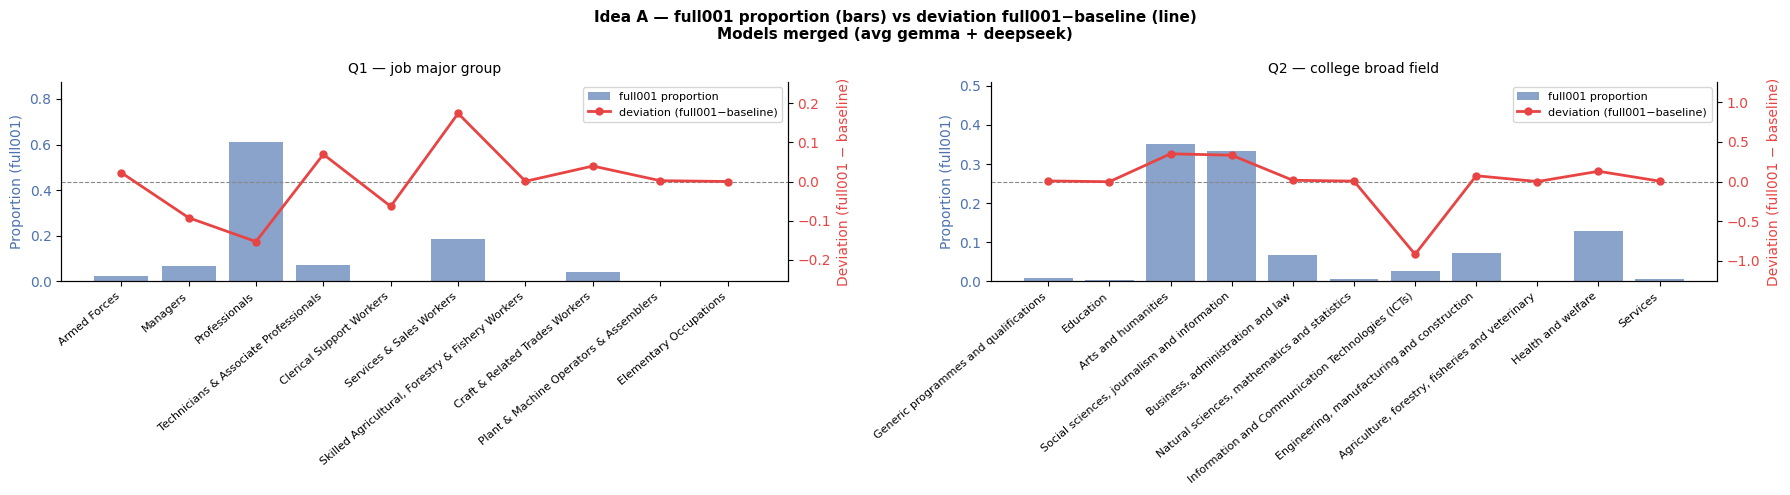

In [33]:
# ── Idea A: full001 proportion (bars) + deviation (line) ──────────────────
# One figure, two subplots side by side for Q1 and Q2.

BAR_COLOR  = "#4C72B0"
LINE_COLOR = "#E84444"
ZERO_COLOR = "#888888"

fig, axes = plt.subplots(1, 2, figsize=(18, 5))
fig.suptitle(
    "Idea A — full001 proportion (bars) vs deviation full001−baseline (line)\n"
    "Models merged (avg gemma + deepseek)",
    fontsize=11, fontweight="bold"
)

for ax, levels, prop_f, dev, q_label in [
    (axes[0], levels_q1, prop_f_q1, dev_q1, "Q1 — job major group"),
    (axes[1], levels_q2, prop_f_q2, dev_q2, "Q2 — college broad field"),
]:
    x = np.arange(len(levels))

    # ── left axis: full001 proportion bars ────────────────────────────────
    ax.bar(x, prop_f.values, color=BAR_COLOR, alpha=0.65, label="full001 proportion")
    ax.set_ylabel("Proportion (full001)", color=BAR_COLOR)
    ax.tick_params(axis="y", labelcolor=BAR_COLOR)
    ax.set_ylim(0, max(prop_f.values) * 1.4 + 0.02)

    # ── right axis: deviation line ─────────────────────────────────────────
    ax2 = ax.twinx()
    ax2.plot(x, dev.values, color=LINE_COLOR, linewidth=2, marker="o",
             markersize=5, label="deviation (full001−baseline)", zorder=5)
    ax2.axhline(0, color=ZERO_COLOR, linewidth=0.8, linestyle="--")
    ax2.set_ylabel("Deviation (full001 − baseline)", color=LINE_COLOR)
    ax2.tick_params(axis="y", labelcolor=LINE_COLOR)
    dev_max = max(abs(dev.values)) * 1.35 + 0.02
    ax2.set_ylim(-dev_max, dev_max)

    ax.set_xticks(x)
    ax.set_xticklabels(levels, rotation=40, ha="right", fontsize=8)
    ax.set_title(q_label, fontsize=10)
    ax.spines["top"].set_visible(False)
    ax2.spines["top"].set_visible(False)

    # combined legend
    h1, l1 = ax.get_legend_handles_labels()
    h2, l2 = ax2.get_legend_handles_labels()
    ax.legend(h1 + h2, l1 + l2, fontsize=8, loc="upper right")

plt.tight_layout()
fig.savefig(FIGURES_DIR / "dual_axis_ideaA.png", bbox_inches="tight", dpi=150)
plt.show()
plt.close(fig)

### Idea B — baseline proportion (bars) · deviation (line)

The bars now show the *anchor* — what models recommend without any persona. The line reveals how much each group was pulled toward or away from that anchor once persona context was added.
Groups with short bars but large deviations are categories persona "unlocked".

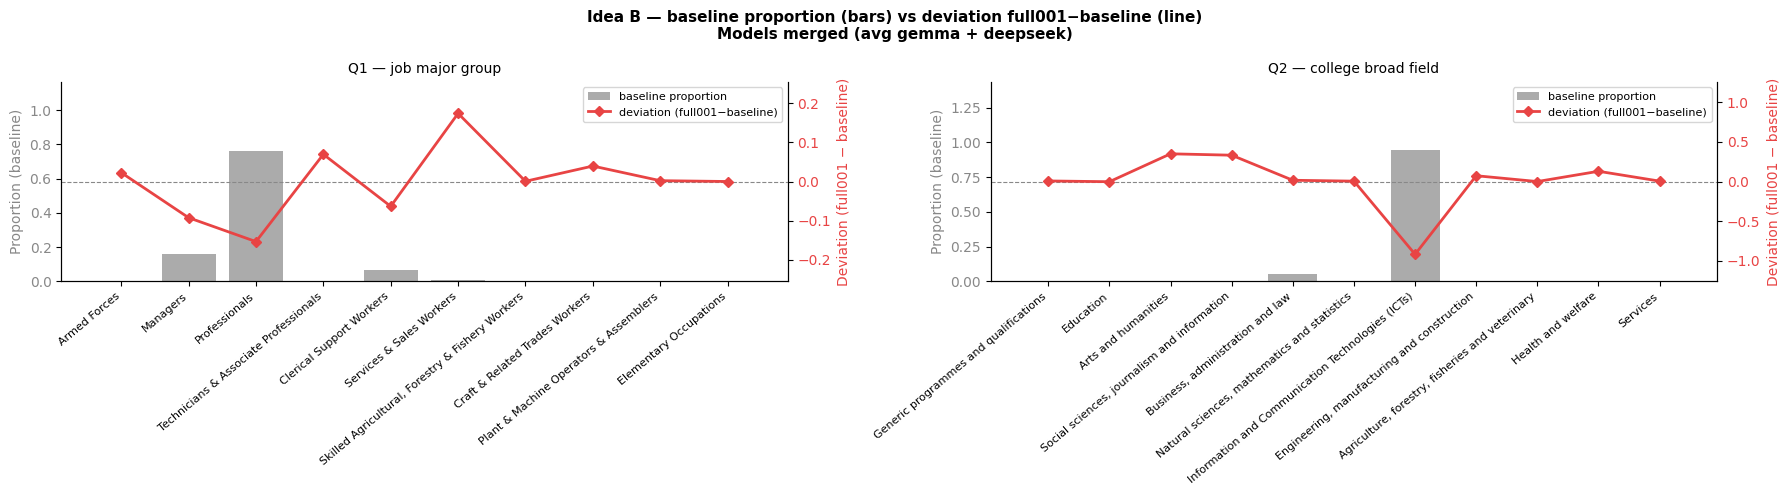

In [34]:
# ── Idea B: baseline proportion (bars) + deviation (line) ─────────────────

BAR_COLOR_B = "#888888"

fig, axes = plt.subplots(1, 2, figsize=(18, 5))
fig.suptitle(
    "Idea B — baseline proportion (bars) vs deviation full001−baseline (line)\n"
    "Models merged (avg gemma + deepseek)",
    fontsize=11, fontweight="bold"
)

for ax, levels, prop_b, dev, q_label in [
    (axes[0], levels_q1, prop_b_q1, dev_q1, "Q1 — job major group"),
    (axes[1], levels_q2, prop_b_q2, dev_q2, "Q2 — college broad field"),
]:
    x = np.arange(len(levels))

    # ── left axis: baseline proportion bars ───────────────────────────────
    ax.bar(x, prop_b.values, color=BAR_COLOR_B, alpha=0.7, label="baseline proportion")
    ax.set_ylabel("Proportion (baseline)", color=BAR_COLOR_B)
    ax.tick_params(axis="y", labelcolor=BAR_COLOR_B)
    ax.set_ylim(0, max(prop_b.values) * 1.5 + 0.02)

    # ── right axis: deviation line ─────────────────────────────────────────
    ax2 = ax.twinx()
    ax2.plot(x, dev.values, color=LINE_COLOR, linewidth=2, marker="D",
             markersize=5, label="deviation (full001−baseline)", zorder=5)
    ax2.axhline(0, color=ZERO_COLOR, linewidth=0.8, linestyle="--")
    ax2.set_ylabel("Deviation (full001 − baseline)", color=LINE_COLOR)
    ax2.tick_params(axis="y", labelcolor=LINE_COLOR)
    dev_max = max(abs(dev.values)) * 1.35 + 0.02
    ax2.set_ylim(-dev_max, dev_max)

    ax.set_xticks(x)
    ax.set_xticklabels(levels, rotation=40, ha="right", fontsize=8)
    ax.set_title(q_label, fontsize=10)
    ax.spines["top"].set_visible(False)
    ax2.spines["top"].set_visible(False)

    h1, l1 = ax.get_legend_handles_labels()
    h2, l2 = ax2.get_legend_handles_labels()
    ax.legend(h1 + h2, l1 + l2, fontsize=8, loc="upper right")

plt.tight_layout()
fig.savefig(FIGURES_DIR / "dual_axis_ideaB.png", bbox_inches="tight", dpi=150)
plt.show()
plt.close(fig)

### Idea C — deviation (bars) · full001 proportion (line)

The roles are swapped: bars show signed deviation (positive = persona pushed models here, negative = away), coloured green/red to make direction obvious. The line on the right axis shows the resulting full001 proportion — connecting shift magnitude to absolute landing share.

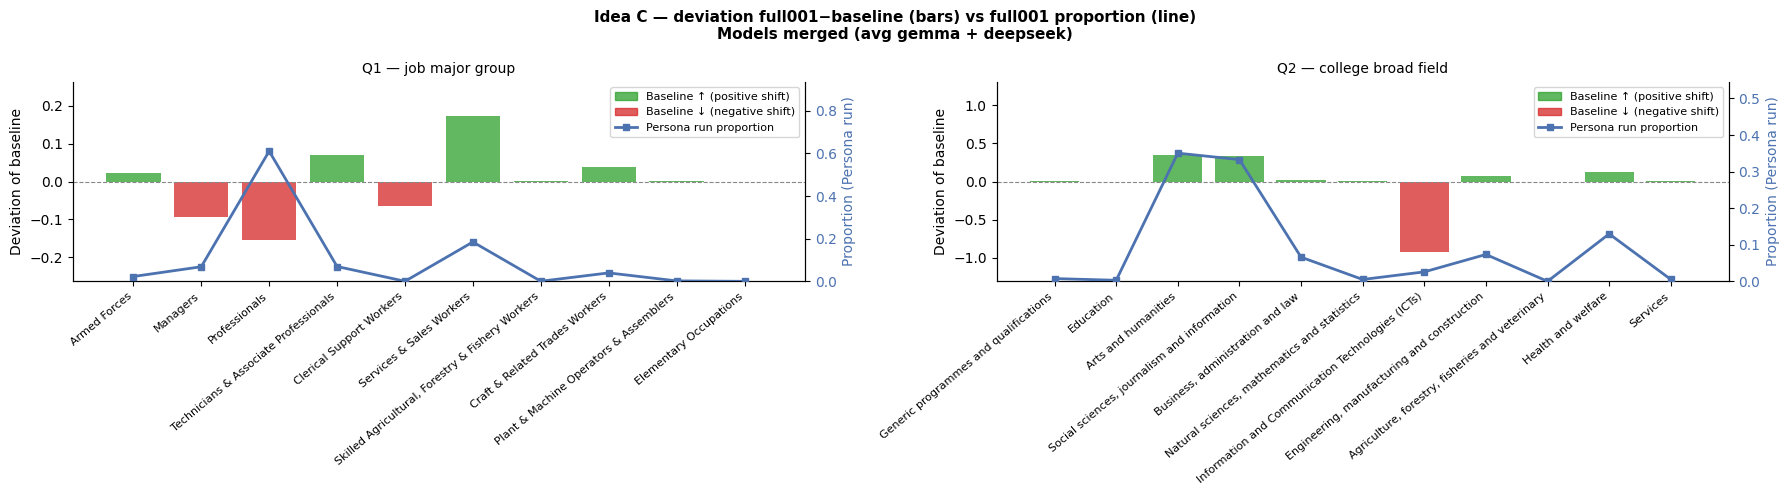

In [35]:
# ── Idea C: deviation (bars, green/red) + full001 proportion (line) ───────

POS_COLOR  = "#2CA02C"   # green  — persona increased this group
NEG_COLOR  = "#D62728"   # red    — persona decreased this group
LINE_COLOR_C = "#4C72B0"

fig, axes = plt.subplots(1, 2, figsize=(18, 5))
fig.suptitle(
    "Idea C — deviation full001−baseline (bars) vs full001 proportion (line)\n"
    "Models merged (avg gemma + deepseek)",
    fontsize=11, fontweight="bold"
)

for ax, levels, prop_f, dev, q_label in [
    (axes[0], levels_q1, prop_f_q1, dev_q1, "Q1 — job major group"),
    (axes[1], levels_q2, prop_f_q2, dev_q2, "Q2 — college broad field"),
]:
    x     = np.arange(len(levels))
    colors = [POS_COLOR if d >= 0 else NEG_COLOR for d in dev.values]

    # ── left axis: deviation bars ──────────────────────────────────────────
    ax.bar(x, dev.values, color=colors, alpha=0.75)
    ax.axhline(0, color=ZERO_COLOR, linewidth=0.8, linestyle="--")
    ax.set_ylabel("Deviation of baseline", color="black")
    dev_max = max(abs(dev.values)) * 1.4 + 0.02
    ax.set_ylim(-dev_max, dev_max)

    # custom legend patches for bar colours
    pos_patch = mpatches.Patch(color=POS_COLOR, alpha=0.75, label="Baseline ↑ (positive shift)")
    neg_patch = mpatches.Patch(color=NEG_COLOR, alpha=0.75, label="Baseline ↓ (negative shift)")

    # ── right axis: full001 proportion line ───────────────────────────────
    ax2 = ax.twinx()
    line, = ax2.plot(x, prop_f.values, color=LINE_COLOR_C, linewidth=2, marker="s",
                     markersize=5, label="Persona run proportion", zorder=5)
    ax2.set_ylabel("Proportion (Persona run)", color=LINE_COLOR_C)
    ax2.tick_params(axis="y", labelcolor=LINE_COLOR_C)
    ax2.set_ylim(0, max(prop_f.values) * 1.5 + 0.02)

    ax.set_xticks(x)
    ax.set_xticklabels(levels, rotation=40, ha="right", fontsize=8)
    ax.set_title(q_label, fontsize=10)
    ax.spines["top"].set_visible(False)
    ax2.spines["top"].set_visible(False)

    ax.legend(handles=[pos_patch, neg_patch, line], fontsize=8, loc="upper right")

plt.tight_layout()
fig.savefig(FIGURES_DIR / "dual_axis_ideaC.png", bbox_inches="tight", dpi=150)
plt.show()
plt.close(fig)

NameError: name 'prop_b_q1_merged' is not defined

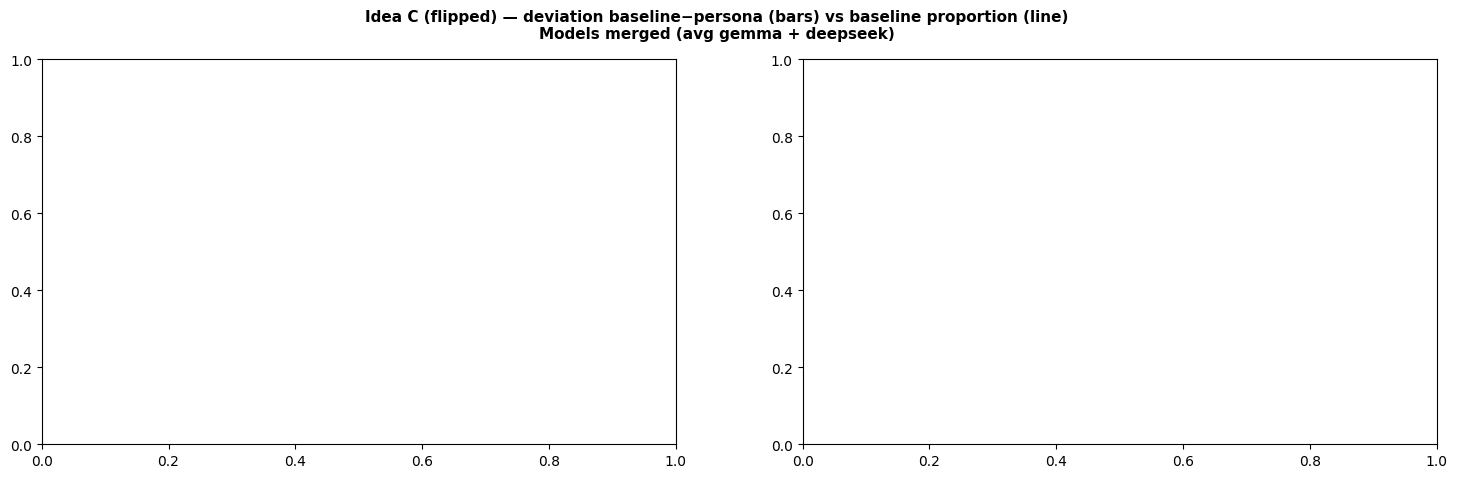

In [36]:
# ── Idea C (flipped): deviation baseline−persona (bars) + baseline proportion (line) ──
# bars = full001 − baseline  (positive = persona recommends MORE than baseline)
# line = baseline proportion

fig, axes = plt.subplots(1, 2, figsize=(18, 5))
fig.suptitle(
    "Idea C (flipped) — deviation baseline−persona (bars) vs baseline proportion (line)\n"
    "Models merged (avg gemma + deepseek)",
    fontsize=11, fontweight="bold"
)

for ax, levels, prop_b, dev, q_label in [
    (axes[0], levels_q1, prop_b_q1_merged, dev_q1, "Q1 — job major group"),
    (axes[1], levels_q2, prop_b_q2_merged, dev_q2, "Q2 — college broad field"),
]:
    x       = np.arange(len(levels))
    dev_inv = dev.values    # full001 − baseline
    colors  = [POS_COLOR if d >= 0 else NEG_COLOR for d in dev_inv]

    # ── left axis: deviation bars (green/red) ─────────────────────────────
    ax.bar(x, dev_inv, color=colors, alpha=0.75)
    ax.axhline(0, color=ZERO_COLOR, linewidth=0.8, linestyle="--")
    ax.set_ylabel("Deviation (persona − baseline)", color="black")
    dev_max = max(abs(dev_inv)) * 1.4 + 0.02
    ax.set_ylim(-dev_max, dev_max)

    pos_patch = mpatches.Patch(color=POS_COLOR, alpha=0.75, label="Persona ↑ above baseline")
    neg_patch = mpatches.Patch(color=NEG_COLOR, alpha=0.75, label="Persona ↓ below baseline")

    # ── right axis: baseline proportion line (blue) ───────────────────────
    ax2 = ax.twinx()
    line = ax2.scatter(x, prop_b.values, color=LINE_COLOR_C, s=80, zorder=5, label="Baseline proportion")
    ax2.set_ylabel("Proportion (baseline)", color=LINE_COLOR_C)
    ax2.tick_params(axis="y", labelcolor=LINE_COLOR_C)
    ax2.set_ylim(0, max(prop_b.values) * 1.5 + 0.02)

    ax.set_xticks(x)
    ax.set_xticklabels(levels, rotation=40, ha="right", fontsize=8)
    ax.set_title(q_label, fontsize=10)
    ax.spines["top"].set_visible(False)
    ax2.spines["top"].set_visible(False)

    ax.legend(handles=[pos_patch, neg_patch, line], fontsize=8, loc="upper right")

_save(fig, FIGURES_DIR / "dual_axis_ideaC_flipped.png")

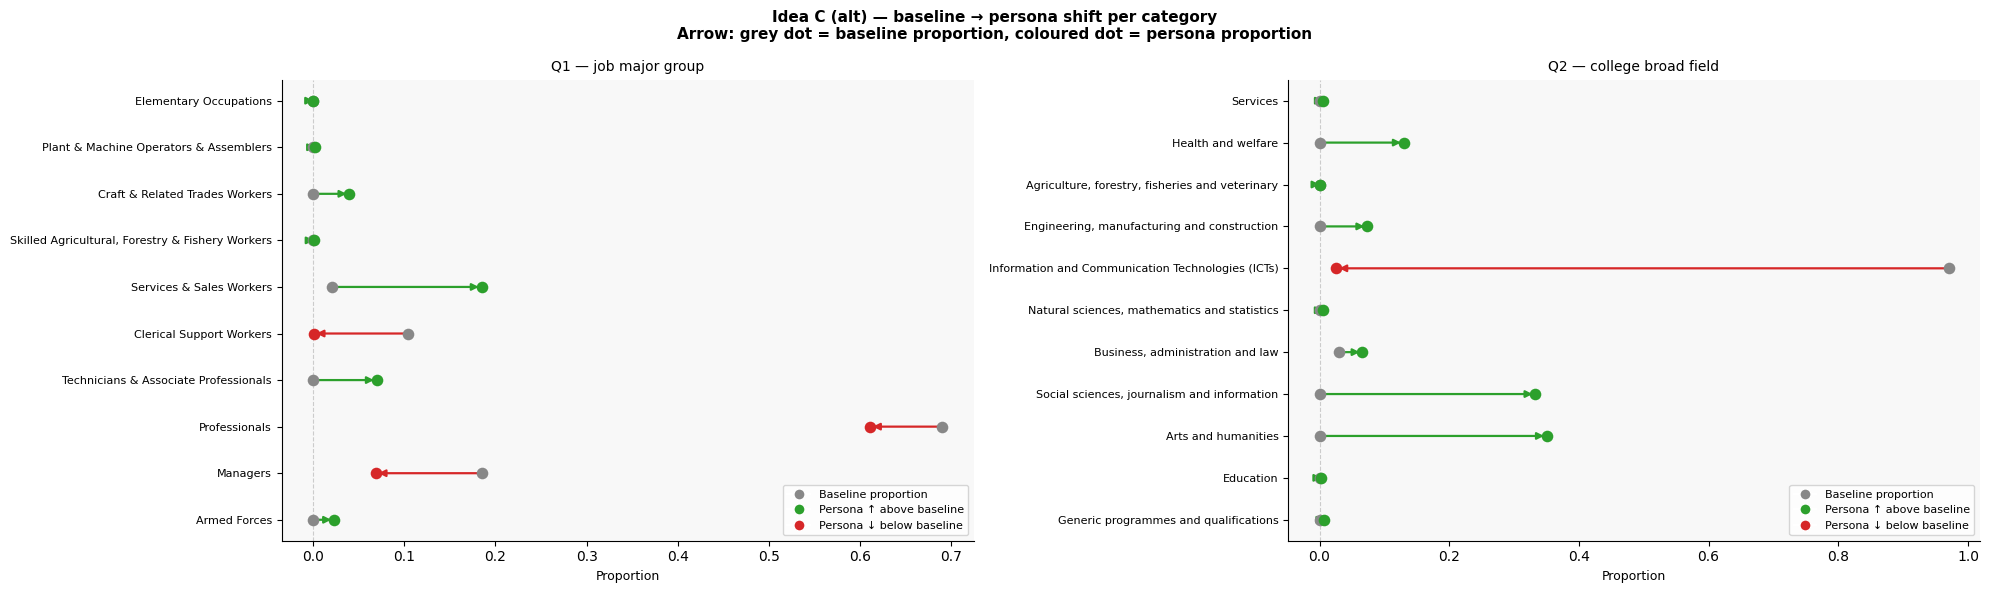

In [ ]:
# ── Idea C (alt): arrow/dot plot — baseline dot → persona dot per category ──
# Each category gets: baseline dot (grey) + persona dot (blue/red) + arrow between them
# Reading: arrow direction = how persona shifts; arrow length = magnitude

fig, axes = plt.subplots(1, 2, figsize=(20, 6))
fig.suptitle(
    "Idea C (alt) — baseline → persona shift per category\n"
    "Arrow: grey dot = baseline proportion, coloured dot = persona proportion",
    fontsize=11, fontweight="bold"
)

BASELINE_DOT  = "#888888"
PERSONA_UP    = POS_COLOR   # green
PERSONA_DOWN  = NEG_COLOR   # red

for ax, levels, prop_b, dev, q_label in [
    (axes[0], levels_q1, prop_b_q1_merged, dev_q1, "Q1 — job major group"),
    (axes[1], levels_q2, prop_b_q2_merged, dev_q2, "Q2 — college broad field"),
]:
    prop_f = prop_b.values + dev.values   # persona proportion
    n      = len(levels)
    y      = np.arange(n)                 # horizontal layout

    ax.set_facecolor("#F8F8F8")
    ax.axvline(0, color="#cccccc", linewidth=0.8, linestyle="--")

    for i in range(n):
        b = prop_b.values[i]
        p = prop_f[i]
        color = PERSONA_UP if p >= b else PERSONA_DOWN

        # connecting arrow from baseline to persona
        ax.annotate(
            "", xy=(p, i), xytext=(b, i),
            arrowprops=dict(
                arrowstyle="-|>",
                color=color,
                lw=1.6,
                mutation_scale=10,
            ),
        )
        # baseline dot
        ax.scatter(b, i, color=BASELINE_DOT, s=70, zorder=5, linewidths=0)
        # persona dot
        ax.scatter(p, i, color=color, s=70, zorder=6, linewidths=0)

    ax.set_yticks(y)
    ax.set_yticklabels(levels, fontsize=8)
    ax.set_xlabel("Proportion", fontsize=9)
    ax.set_title(q_label, fontsize=10)
    ax.spines["top"].set_visible(False)
    ax.spines["right"].set_visible(False)

    # legend
    from matplotlib.lines import Line2D
    handles = [
        Line2D([0], [0], marker="o", color="w", markerfacecolor=BASELINE_DOT, markersize=8, label="Baseline proportion"),
        Line2D([0], [0], marker="o", color="w", markerfacecolor=PERSONA_UP,   markersize=8, label="Persona ↑ above baseline"),
        Line2D([0], [0], marker="o", color="w", markerfacecolor=PERSONA_DOWN, markersize=8, label="Persona ↓ below baseline"),
    ]
    ax.legend(handles=handles, fontsize=8, loc="lower right")

_save(fig, FIGURES_DIR / "dual_axis_ideaC_arrows.png")


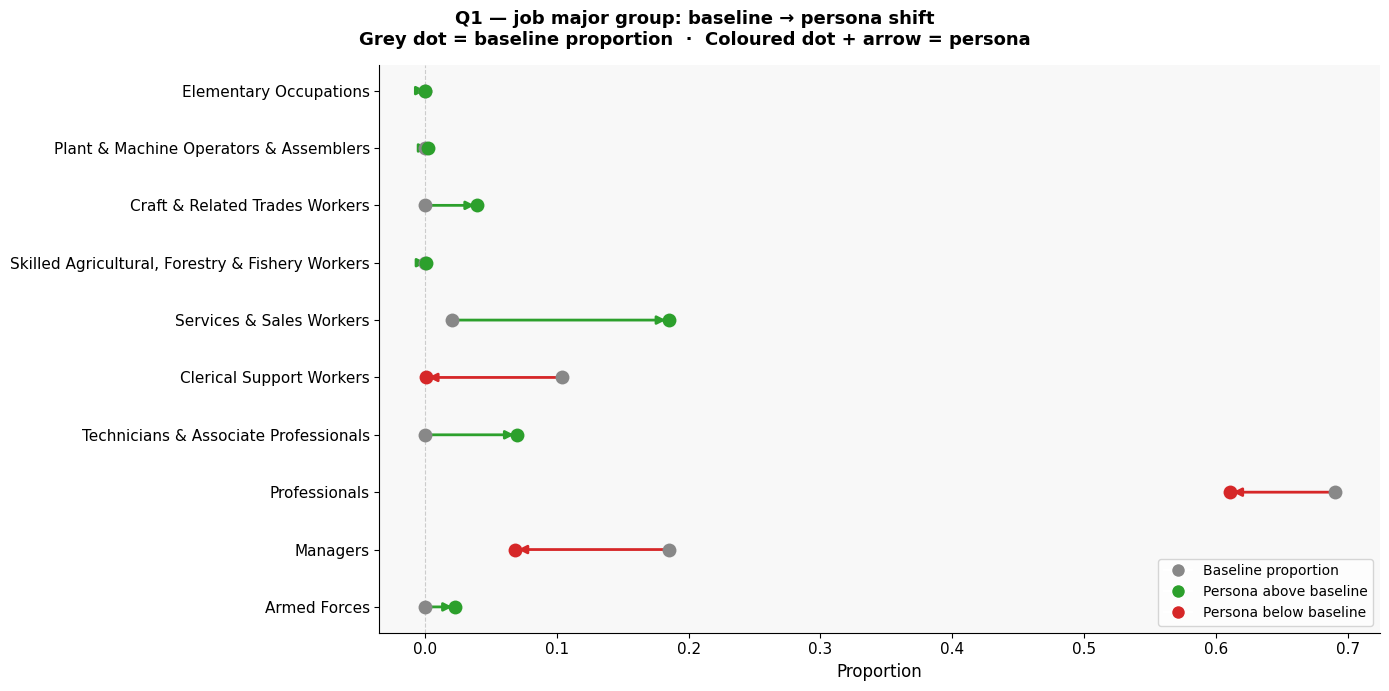

In [ ]:
# ── Idea C (alt) — Q1 only, single wide panel ─────────────────────────────
fig, ax = plt.subplots(figsize=(14, 7))
fig.suptitle(
    "Q1 — job major group: baseline → persona shift\n"
    "Grey dot = baseline proportion  ·  Coloured dot + arrow = persona",
    fontsize=13, fontweight="bold"
)

prop_f_q1 = prop_b_q1_merged.values + dev_q1.values
n = len(levels_q1)
y = np.arange(n)

ax.set_facecolor("#F8F8F8")
ax.axvline(0, color="#cccccc", linewidth=0.8, linestyle="--")

for i in range(n):
    b = prop_b_q1_merged.values[i]
    p = prop_f_q1[i]
    color = PERSONA_UP if p >= b else PERSONA_DOWN

    ax.annotate(
        "", xy=(p, i), xytext=(b, i),
        arrowprops=dict(arrowstyle="-|>", color=color, lw=2.0, mutation_scale=12),
    )
    ax.scatter(b, i, color=BASELINE_DOT, s=100, zorder=5, linewidths=0)
    ax.scatter(p, i, color=color,        s=100, zorder=6, linewidths=0)

ax.set_yticks(y)
ax.set_yticklabels(levels_q1, fontsize=11)
ax.set_xlabel("Proportion", fontsize=12)
ax.tick_params(axis="x", labelsize=11)
ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)

from matplotlib.lines import Line2D
handles = [
    Line2D([0],[0], marker="o", color="w", markerfacecolor=BASELINE_DOT, markersize=10, label="Baseline proportion"),
    Line2D([0],[0], marker="o", color="w", markerfacecolor=PERSONA_UP,   markersize=10, label="Persona above baseline"),
    Line2D([0],[0], marker="o", color="w", markerfacecolor=PERSONA_DOWN, markersize=10, label="Persona below baseline"),
]
ax.legend(handles=handles, fontsize=10, loc="lower right")

plt.tight_layout(rect=[0, 0, 1, 0.93])
_save(fig, FIGURES_DIR / "q1_persona_shift_arrows_wide.png")


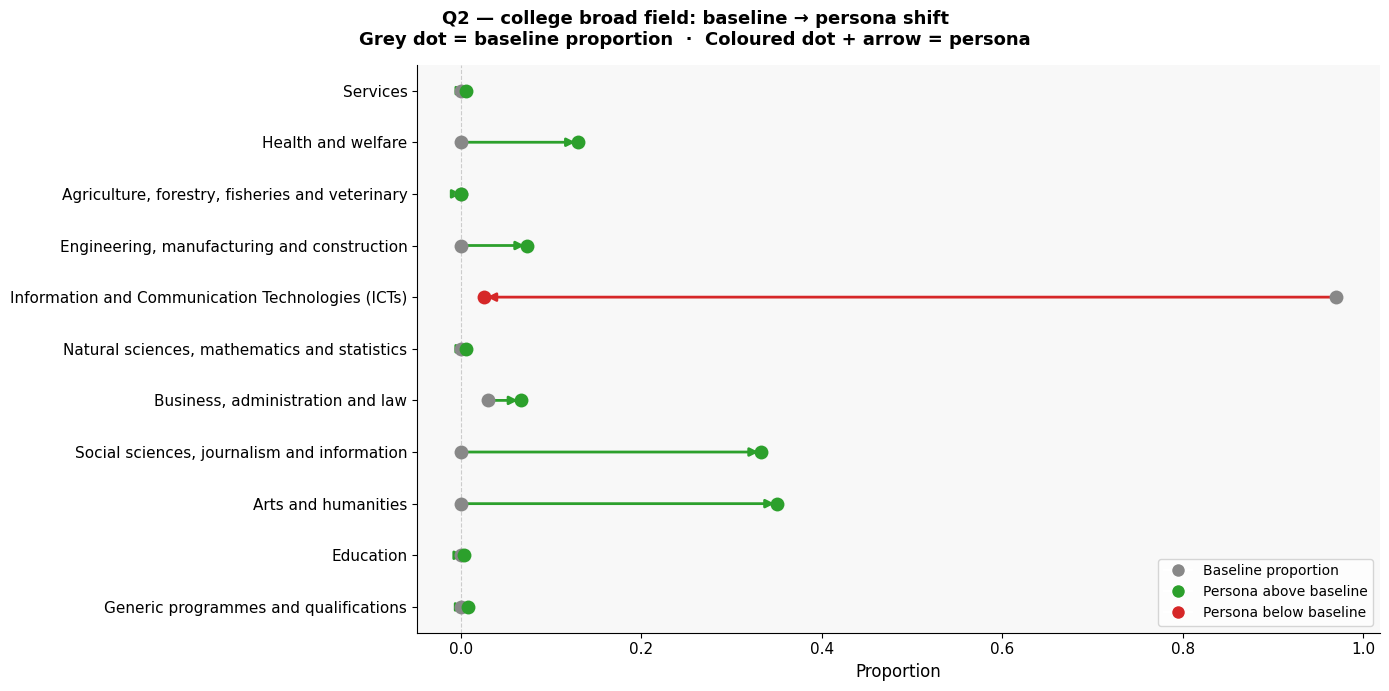

In [ ]:
# ── Idea C (alt) — Q2 only, single wide panel ─────────────────────────────
fig, ax = plt.subplots(figsize=(14, 7))
fig.suptitle(
    "Q2 — college broad field: baseline → persona shift\n"
    "Grey dot = baseline proportion  ·  Coloured dot + arrow = persona",
    fontsize=13, fontweight="bold"
)

prop_f_q2 = prop_b_q2_merged.values + dev_q2.values
n = len(levels_q2)
y = np.arange(n)

ax.set_facecolor("#F8F8F8")
ax.axvline(0, color="#cccccc", linewidth=0.8, linestyle="--")

for i in range(n):
    b = prop_b_q2_merged.values[i]
    p = prop_f_q2[i]
    color = PERSONA_UP if p >= b else PERSONA_DOWN

    ax.annotate(
        "", xy=(p, i), xytext=(b, i),
        arrowprops=dict(arrowstyle="-|>", color=color, lw=2.0, mutation_scale=12),
    )
    ax.scatter(b, i, color=BASELINE_DOT, s=100, zorder=5, linewidths=0)
    ax.scatter(p, i, color=color,        s=100, zorder=6, linewidths=0)

ax.set_yticks(y)
ax.set_yticklabels(levels_q2, fontsize=11)
ax.set_xlabel("Proportion", fontsize=12)
ax.tick_params(axis="x", labelsize=11)
ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)

from matplotlib.lines import Line2D
handles = [
    Line2D([0],[0], marker="o", color="w", markerfacecolor=BASELINE_DOT, markersize=10, label="Baseline proportion"),
    Line2D([0],[0], marker="o", color="w", markerfacecolor=PERSONA_UP,   markersize=10, label="Persona above baseline"),
    Line2D([0],[0], marker="o", color="w", markerfacecolor=PERSONA_DOWN, markersize=10, label="Persona below baseline"),
]
ax.legend(handles=handles, fontsize=10, loc="lower right")

plt.tight_layout(rect=[0, 0, 1, 0.93])
_save(fig, FIGURES_DIR / "q2_persona_shift_arrows_wide.png")


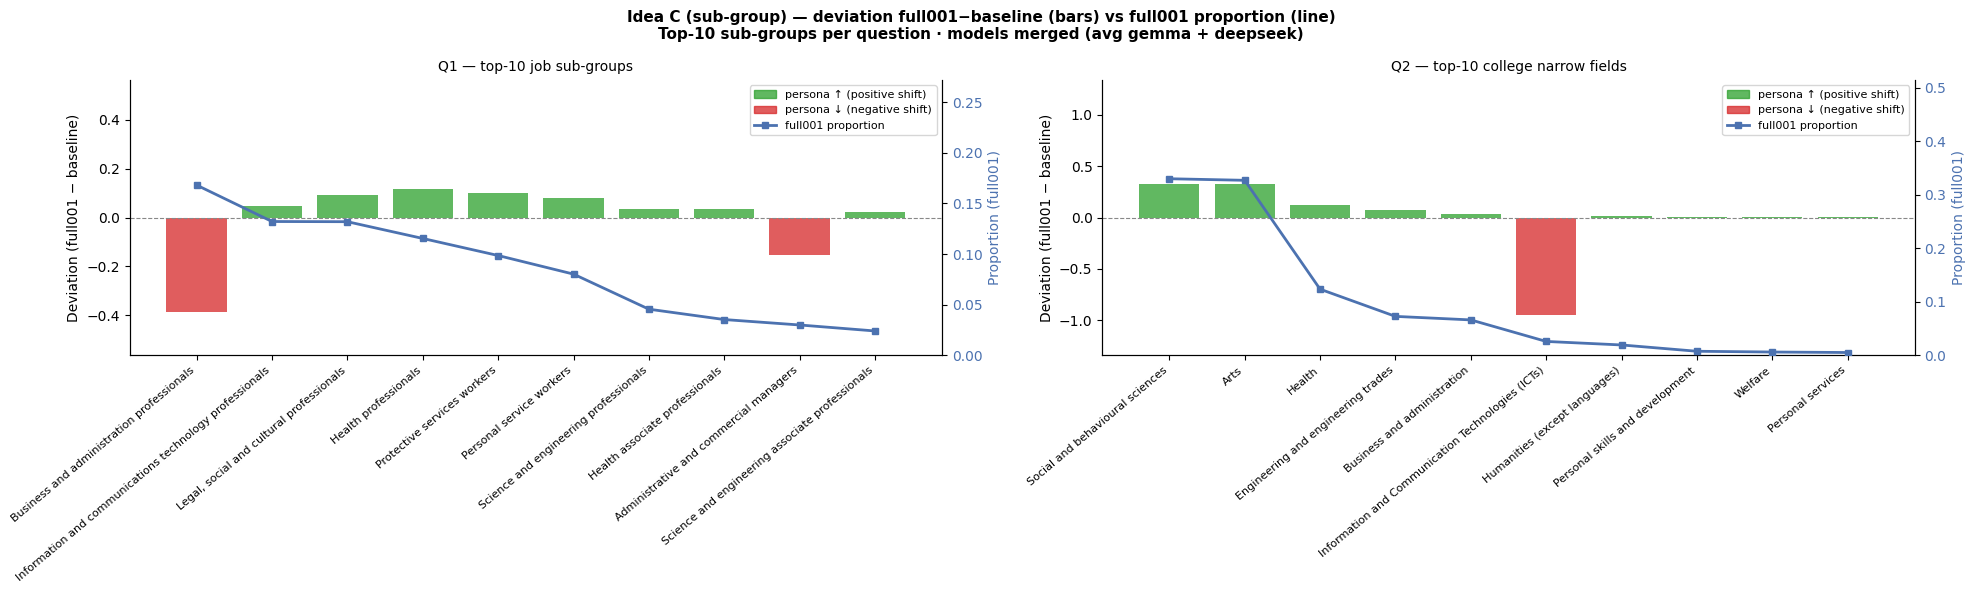

In [ ]:
# ── Idea C (sub-group variant): deviation (bars) + full001 proportion (line)
# Same encoding as Idea C but at the finer final_class level — top 10 per question.
# Baseline sub-group proportions are sparse so deviations can be large.

def _subgroup_dual_data(df_b, df_f, top_n=10):
    """
    Returns (classes, prop_b, prop_f, dev) for the top_n final_class values
    ranked by full001 frequency, models merged.
    """
    # top-N by full001 frequency (merged)
    top_classes = (
        df_f["final_class"]
        .value_counts(normalize=True)
        .head(top_n)
        .index.tolist()
    )

    def _merged(df, classes):
        per_model = [
            df[df["subject_model_alias"] == m]["final_class"]
              .value_counts(normalize=True)
              .reindex(classes, fill_value=0)
            for m in BASELINE_MODELS
            if m in df["subject_model_alias"].unique()
        ]
        return pd.concat(per_model, axis=1).mean(axis=1)

    prop_b = _merged(df_b, top_classes)
    prop_f = _merged(df_f, top_classes)
    dev    = prop_f - prop_b
    return top_classes, prop_b, prop_f, dev


classes_q1, sg_prop_b_q1, sg_prop_f_q1, sg_dev_q1 = _subgroup_dual_data(df_b_q1, df_f_q1)
classes_q2, sg_prop_b_q2, sg_prop_f_q2, sg_dev_q2 = _subgroup_dual_data(df_b_q2, df_f_q2)

# ── plot ───────────────────────────────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(20, 6))
fig.suptitle(
    "Idea C (sub-group) — deviation full001−baseline (bars) vs full001 proportion (line)\n"
    "Top-10 sub-groups per question · models merged (avg gemma + deepseek)",
    fontsize=11, fontweight="bold"
)

for ax, classes, prop_f, dev, q_label in [
    (axes[0], classes_q1, sg_prop_f_q1, sg_dev_q1, "Q1 — top-10 job sub-groups"),
    (axes[1], classes_q2, sg_prop_f_q2, sg_dev_q2, "Q2 — top-10 college narrow fields"),
]:
    x      = np.arange(len(classes))
    colors = [POS_COLOR if d >= 0 else NEG_COLOR for d in dev.values]

    # ── left axis: deviation bars ──────────────────────────────────────────
    ax.bar(x, dev.values, color=colors, alpha=0.75)
    ax.axhline(0, color=ZERO_COLOR, linewidth=0.8, linestyle="--")
    ax.set_ylabel("Deviation (full001 − baseline)", color="black")
    dev_max = max(abs(dev.values)) * 1.4 + 0.02
    ax.set_ylim(-dev_max, dev_max)

    pos_patch = mpatches.Patch(color=POS_COLOR, alpha=0.75, label="persona ↑ (positive shift)")
    neg_patch = mpatches.Patch(color=NEG_COLOR, alpha=0.75, label="persona ↓ (negative shift)")

    # ── right axis: full001 proportion line ───────────────────────────────
    ax2 = ax.twinx()
    line, = ax2.plot(x, prop_f.values, color=LINE_COLOR_C, linewidth=2, marker="s",
                     markersize=5, label="full001 proportion", zorder=5)
    ax2.set_ylabel("Proportion (full001)", color=LINE_COLOR_C)
    ax2.tick_params(axis="y", labelcolor=LINE_COLOR_C)
    ax2.set_ylim(0, max(prop_f.values) * 1.5 + 0.02)

    ax.set_xticks(x)
    ax.set_xticklabels(classes, rotation=40, ha="right", fontsize=8)
    ax.set_title(q_label, fontsize=10)
    ax.spines["top"].set_visible(False)
    ax2.spines["top"].set_visible(False)

    ax.legend(handles=[pos_patch, neg_patch, line], fontsize=8, loc="upper right")

plt.tight_layout()
fig.savefig(FIGURES_DIR / "dual_axis_ideaC_subgroup.png", bbox_inches="tight", dpi=150)
plt.show()
plt.close(fig)

### Idea D — two-subplot compact view (Q1 top · Q2 bottom), Idea-A style

Same encoding as Idea A (full001 bars + deviation line) but stacked vertically so both questions fit in one narrow figure — useful for presentations or paper figures where horizontal space is limited.

AttributeError: 'numpy.ndarray' object has no attribute 'values'

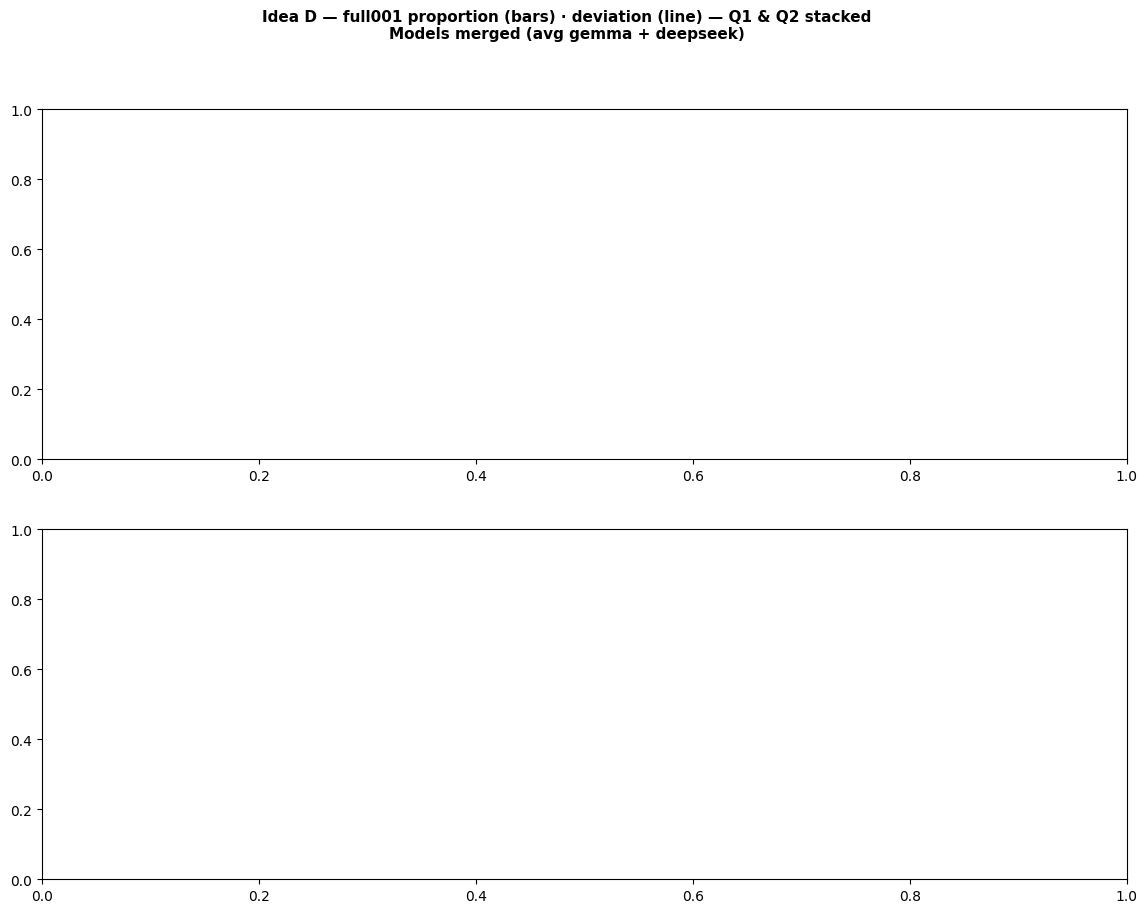

In [ ]:
# ── Idea D: vertical 2-row layout, Q1 top / Q2 bottom (Idea-A encoding) ──

fig, axes = plt.subplots(2, 1, figsize=(14, 10))
fig.suptitle(
    "Idea D — full001 proportion (bars) · deviation (line) — Q1 & Q2 stacked\n"
    "Models merged (avg gemma + deepseek)",
    fontsize=11, fontweight="bold"
)

for ax, levels, prop_f, dev, q_label in [
    (axes[0], levels_q1, prop_f_q1, dev_q1, "Q1 — job major group"),
    (axes[1], levels_q2, prop_f_q2, dev_q2, "Q2 — college broad field"),
]:
    x = np.arange(len(levels))

    # ── left axis: full001 proportion bars ────────────────────────────────
    ax.bar(x, prop_f.values, color=BAR_COLOR, alpha=0.65, label="full001 proportion")
    ax.set_ylabel("Proportion (full001)", color=BAR_COLOR)
    ax.tick_params(axis="y", labelcolor=BAR_COLOR)
    ax.set_ylim(0, max(prop_f.values) * 1.45 + 0.02)

    # ── right axis: deviation line ─────────────────────────────────────────
    ax2 = ax.twinx()
    ax2.plot(x, dev.values, color=LINE_COLOR, linewidth=2, marker="o",
             markersize=5, label="deviation (full001−baseline)", zorder=5)
    ax2.axhline(0, color=ZERO_COLOR, linewidth=0.8, linestyle="--")
    ax2.set_ylabel("Deviation (full001 − baseline)", color=LINE_COLOR)
    ax2.tick_params(axis="y", labelcolor=LINE_COLOR)
    dev_max = max(abs(dev.values)) * 1.35 + 0.02
    ax2.set_ylim(-dev_max, dev_max)

    # shade bars red/blue depending on sign of deviation
    for xi, d in zip(x, dev.values):
        edge = "#D62728" if d < 0 else "#2CA02C"
        ax.patches[xi].set_edgecolor(edge)
        ax.patches[xi].set_linewidth(1.8)

    ax.set_xticks(x)
    ax.set_xticklabels(levels, rotation=35, ha="right", fontsize=8)
    ax.set_title(q_label, fontsize=10, fontweight="bold")
    ax.spines["top"].set_visible(False)
    ax2.spines["top"].set_visible(False)

    h1, l1 = ax.get_legend_handles_labels()
    h2, l2 = ax2.get_legend_handles_labels()
    ax.legend(h1 + h2, l1 + l2, fontsize=8, loc="upper right")
    ax.annotate(
        "bar edge: green = persona ↑, red = persona ↓",
        xy=(0.01, 0.97), xycoords="axes fraction",
        fontsize=7, va="top", color="#555555"
    )

plt.tight_layout()
fig.savefig(FIGURES_DIR / "dual_axis_ideaD.png", bbox_inches="tight", dpi=150)
plt.show()
plt.close(fig)

## 11. Deviation breakdowns — sliced by demographic and model

The previous section showed deviations merged across all conditions.
Here we slice the deviation (full001 − baseline) by **gender**, **region**, and **model** to reveal *who* drives the shift.

Four complementary ideas:

- **Idea E** — Deviation heatmap (groups × slices) — full overview in one grid
- **Idea F** — Diverging horizontal bars per demographic variable — direction at a glance
- **Idea G** — Bubble scatter: baseline proportion vs deviation, bubble = full001 proportion
- **Idea H** — Radar / spider chart — profile shape across groups per demographic slice

In [ ]:
# ── Shared helpers for deviation breakdowns ───────────────────────────────

def _baseline_merged_prop(df_b, group_col, levels):
    """Merged baseline proportion (avg across models)."""
    per_model = [
        df_b[df_b["subject_model_alias"] == m][group_col]
          .value_counts(normalize=True)
          .reindex(levels, fill_value=0)
        for m in BASELINE_MODELS
        if m in df_b["subject_model_alias"].unique()
    ]
    return pd.concat(per_model, axis=1).mean(axis=1)


def _dev_table(df_b, df_f, group_col, group_map, slices_col, baseline_prop=None):
    """
    Build a DataFrame of deviations:
      rows = group levels, columns = each slice value.
    baseline_prop: Series (level → proportion). If None, use merged baseline.
    """
    levels = list(dict.fromkeys(group_map.values()))
    if baseline_prop is None:
        baseline_prop = _baseline_merged_prop(df_b, group_col, levels)

    slices = sorted(df_f[slices_col].dropna().unique())
    rows = {}
    for sl in slices:
        sub = df_f[df_f[slices_col] == sl]
        pf  = sub[group_col].value_counts(normalize=True).reindex(levels, fill_value=0)
        rows[sl] = (pf - baseline_prop).values
    return pd.DataFrame(rows, index=levels)


# pre-build deviation tables
levels_q1 = list(dict.fromkeys(Q1_MAJOR_GROUPS.values()))
levels_q2 = list(dict.fromkeys(Q2_BROAD_FIELDS.values()))

prop_b_q1_merged = _baseline_merged_prop(df_b_q1, "major_group", levels_q1)
prop_b_q2_merged = _baseline_merged_prop(df_b_q2, "broad_field", levels_q2)

dev_gender_q1  = _dev_table(df_b_q1, df_f_q1, "major_group", Q1_MAJOR_GROUPS, "true_gender")
dev_race_q1    = _dev_table(df_b_q1, df_f_q1, "major_group", Q1_MAJOR_GROUPS, "true_race")
dev_model_q1   = _dev_table(df_b_q1, df_f_q1, "major_group", Q1_MAJOR_GROUPS, "subject_model_alias")
dev_model_q1.columns = [MODEL_LABELS.get(c, c) for c in dev_model_q1.columns]

dev_gender_q2  = _dev_table(df_b_q2, df_f_q2, "broad_field", Q2_BROAD_FIELDS, "true_gender")
dev_race_q2    = _dev_table(df_b_q2, df_f_q2, "broad_field", Q2_BROAD_FIELDS, "true_race")
dev_model_q2   = _dev_table(df_b_q2, df_f_q2, "broad_field", Q2_BROAD_FIELDS, "subject_model_alias")
dev_model_q2.columns = [MODEL_LABELS.get(c, c) for c in dev_model_q2.columns]

print("deviation tables ready")
print("dev_gender_q1:", dev_gender_q1.shape, "  dev_race_q1:", dev_race_q1.shape)

deviation tables ready
dev_gender_q1: (10, 2)   dev_race_q1: (10, 8)


### Idea E — Deviation heatmap (groups × demographic slices)

Rows = group levels, columns = demographic slice (gender, region, model).
Cell colour encodes deviation magnitude and direction (red = persona pushed more, blue = less than baseline).
The heatmap gives the full picture in one compact grid — easy to spot which groups are sensitive to which demographic dimensions.

/var/folders/bq/hdtlcyk572l9dklh54vxrpg80000gn/T/ipykernel_35752/121394856.py:66: UserWarning: Tight layout not applied. The bottom and top margins cannot be made large enough to accommodate all Axes decorations.
  plt.tight_layout()


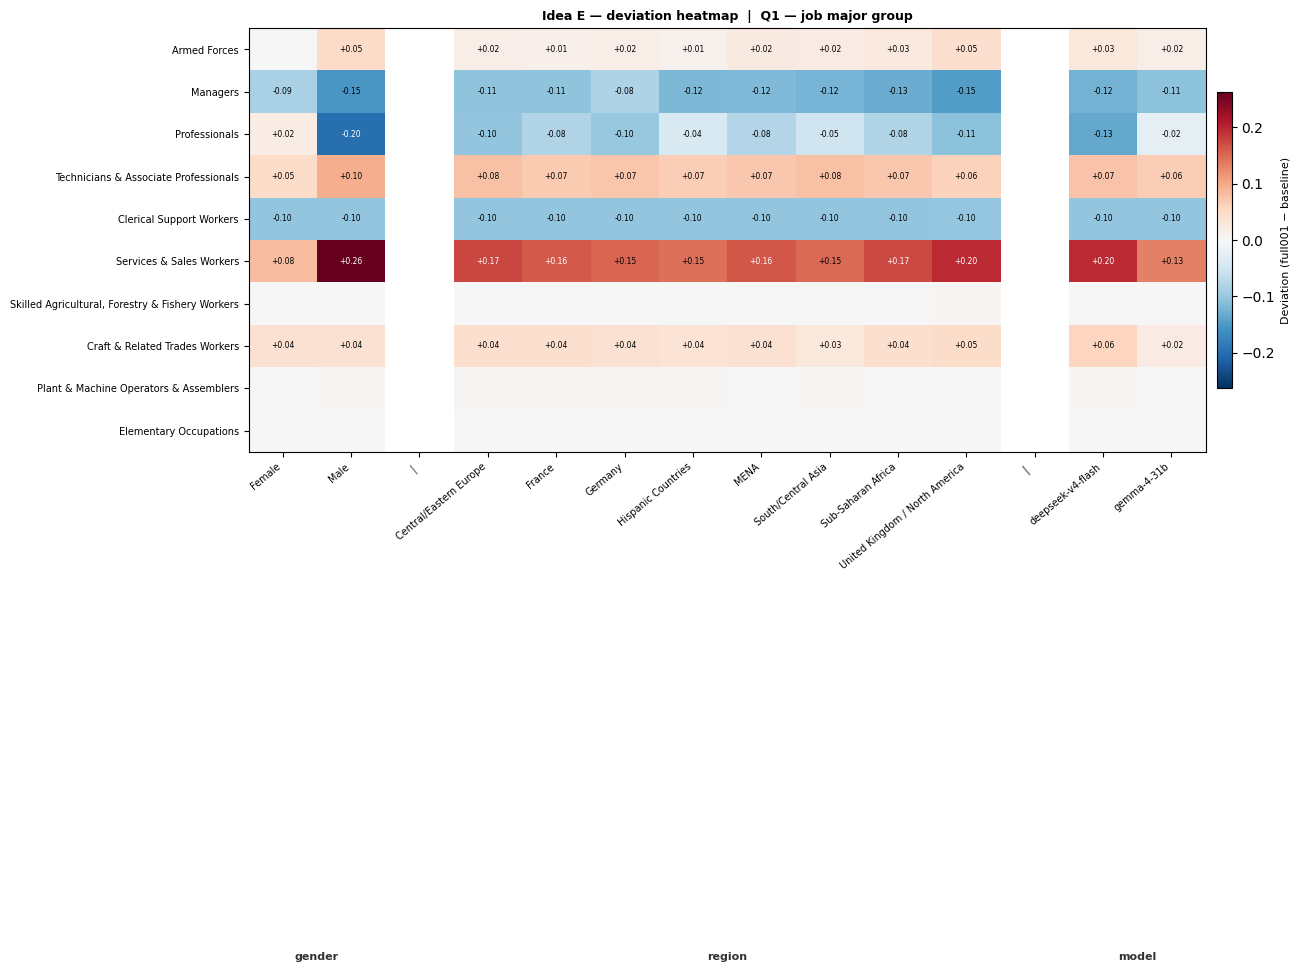

/var/folders/bq/hdtlcyk572l9dklh54vxrpg80000gn/T/ipykernel_35752/121394856.py:66: UserWarning: Tight layout not applied. The bottom and top margins cannot be made large enough to accommodate all Axes decorations.
  plt.tight_layout()


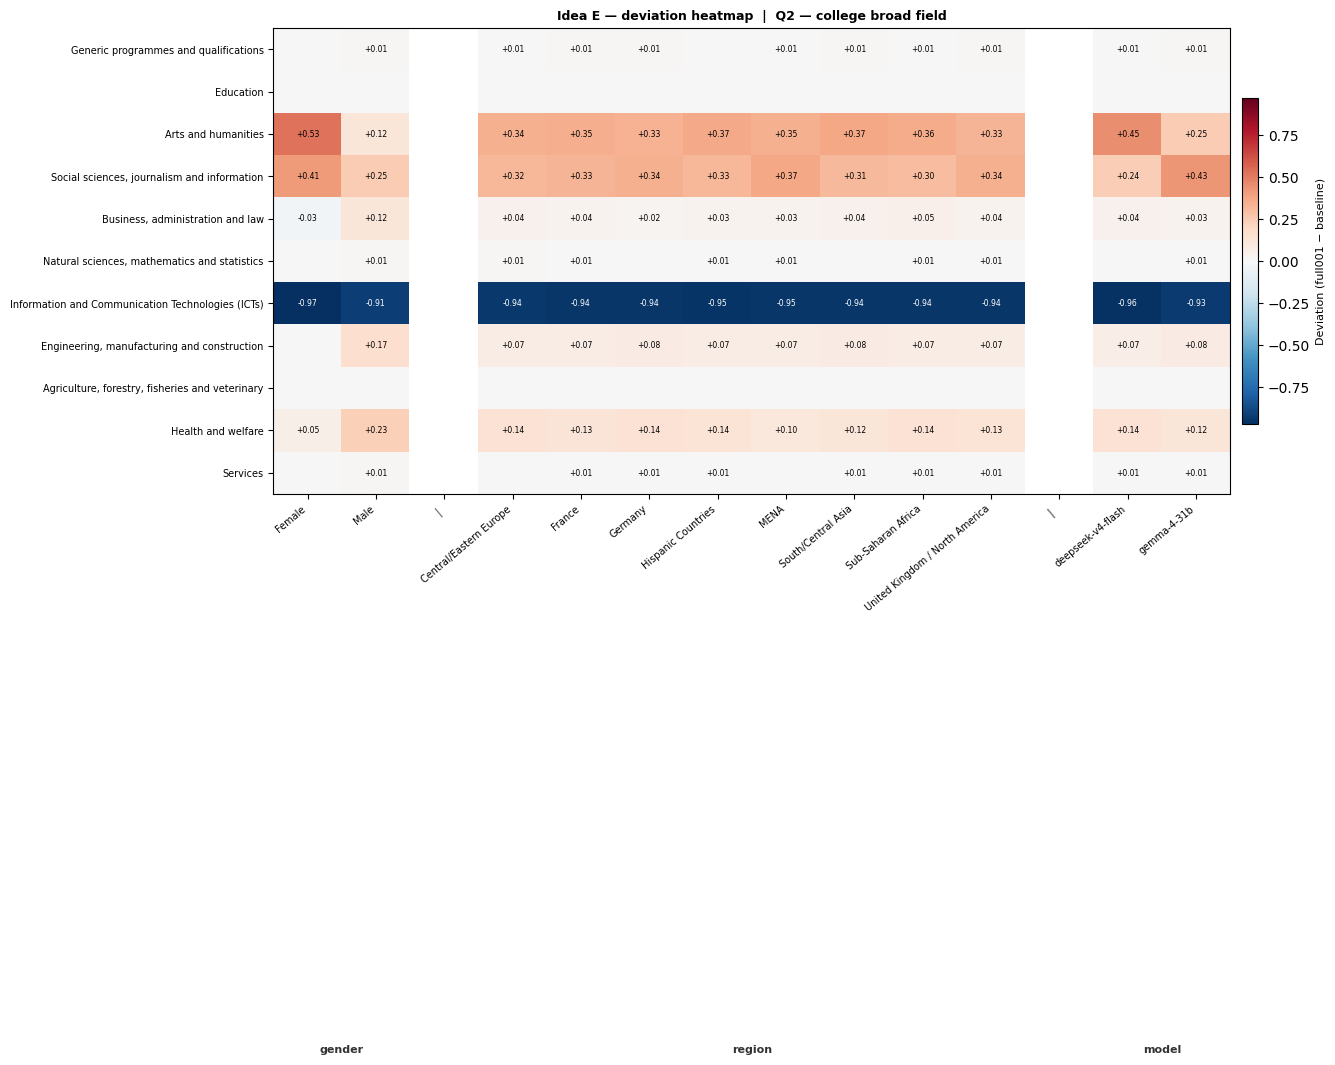

In [ ]:
# ── Idea E: Deviation heatmap (groups × slices) ───────────────────────────
# Two rows: Q1 (left), Q2 (right). Each panel: concat gender + region + model cols.

import matplotlib.colors as mcolors

def _draw_heatmap(ax, dev_df, title, vmax=None):
    """Draw a diverging heatmap on ax."""
    data  = dev_df.values.astype(float)
    if vmax is None:
        vmax = np.nanmax(np.abs(data)) * 1.05
    cmap  = plt.cm.RdBu_r
    norm  = mcolors.TwoSlopeNorm(vmin=-vmax, vcenter=0, vmax=vmax)
    im    = ax.imshow(data, cmap=cmap, norm=norm, aspect="auto")

    ax.set_xticks(range(dev_df.shape[1]))
    ax.set_xticklabels(dev_df.columns, rotation=40, ha="right", fontsize=7)
    ax.set_yticks(range(dev_df.shape[0]))
    ax.set_yticklabels(dev_df.index, fontsize=7)
    ax.set_title(title, fontsize=9, fontweight="bold")

    # annotate cells
    for r in range(data.shape[0]):
        for c in range(data.shape[1]):
            val = data[r, c]
            if abs(val) > 0.005:
                ax.text(c, r, f"{val:+.2f}", ha="center", va="center",
                        fontsize=5.5, color="black" if abs(val) < vmax * 0.6 else "white")
    return im


for q_label, dev_g, dev_r, dev_m in [
    ("Q1 — job major group",       dev_gender_q1, dev_race_q1, dev_model_q1),
    ("Q2 — college broad field",   dev_gender_q2, dev_race_q2, dev_model_q2),
]:
    # concat all slice types with a separator column of NaNs
    sep   = pd.DataFrame(np.nan, index=dev_g.index, columns=["│"])
    full  = pd.concat([dev_g, sep, dev_r, sep.rename(columns={"│": "│ "}), dev_m], axis=1)
    vmax  = max(abs(full.values[~np.isnan(full.values)].max()),
                abs(full.values[~np.isnan(full.values)].min()))

    fig, ax = plt.subplots(figsize=(max(14, full.shape[1] * 1.05), max(4, full.shape[0] * 0.55)))
    im = _draw_heatmap(ax, full, f"Idea E — deviation heatmap  |  {q_label}", vmax=vmax)

    # vertical dividers between sections
    for xi, col in enumerate(full.columns):
        if col.startswith("│"):
            ax.axvline(xi, color="white", linewidth=3)

    # colour bar
    cb = fig.colorbar(im, ax=ax, shrink=0.7, pad=0.01)
    cb.set_label("Deviation (full001 − baseline)", fontsize=8)

    # section labels above
    n_g = dev_g.shape[1]
    n_r = dev_r.shape[1]
    n_m = dev_m.shape[1]
    for label, centre in [
        ("gender", (n_g - 1) / 2),
        ("region", n_g + 1 + (n_r - 1) / 2),
        ("model",  n_g + 1 + n_r + 1 + (n_m - 1) / 2),
    ]:
        ax.annotate(label, xy=(centre, -1.2), xycoords=("data", "axes fraction"),
                    ha="center", fontsize=8, color="#333333", fontweight="bold",
                    annotation_clip=False)

    plt.tight_layout()
    slug = q_label.split("—")[0].strip().lower().replace(" ", "_")
    fig.savefig(FIGURES_DIR / f"deviation_heatmap_{slug}.png", bbox_inches="tight", dpi=150)
    plt.show()
    plt.close(fig)

### Idea F — Diverging horizontal bar chart per demographic variable

Three panels per question: one for gender, one for region, one for model.
Each panel has groups on the Y-axis; bars extend left (negative deviation) or right (positive deviation) from a central zero line.
Horizontal bars make long group names readable and the zero line makes direction immediately obvious.

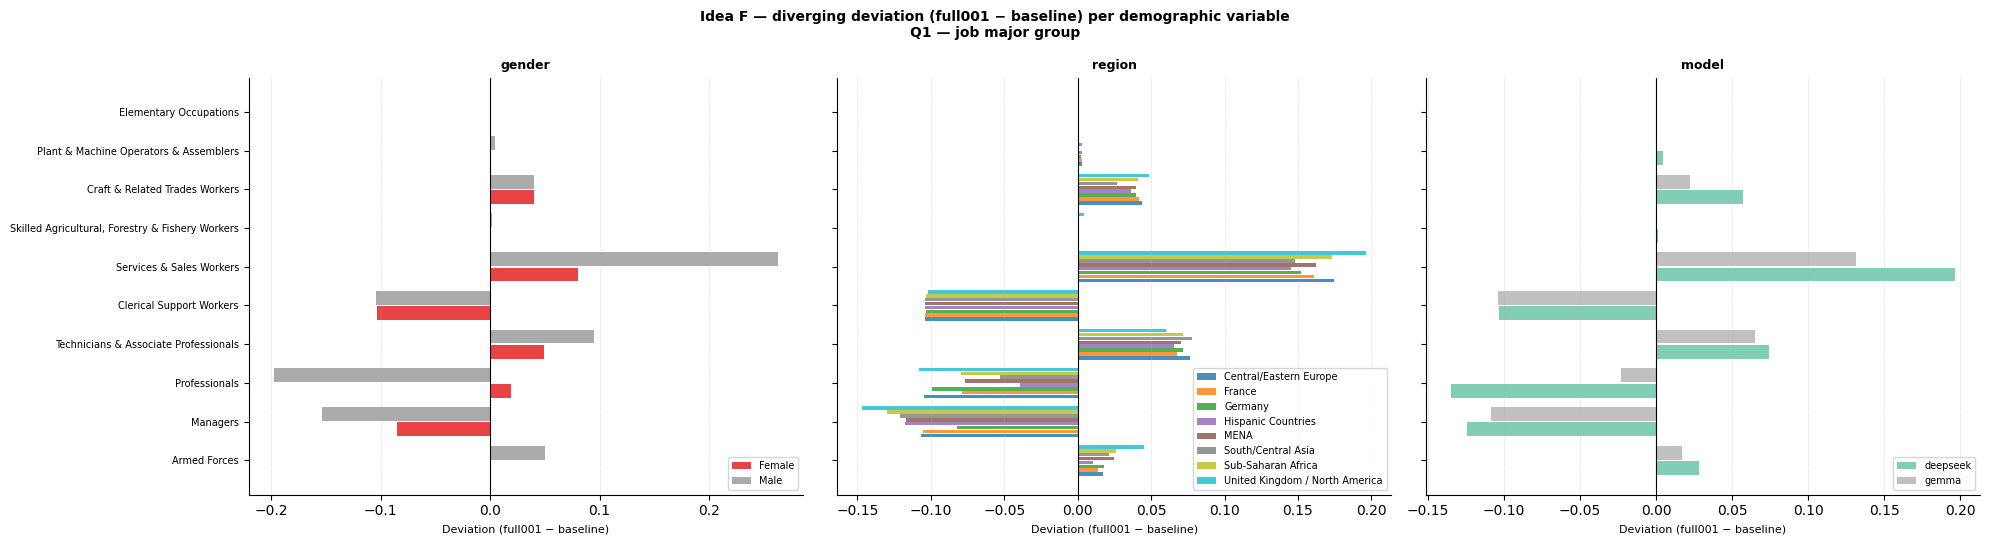

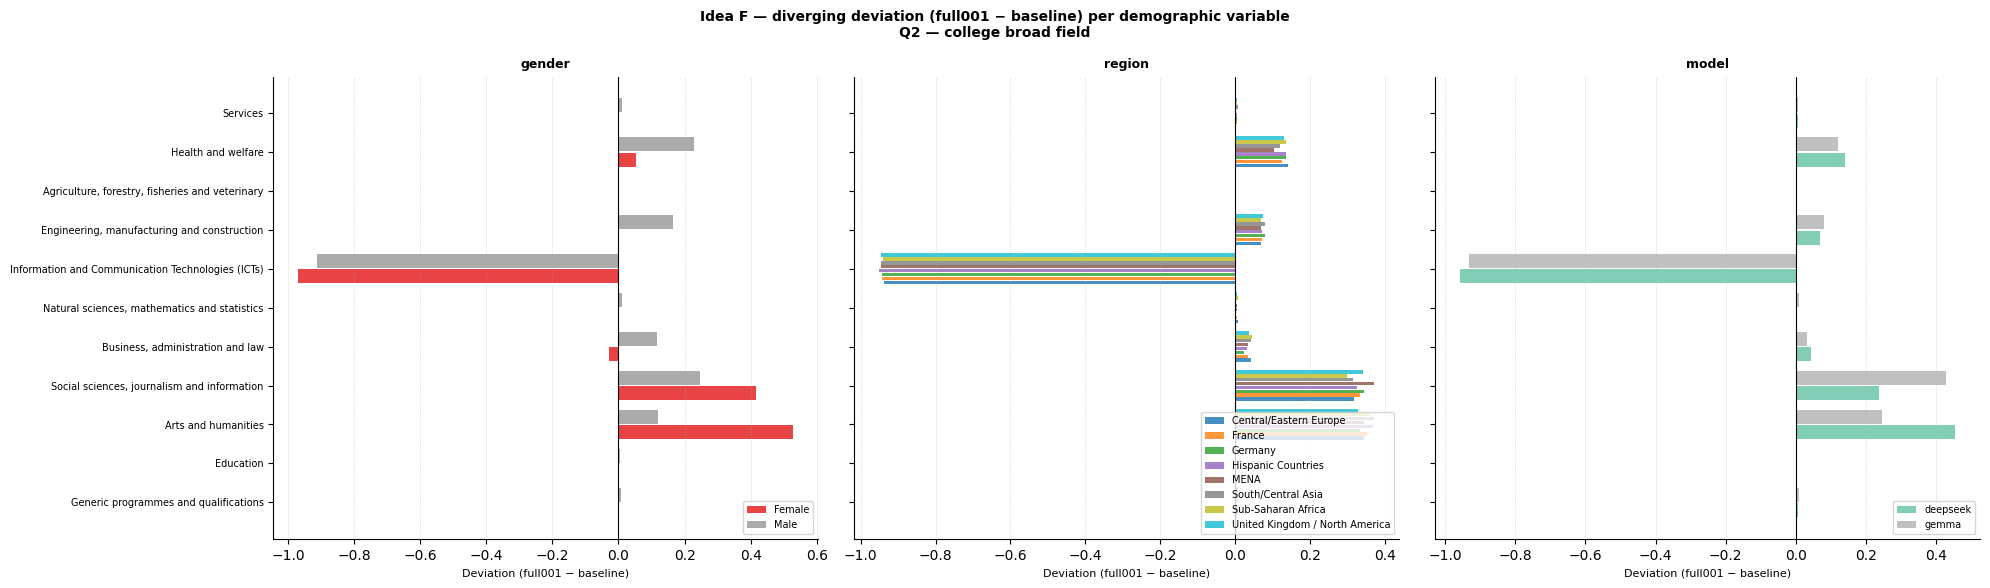

In [ ]:
# ── Idea F: Diverging horizontal bars per demographic variable ─────────────
# 3 panels per question: gender | region | model

SLICE_CMAPS = {
    "gender": plt.cm.Set1,
    "region": plt.cm.tab10,
    "model":  plt.cm.Set2,
}

for q_label, dev_g, dev_r, dev_m, levels in [
    ("Q1 — job major group",     dev_gender_q1, dev_race_q1, dev_model_q1, levels_q1),
    ("Q2 — college broad field", dev_gender_q2, dev_race_q2, dev_model_q2, levels_q2),
]:
    panels = [
        ("gender", dev_g, SLICE_CMAPS["gender"]),
        ("region", dev_r, SLICE_CMAPS["region"]),
        ("model",  dev_m, SLICE_CMAPS["model"]),
    ]
    n_groups = len(levels)
    fig, axes = plt.subplots(1, 3, figsize=(20, max(4, n_groups * 0.45 + 1)),
                              sharey=True)
    fig.suptitle(
        f"Idea F — diverging deviation (full001 − baseline) per demographic variable\n{q_label}",
        fontsize=10, fontweight="bold"
    )

    for ax, (dim_name, dev_df, cmap) in zip(axes, panels):
        slices  = dev_df.columns.tolist()
        y       = np.arange(n_groups)
        bar_h   = 0.8 / max(len(slices), 1)

        for si, sl in enumerate(slices):
            vals   = dev_df[sl].values
            color  = cmap(si / max(len(slices) - 1, 1))
            # short label for legend
            short  = sl.replace("gemma-4-31b", "gemma").replace("deepseek-v4-flash", "deepseek")
            ax.barh(y + si * bar_h - bar_h * (len(slices) - 1) / 2,
                    vals, bar_h * 0.9, color=color, alpha=0.82, label=short)

        ax.axvline(0, color="black", linewidth=0.8)
        ax.set_yticks(y)
        ax.set_yticklabels(levels, fontsize=7)
        ax.set_xlabel("Deviation (full001 − baseline)", fontsize=8)
        ax.set_title(dim_name, fontsize=9, fontweight="bold")
        ax.legend(fontsize=7, loc="lower right")
        ax.spines["top"].set_visible(False)
        ax.spines["right"].set_visible(False)
        ax.grid(axis="x", linestyle="--", linewidth=0.4, alpha=0.5)

    plt.tight_layout()
    slug = q_label.split("—")[0].strip().lower().replace(" ", "_")
    fig.savefig(FIGURES_DIR / f"deviation_diverging_{slug}.png", bbox_inches="tight", dpi=150)
    plt.show()
    plt.close(fig)

### Idea G — Bubble scatter: baseline proportion vs deviation

X = baseline proportion (how often the model picks this group without any persona).
Y = deviation (how much persona context shifts it).
Bubble size = full001 proportion (where the group ends up).
Colour = group category.

Each bubble is one group. Bubbles in the top-right are popular even at baseline and persona pushes them even higher. Bubbles in the top-left are "unlocked" — rare at baseline but boosted by persona. Bottom quadrants show groups that persona suppresses.

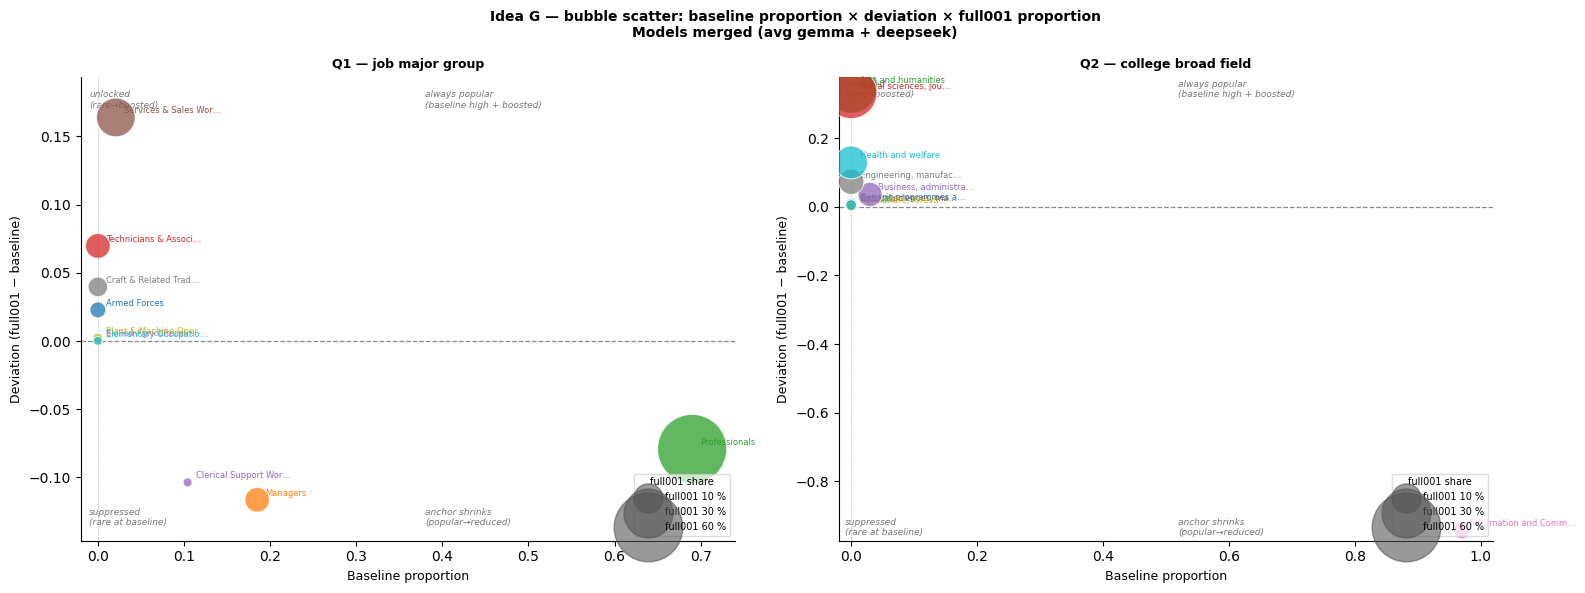

In [ ]:
# ── Idea G: Bubble scatter — baseline prop vs deviation ───────────────────
# One scatter panel per question. Each bubble = one group level.
# X  = baseline proportion (merged)
# Y  = deviation (full001 − baseline, merged)
# size = full001 proportion (merged)
# colour = group identity

fig, axes = plt.subplots(1, 2, figsize=(16, 6))
fig.suptitle(
    "Idea G — bubble scatter: baseline proportion × deviation × full001 proportion\n"
    "Models merged (avg gemma + deepseek)",
    fontsize=10, fontweight="bold"
)

for ax, levels, prop_b, dev, prop_f, q_label in [
    (axes[0], levels_q1, prop_b_q1_merged, dev_q1, prop_f_q1, "Q1 — job major group"),
    (axes[1], levels_q2, prop_b_q2_merged, dev_q2, prop_f_q2, "Q2 — college broad field"),
]:
    cmap   = plt.cm.tab10
    n      = len(levels)
    colors = [cmap(i / max(n - 1, 1)) for i in range(n)]
    sizes  = prop_f.values * 4000 + 40   # scale bubble area

    sc = ax.scatter(
        prop_b.values, dev.values,
        s=sizes, c=colors, alpha=0.75, edgecolors="white", linewidths=0.8, zorder=5
    )

    # zero lines
    ax.axhline(0, color="#888888", linewidth=0.9, linestyle="--", zorder=2)
    ax.axvline(0, color="#888888", linewidth=0.5, linestyle=":", zorder=2)

    # quadrant labels
    xl, xr = ax.get_xlim() if ax.get_xlim() != (0,1) else (prop_b.min()-0.02, prop_b.max()+0.05)
    # just use data bounds
    xmax = prop_b.values.max() + 0.05
    xmin = -0.02
    ymax = dev.values.max() + 0.03
    ymin = dev.values.min() - 0.03
    ax.set_xlim(xmin, xmax)
    ax.set_ylim(ymin, ymax)
    mid_x = (xmin + xmax) / 2
    mid_y = (ymin + ymax) / 2
    for txt, xi, yi, ha in [
        ("unlocked\n(rare→boosted)", xmin + 0.01, ymax - 0.01, "left"),
        ("always popular\n(baseline high + boosted)", mid_x + 0.02, ymax - 0.01, "left"),
        ("suppressed\n(rare at baseline)", xmin + 0.01, ymin + 0.01, "left"),
        ("anchor shrinks\n(popular→reduced)", mid_x + 0.02, ymin + 0.01, "left"),
    ]:
        ax.text(xi, yi, txt, fontsize=6.5, color="#777777", va="top" if yi > 0 else "bottom",
                ha=ha, style="italic")

    # label each bubble
    for i, (lv, xv, yv) in enumerate(zip(levels, prop_b.values, dev.values)):
        short = lv if len(lv) < 22 else lv[:20] + "…"
        ax.annotate(short, (xv, yv), textcoords="offset points", xytext=(6, 3),
                    fontsize=6, color=colors[i])

    ax.set_xlabel("Baseline proportion", fontsize=9)
    ax.set_ylabel("Deviation (full001 − baseline)", fontsize=9)
    ax.set_title(q_label, fontsize=9, fontweight="bold")
    ax.spines["top"].set_visible(False)
    ax.spines["right"].set_visible(False)

    # size legend
    for ref_p, label in [(0.1, "10 %"), (0.3, "30 %"), (0.6, "60 %")]:
        ax.scatter([], [], s=ref_p * 4000 + 40, c="#555555", alpha=0.6,
                   label=f"full001 {label}")
    ax.legend(fontsize=7, title="full001 share", title_fontsize=7,
              loc="lower right", framealpha=0.7)

plt.tight_layout()
fig.savefig(FIGURES_DIR / "deviation_bubble_scatter.png", bbox_inches="tight", dpi=150)
plt.show()
plt.close(fig)

### Idea H — Radar / spider chart per demographic slice

Each axis of the radar = one group level. Each polygon = one demographic slice (gender or region).
The polygon area shows the overall deviation profile — a slice that mostly overlaps baseline is close to zero on all axes; a spike means persona strongly pushed that group for that demographic.

Two figures: one per question, each with two panels (gender / region).

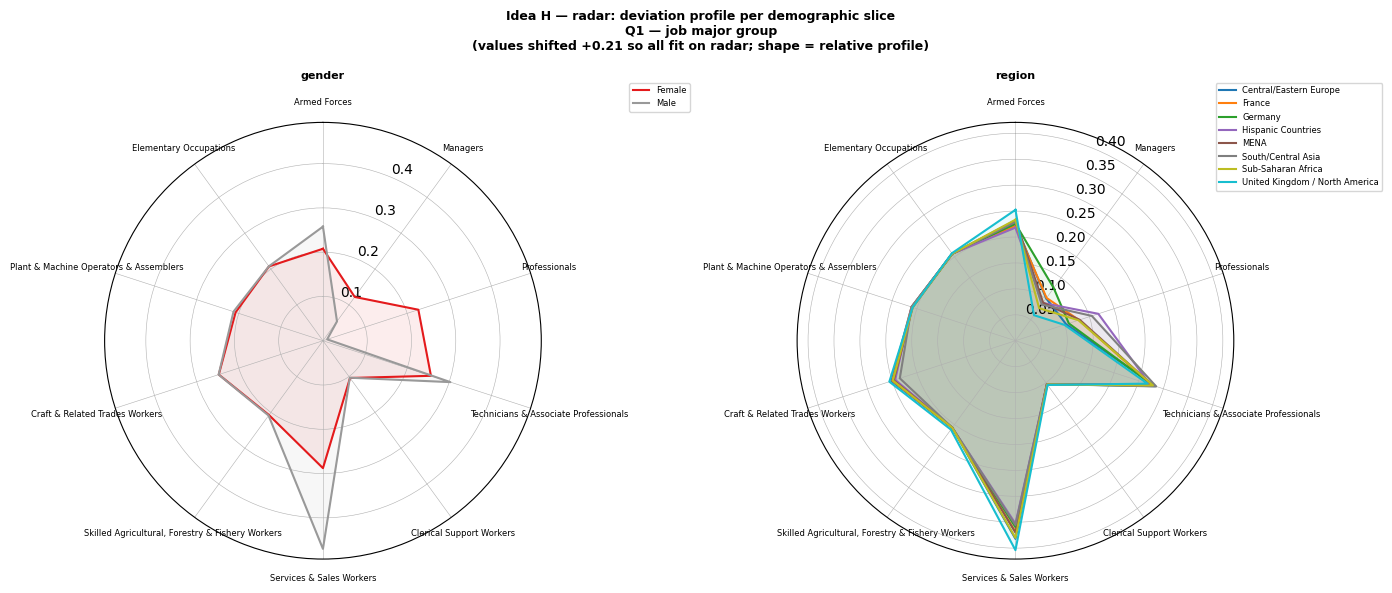

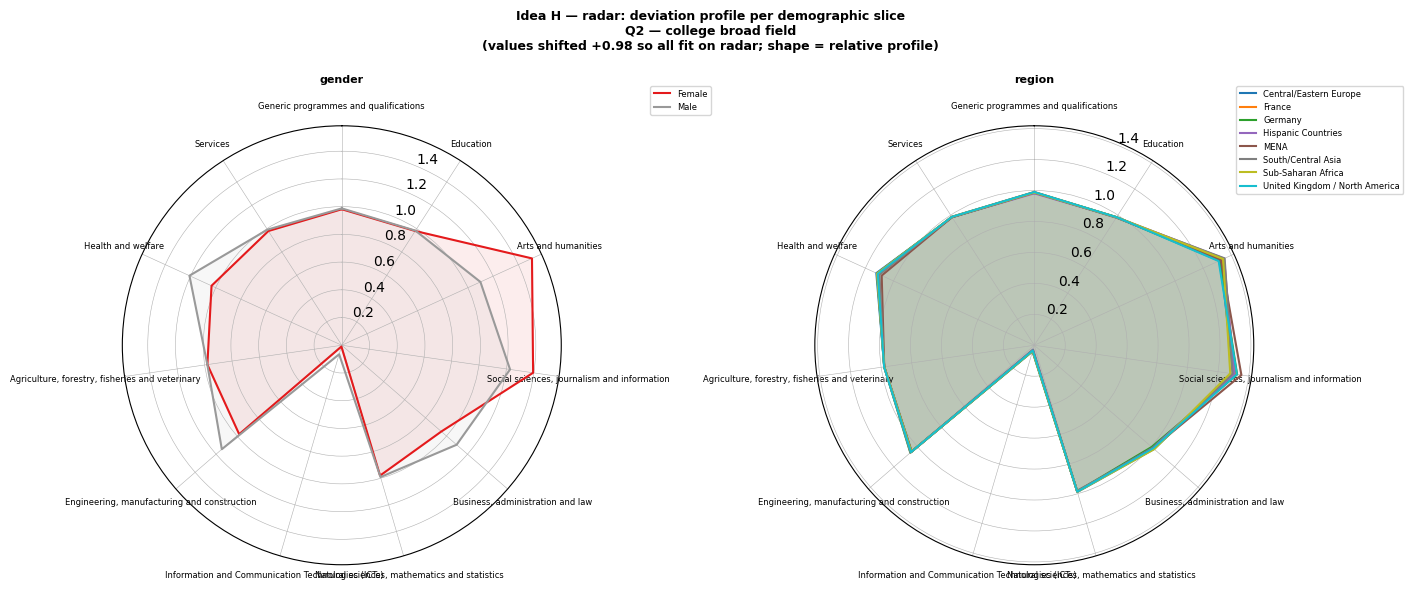

In [ ]:
# ── Idea H: Radar / spider chart ──────────────────────────────────────────
# Radar axes = group levels. Each line = one demographic slice.
# Values = deviation (full001 − baseline). Negative deviation shown as 0 in
# one panel variant; second panel uses abs(dev) to compare magnitude only.

def _radar(ax, dev_df, title, cmap, offset=0.0):
    """
    Draw a radar chart on a polar ax.
    dev_df: rows=levels, columns=slices.
    offset: shift all values up so negative deviations are visible (radar can't show negatives).
    """
    labels  = dev_df.index.tolist()
    n       = len(labels)
    angles  = np.linspace(0, 2 * np.pi, n, endpoint=False).tolist()
    angles += angles[:1]   # close the polygon

    ax.set_theta_offset(np.pi / 2)
    ax.set_theta_direction(-1)
    ax.set_thetagrids(np.degrees(angles[:-1]), labels, fontsize=6)

    slices = dev_df.columns.tolist()
    for si, sl in enumerate(slices):
        vals = dev_df[sl].values + offset
        vals = np.clip(vals, 0, None)        # radar can't show negative radii
        vals = np.append(vals, vals[0])
        color = cmap(si / max(len(slices) - 1, 1))
        short = sl.replace("gemma-4-31b", "gemma").replace("deepseek-v4-flash", "deepseek")
        ax.plot(angles, vals, linewidth=1.5, color=color, label=short)
        ax.fill(angles, vals, alpha=0.08, color=color)

    ax.set_title(title, size=8, fontweight="bold", pad=14)
    ax.legend(fontsize=6, loc="upper right", bbox_to_anchor=(1.35, 1.1))
    ax.grid(linewidth=0.4)


for q_label, dev_g, dev_r, levels in [
    ("Q1 — job major group",     dev_gender_q1, dev_race_q1, levels_q1),
    ("Q2 — college broad field", dev_gender_q2, dev_race_q2, levels_q2),
]:
    # shift so that even negative deviations land above zero on the radar
    all_vals = np.concatenate([dev_g.values.ravel(), dev_r.values.ravel()])
    offset   = max(0, -all_vals.min()) + 0.01

    fig, axes = plt.subplots(1, 2, figsize=(14, 6),
                              subplot_kw={"polar": True})
    fig.suptitle(
        f"Idea H — radar: deviation profile per demographic slice\n{q_label}\n"
        f"(values shifted +{offset:.2f} so all fit on radar; shape = relative profile)",
        fontsize=9, fontweight="bold"
    )

    _radar(axes[0], dev_g, "gender",  SLICE_CMAPS["gender"], offset=offset)
    _radar(axes[1], dev_r, "region",  SLICE_CMAPS["region"], offset=offset)

    plt.tight_layout()
    slug = q_label.split("—")[0].strip().lower().replace(" ", "_")
    fig.savefig(FIGURES_DIR / f"deviation_radar_{slug}.png", bbox_inches="tight", dpi=150)
    plt.show()
    plt.close(fig)

## 12. Baseline vs full001 deviation — Male vs Female personas

For each group level, how differently does persona context shift the model recommendations between **male** and **female** personas compared to the baseline?

- **Left panels**: deviation (full001 − baseline) per group, side-by-side bars for Male vs Female
- **Right panels**: gender gap = deviation(Female) − deviation(Male) — positive means female personas steer models more toward this group than male personas do

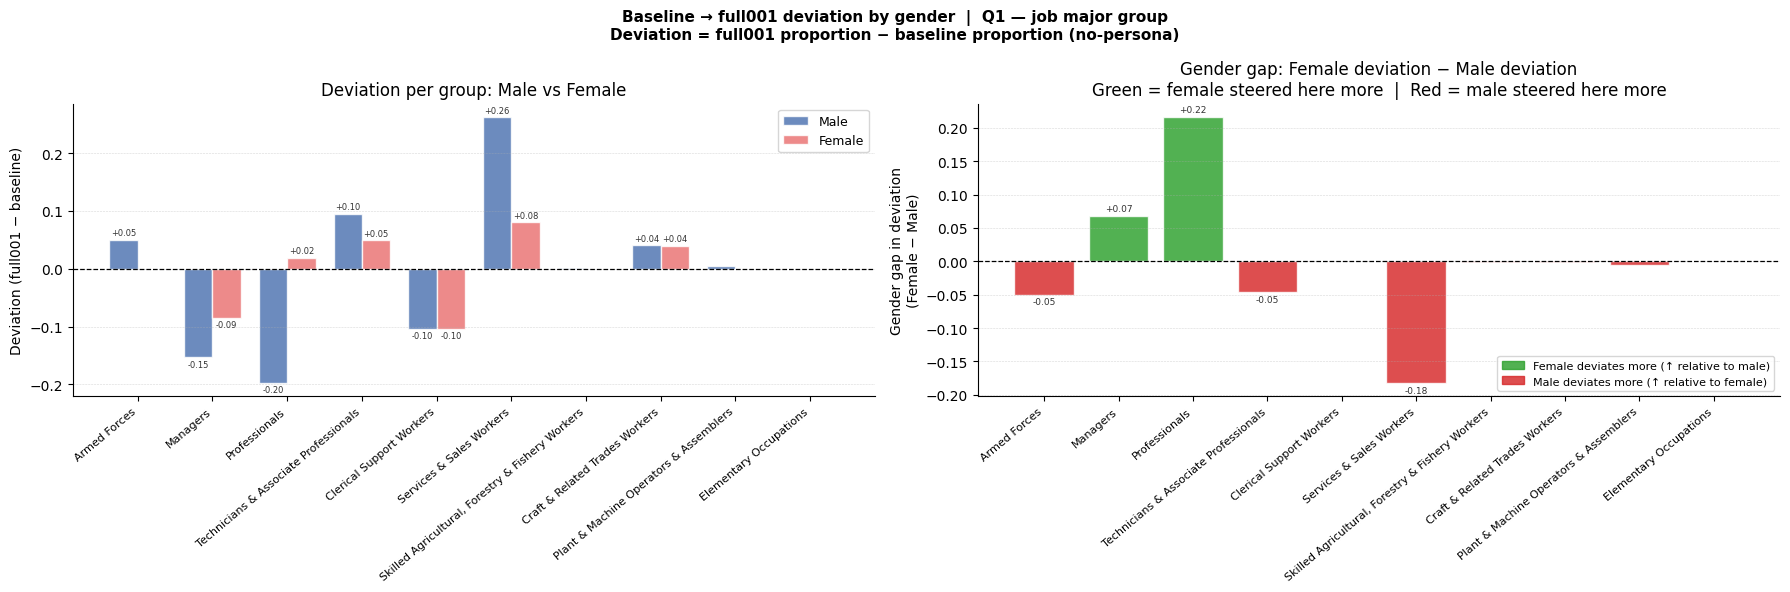

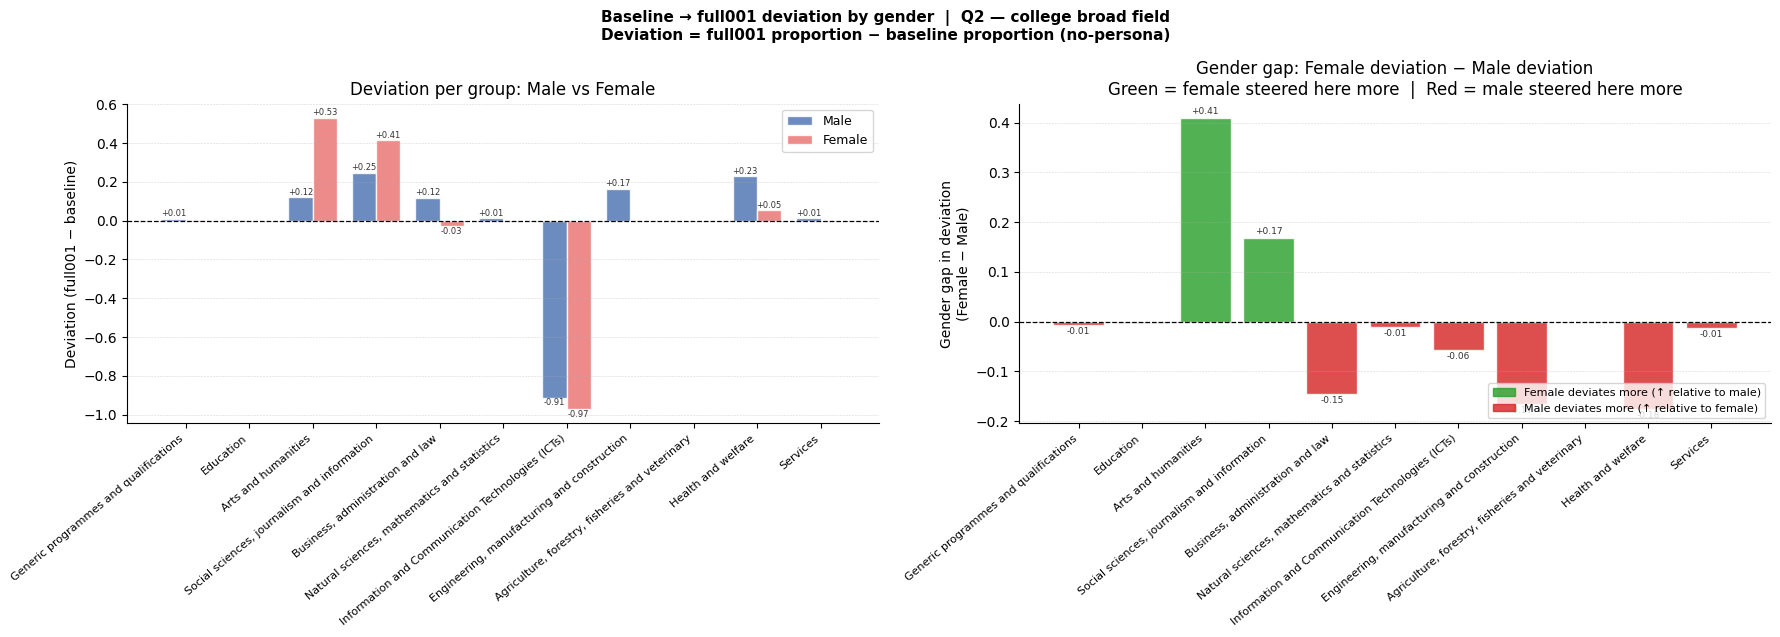


Q1 — job major group
                                                  Male dev  Female dev  Gap (F−M)
Armed Forces                                        +0.050      +0.000     -0.050
Managers                                            -0.153      -0.085     +0.068
Professionals                                       -0.197      +0.019     +0.217
Technicians & Associate Professionals               +0.095      +0.049     -0.046
Clerical Support Workers                            -0.104      -0.103     +0.001
Services & Sales Workers                            +0.263      +0.080     -0.182
Skilled Agricultural, Forestry & Fishery Workers    +0.001      +0.000     -0.001
Craft & Related Trades Workers                      +0.040      +0.040     -0.000
Plant & Machine Operators & Assemblers              +0.005      +0.000     -0.005
Elementary Occupations                              +0.000      +0.000     -0.000

Q2 — college broad field
                                                  

In [ ]:
# ── 12. Baseline vs full001 deviation: Male vs Female personas ────────────
# dev_gender_q1 / dev_gender_q2 already contain per-gender deviation tables
# (rows = group levels, columns = gender values, e.g. "male" / "female")

MALE_COLOR   = "#4C72B0"   # blue
FEMALE_COLOR = "#E97070"   # rose
GAP_POS_COLOR = "#2CA02C"  # green  — female deviates more (positive gap)
GAP_NEG_COLOR = "#D62728"  # red    — male deviates more (negative gap)

def _gender_label(col):
    """Normalise raw gender column name to a display label."""
    c = str(col).strip().lower()
    if "female" in c or c == "f":
        return "Female"
    if "male" in c or c == "m":
        return "Male"
    return col


for q_label, dev_g, levels in [
    ("Q1 — job major group",     dev_gender_q1, levels_q1),
    ("Q2 — college broad field", dev_gender_q2, levels_q2),
]:
    # Identify male / female columns (case-insensitive)
    col_map = {c: _gender_label(c) for c in dev_g.columns}
    male_col   = next((c for c, l in col_map.items() if l == "Male"),   None)
    female_col = next((c for c, l in col_map.items() if l == "Female"), None)

    if male_col is None or female_col is None:
        print(f"[{q_label}] Could not find male/female columns in {list(dev_g.columns)} — skipping")
        continue

    dev_male   = dev_g[male_col].values
    dev_female = dev_g[female_col].values
    gap        = dev_female - dev_male   # positive = female pushed group more

    n      = len(levels)
    x      = np.arange(n)
    bar_w  = 0.38

    fig, axes = plt.subplots(1, 2, figsize=(18, max(5, n * 0.45 + 1.5)))
    fig.suptitle(
        f"Baseline → full001 deviation by gender  |  {q_label}\n"
        "Deviation = full001 proportion − baseline proportion (no-persona)",
        fontsize=11, fontweight="bold"
    )

    # ── Left: side-by-side deviation bars (Male vs Female) ────────────────
    ax = axes[0]
    bars_m = ax.bar(x - bar_w / 2, dev_male,   bar_w,
                    color=MALE_COLOR,   alpha=0.82, label="Male",   edgecolor="white")
    bars_f = ax.bar(x + bar_w / 2, dev_female, bar_w,
                    color=FEMALE_COLOR, alpha=0.82, label="Female", edgecolor="white")
    ax.axhline(0, color="black", linewidth=0.9, linestyle="--")
    ax.set_xticks(x)
    ax.set_xticklabels(levels, rotation=40, ha="right", fontsize=8)
    ax.set_ylabel("Deviation (full001 − baseline)")
    ax.set_title("Deviation per group: Male vs Female")
    ax.legend(fontsize=9)
    ax.spines["top"].set_visible(False)
    ax.spines["right"].set_visible(False)
    ax.grid(axis="y", linestyle="--", linewidth=0.4, alpha=0.5)

    # value labels on bars
    for bar in list(bars_m) + list(bars_f):
        h = bar.get_height()
        if abs(h) > 0.005:
            ax.text(
                bar.get_x() + bar.get_width() / 2,
                h + (0.004 if h >= 0 else -0.004),
                f"{h:+.2f}",
                ha="center", va="bottom" if h >= 0 else "top",
                fontsize=6, color="#333333"
            )

    # ── Right: gender gap bars (Female deviation − Male deviation) ────────
    ax2 = axes[1]
    gap_colors = [GAP_POS_COLOR if g >= 0 else GAP_NEG_COLOR for g in gap]
    bars_gap = ax2.bar(x, gap, color=gap_colors, alpha=0.82, edgecolor="white")
    ax2.axhline(0, color="black", linewidth=0.9, linestyle="--")
    ax2.set_xticks(x)
    ax2.set_xticklabels(levels, rotation=40, ha="right", fontsize=8)
    ax2.set_ylabel("Gender gap in deviation\n(Female − Male)")
    ax2.set_title("Gender gap: Female deviation − Male deviation\n"
                  "Green = female steered here more  |  Red = male steered here more")
    ax2.spines["top"].set_visible(False)
    ax2.spines["right"].set_visible(False)
    ax2.grid(axis="y", linestyle="--", linewidth=0.4, alpha=0.5)

    pos_patch = mpatches.Patch(color=GAP_POS_COLOR, alpha=0.82,
                                label="Female deviates more (↑ relative to male)")
    neg_patch = mpatches.Patch(color=GAP_NEG_COLOR, alpha=0.82,
                                label="Male deviates more (↑ relative to female)")
    ax2.legend(handles=[pos_patch, neg_patch], fontsize=8, loc="lower right")

    # value labels
    for bar, g in zip(bars_gap, gap):
        if abs(g) > 0.005:
            ax2.text(
                bar.get_x() + bar.get_width() / 2,
                g + (0.004 if g >= 0 else -0.004),
                f"{g:+.2f}",
                ha="center", va="bottom" if g >= 0 else "top",
                fontsize=6.5, color="#333333"
            )

    plt.tight_layout()
    slug = q_label.split("—")[0].strip().lower().replace(" ", "_")
    fig.savefig(FIGURES_DIR / f"gender_deviation_{slug}.png", bbox_inches="tight", dpi=150)
    plt.show()
    plt.close(fig)

# ── Also print a summary table ────────────────────────────────────────────
for q_label, dev_g, levels in [
    ("Q1 — job major group",     dev_gender_q1, levels_q1),
    ("Q2 — college broad field", dev_gender_q2, levels_q2),
]:
    col_map    = {c: _gender_label(c) for c in dev_g.columns}
    male_col   = next((c for c, l in col_map.items() if l == "Male"),   None)
    female_col = next((c for c, l in col_map.items() if l == "Female"), None)
    if male_col is None or female_col is None:
        continue
    summary = pd.DataFrame({
        "Male dev":   dev_g[male_col],
        "Female dev": dev_g[female_col],
        "Gap (F−M)":  dev_g[female_col] - dev_g[male_col],
    })
    print(f"\n{'='*60}")
    print(f"{q_label}")
    print(f"{'='*60}")
    print(summary.to_string(float_format="{:+.3f}".format))

## 13. Vector-based analysis — Q1 gender (baseline vs Male vs Female)

Treat each condition as a **probability vector** over the Q1 job major groups.
Each dimension = one of the 10 major_groups; the value = the proportion of responses that landed in that group.

Vectors we build (all normalised to sum to 1):

| Symbol | Meaning |
|--------|---------|
| `v_baseline` | Baseline (no persona) — models merged |
| `v_male`     | full001, Male personas — models merged |
| `v_female`   | full001, Female personas — models merged |
| `v_male_gemma`, `v_male_deepseek`     | Male, per-model |
| `v_female_gemma`, `v_female_deepseek` | Female, per-model |
| `v_baseline_gemma`, `v_baseline_deepseek` | Baseline, per-model |

Comparing these vectors gives distributional similarity — how "shaped alike" two conditions look — beyond just per-axis deviations.

Similarity / distance we compute:
- **Cosine similarity** — treats vectors as directions in ℝⁿ; insensitive to magnitude
- **Pearson correlation** — cosine on mean-centered vectors
- **Jensen–Shannon divergence (JSD)** — symmetric, bounded [0, log 2] information-theoretic distance
- **KL divergence** (both directions) — asymmetric information gain
- **L1 (total variation)** and **L2** — plain Euclidean-style differences
- **Bhattacharyya coefficient** — overlap of two distributions

Sub-sections:
- 13.1 Build vectors + display table
- 13.2 Pairwise similarity / distance table
- 13.3 Viz A — cosine-similarity heatmap + baseline-similarity bar
- 13.4 Viz B — 2D projection (PCA & MDS from JSD)
- 13.5 Viz C — polar overlay of the three vectors
- 13.6 Viz D — vector arrow decomposition (baseline → male / female shifts)

### 13.1 — Build probability vectors + display table

Each vector is a length-10 probability distribution over Q1 major_groups (in the fixed canonical order defined by `Q1_MAJOR_GROUPS`).  
Rows below sum to 1 by construction.

In [ ]:
# ── 13.1  Build vectors for Q1 (baseline vs Male vs Female personas) ─────
# We use the canonical major_group ordering already stored in `levels_q1`.
#
# Each vector v is a length-10 probability distribution:
#     v[i] = P(response ∈ group i  |  condition)
# so the vectors live on the (10-1)-simplex.

Q1_LEVELS = levels_q1   # length 10, canonical order

def _prob_vec(df, group_col, levels):
    """Normalise the value_counts of `group_col` in df to a probability vector
    aligned with `levels`. Returns np.ndarray shape (len(levels),)."""
    if len(df) == 0:
        return np.zeros(len(levels))
    vc = df[group_col].value_counts(normalize=True)
    return vc.reindex(levels, fill_value=0.0).values


def _merged_prob_vec(df, group_col, levels, models=BASELINE_MODELS):
    """Average of per-model probability vectors (equal weight per model)."""
    parts = []
    for m in models:
        sub = df[df["subject_model_alias"] == m]
        if len(sub) > 0:
            parts.append(_prob_vec(sub, group_col, levels))
    if not parts:
        return np.zeros(len(levels))
    return np.mean(parts, axis=0)


# ── merged vectors (avg gemma + deepseek) ─────────────────────────────────
v_baseline = _merged_prob_vec(df_b_q1, "major_group", Q1_LEVELS)

df_f_male   = df_f_q1[df_f_q1["true_gender"].astype(str).str.lower() == "male"]
df_f_female = df_f_q1[df_f_q1["true_gender"].astype(str).str.lower() == "female"]

v_male   = _merged_prob_vec(df_f_male,   "major_group", Q1_LEVELS)
v_female = _merged_prob_vec(df_f_female, "major_group", Q1_LEVELS)

# ── per-model vectors ─────────────────────────────────────────────────────
def _pm(df, model):
    return _prob_vec(df[df["subject_model_alias"] == model], "major_group", Q1_LEVELS)

v_baseline_gemma    = _pm(df_b_q1,     "gemma-4-31b_paid")
v_baseline_deepseek = _pm(df_b_q1,     "deepseek-v4-flash_paid")
v_male_gemma        = _pm(df_f_male,   "gemma-4-31b_paid")
v_male_deepseek     = _pm(df_f_male,   "deepseek-v4-flash_paid")
v_female_gemma      = _pm(df_f_female, "gemma-4-31b_paid")
v_female_deepseek   = _pm(df_f_female, "deepseek-v4-flash_paid")

# ── collect everything into a labelled dictionary ─────────────────────────
Q1_VECTORS = {
    "baseline (merged)":  v_baseline,
    "male (merged)":      v_male,
    "female (merged)":    v_female,
    "baseline · gemma":   v_baseline_gemma,
    "baseline · deepseek":v_baseline_deepseek,
    "male · gemma":       v_male_gemma,
    "male · deepseek":    v_male_deepseek,
    "female · gemma":     v_female_gemma,
    "female · deepseek":  v_female_deepseek,
}

# ── sanity check: each vector should sum to 1 (or 0 if no data) ───────────
sums = {k: v.sum() for k, v in Q1_VECTORS.items()}
print("Vector norms (should all be 1.0):")
for k, s in sums.items():
    print(f"  {k:25s} → sum = {s:.4f}")

# ── sample sizes powering each vector ─────────────────────────────────────
n_rows = {
    "baseline (merged)":   len(df_b_q1),
    "male (merged)":       len(df_f_male),
    "female (merged)":     len(df_f_female),
    "baseline · gemma":    (df_b_q1["subject_model_alias"] == "gemma-4-31b_paid").sum(),
    "baseline · deepseek": (df_b_q1["subject_model_alias"] == "deepseek-v4-flash_paid").sum(),
    "male · gemma":        (df_f_male["subject_model_alias"] == "gemma-4-31b_paid").sum(),
    "male · deepseek":     (df_f_male["subject_model_alias"] == "deepseek-v4-flash_paid").sum(),
    "female · gemma":      (df_f_female["subject_model_alias"] == "gemma-4-31b_paid").sum(),
    "female · deepseek":   (df_f_female["subject_model_alias"] == "deepseek-v4-flash_paid").sum(),
}

# ── display table: rows = condition, cols = group axis ────────────────────
vec_table = pd.DataFrame(Q1_VECTORS, index=Q1_LEVELS).T
vec_table.insert(0, "n_rows", [n_rows[k] for k in vec_table.index])

print("\nProbability vectors (Q1 major_group, rows sum to 1 excluding n_rows):")
print("=" * 100)
with pd.option_context("display.max_columns", None, "display.width", 200):
    print(vec_table.to_string(float_format="{:.3f}".format))

Vector norms (should all be 1.0):
  baseline (merged)         → sum = 1.0000
  male (merged)             → sum = 1.0000
  female (merged)           → sum = 1.0000
  baseline · gemma          → sum = 1.0000
  baseline · deepseek       → sum = 1.0000
  male · gemma              → sum = 1.0000
  male · deepseek           → sum = 1.0000
  female · gemma            → sum = 1.0000
  female · deepseek         → sum = 1.0000

Probability vectors (Q1 major_group, rows sum to 1 excluding n_rows):
                     n_rows  Armed Forces  Managers  Professionals  Technicians & Associate Professionals  Clerical Support Workers  Services & Sales Workers  Skilled Agricultural, Forestry & Fishery Workers  Craft & Related Trades Workers  Plant & Machine Operators & Assemblers  Elementary Occupations
baseline (merged)       100         0.000     0.185          0.690                                  0.000                     0.104                     0.021                                             0.

### 13.2 — Pairwise similarity / distance metrics

For every pair of vectors we compute six comparisons and print them as tables.  
Convention:
- **similarities** (higher = more alike): cosine, Pearson r, Bhattacharyya
- **distances / divergences** (lower = more alike): JSD, KL(p||q), L1 (total variation), L2

We do the calculation **once, into a big dict**, and then render one focused pairwise table per metric — plus a compact 3-way summary for the merged baseline / male / female vectors.

In [ ]:
# ── 13.2  Similarity + distance metrics between vectors ──────────────────

EPS = 1e-12   # smoothing for log-based metrics

def _cosine(p, q):
    """Cosine similarity in ℝⁿ (ignores that they're distributions)."""
    np_, nq_ = np.linalg.norm(p), np.linalg.norm(q)
    if np_ == 0 or nq_ == 0:
        return np.nan
    return float(np.dot(p, q) / (np_ * nq_))


def _pearson(p, q):
    """Pearson correlation of the two vectors treated as samples over groups."""
    if p.std() == 0 or q.std() == 0:
        return np.nan
    return float(np.corrcoef(p, q)[0, 1])


def _kl(p, q):
    """KL(p || q) with tiny smoothing so log is defined."""
    p_ = p + EPS
    q_ = q + EPS
    p_ = p_ / p_.sum()
    q_ = q_ / q_.sum()
    return float(np.sum(p_ * np.log(p_ / q_)))


def _jsd(p, q):
    """Jensen–Shannon divergence (symmetric, in nats, ∈ [0, ln 2])."""
    m = 0.5 * (p + q)
    return 0.5 * _kl(p, m) + 0.5 * _kl(q, m)


def _l1(p, q):
    """L1 distance = 2 × total-variation distance for probability vectors."""
    return float(np.abs(p - q).sum())


def _l2(p, q):
    return float(np.linalg.norm(p - q))


def _bhattacharyya(p, q):
    """Bhattacharyya coefficient — overlap ∈ [0, 1]."""
    return float(np.sum(np.sqrt(np.clip(p, 0, None) * np.clip(q, 0, None))))


METRICS = {
    "cosine sim ↑":       _cosine,
    "pearson r ↑":        _pearson,
    "Bhattacharyya ↑":    _bhattacharyya,
    "JSD ↓":              _jsd,
    "KL(row‖col) ↓":      _kl,
    "L1 (TV×2) ↓":        _l1,
    "L2 ↓":               _l2,
}

# ── compute full pairwise matrices for every metric ───────────────────────
keys = list(Q1_VECTORS.keys())
metric_matrices = {}
for mname, mfun in METRICS.items():
    M = pd.DataFrame(index=keys, columns=keys, dtype=float)
    for i, ki in enumerate(keys):
        for j, kj in enumerate(keys):
            M.iloc[i, j] = mfun(Q1_VECTORS[ki], Q1_VECTORS[kj])
    metric_matrices[mname] = M


# ── PRINT: 3-way focused table (merged only), all metrics stacked ─────────
focus_keys = ["baseline (merged)", "male (merged)", "female (merged)"]

print("=" * 90)
print("3-way summary — pairwise metrics between merged conditions (Q1)")
print("=" * 90)
rows = []
pairs = [
    ("baseline vs male",     "baseline (merged)", "male (merged)"),
    ("baseline vs female",   "baseline (merged)", "female (merged)"),
    ("male     vs female",   "male (merged)",     "female (merged)"),
]
for label, a, b in pairs:
    row = {"pair": label}
    for mname, mfun in METRICS.items():
        row[mname] = mfun(Q1_VECTORS[a], Q1_VECTORS[b])
    rows.append(row)
summary_pairs = pd.DataFrame(rows).set_index("pair")
print(summary_pairs.to_string(float_format="{:.4f}".format))
print()

# ── PRINT: full pairwise matrix per metric ────────────────────────────────
for mname, M in metric_matrices.items():
    print("-" * 90)
    print(f"{mname}   —   full pairwise matrix")
    print("-" * 90)
    with pd.option_context("display.width", 200):
        print(M.to_string(float_format="{:.3f}".format))
    print()

3-way summary — pairwise metrics between merged conditions (Q1)
                    cosine sim ↑  pearson r ↑  Bhattacharyya ↑  JSD ↓  KL(row‖col) ↓  L1 (TV×2) ↓   L2 ↓
pair                                                                                                    
baseline vs male          0.8384       0.7956           0.7362 0.2087         3.1482       0.9102 0.3945
baseline vs female        0.9725       0.9661           0.8900 0.0861         0.5786       0.3774 0.1697
male     vs female        0.9190       0.9031           0.9284 0.0646         0.5544       0.5708 0.2989

------------------------------------------------------------------------------------------
cosine sim ↑   —   full pairwise matrix
------------------------------------------------------------------------------------------
                     baseline (merged)  male (merged)  female (merged)  baseline · gemma  baseline · deepseek  male · gemma  male · deepseek  female · gemma  female · deepseek
baseline (me

### 13.3 — Viz A: similarity heatmap + baseline-similarity bar

**Left**: full cosine-similarity heatmap between all nine vectors (merged + per-model). Diagonal = 1. Blocks of similar colour show clusters of shape-alike distributions.

**Right**: for each non-baseline vector, cosine similarity **to `v_baseline` (merged)** as a horizontal bar — a "how close am I to no-persona?" ranking. Lower bars = persona pulled that condition further from baseline shape.

/var/folders/bq/hdtlcyk572l9dklh54vxrpg80000gn/T/ipykernel_35752/2062480739.py:89: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


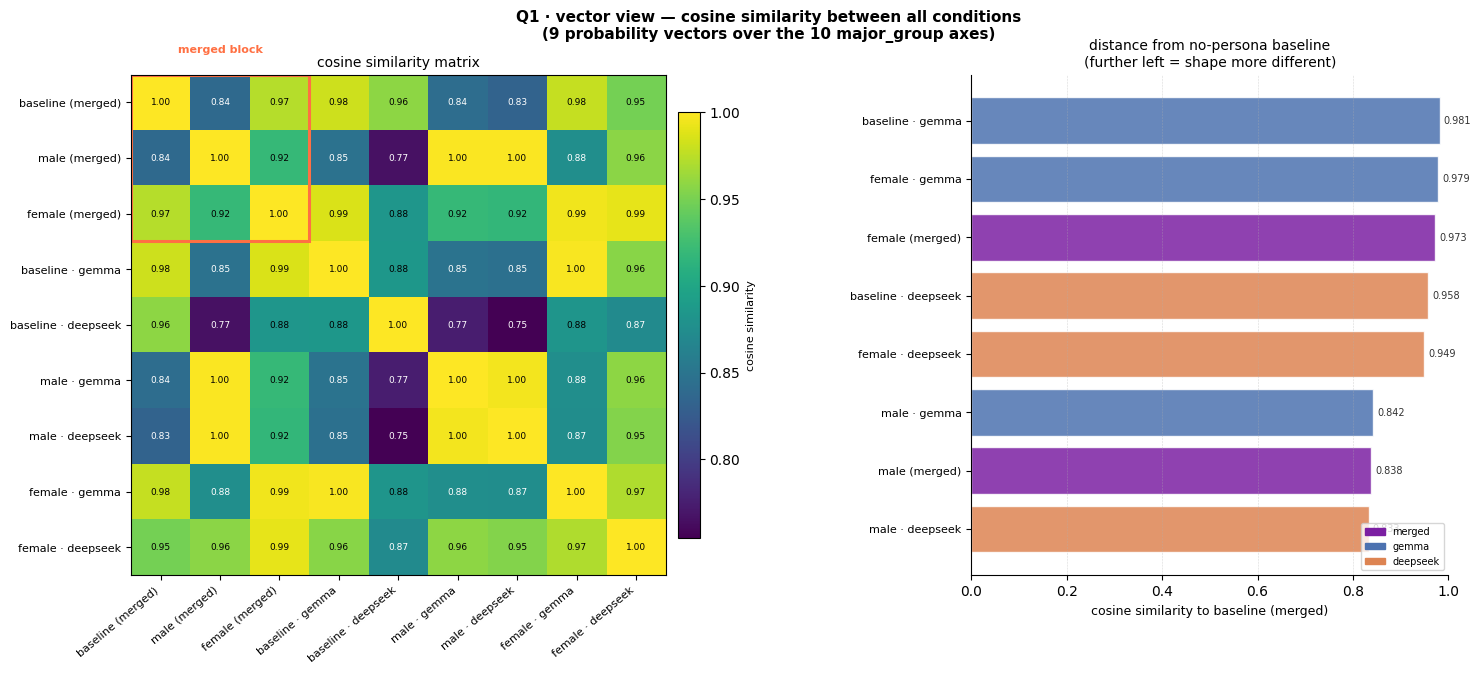

In [ ]:
# ── 13.3  Viz A — cosine-similarity heatmap + baseline-similarity bar ────

import matplotlib.colors as mcolors

cos_M = metric_matrices["cosine sim ↑"]

fig = plt.figure(figsize=(17, 6.5))
gs  = fig.add_gridspec(1, 2, width_ratios=[1.35, 1.0], wspace=0.35)
ax_hm  = fig.add_subplot(gs[0, 0])
ax_bar = fig.add_subplot(gs[0, 1])

fig.suptitle(
    "Q1 · vector view — cosine similarity between all conditions\n"
    "(9 probability vectors over the 10 major_group axes)",
    fontsize=11, fontweight="bold"
)

# ── LEFT: full cosine heatmap ─────────────────────────────────────────────
data = cos_M.values
vmin = np.nanmin(data)
im = ax_hm.imshow(data, cmap="viridis", vmin=vmin, vmax=1.0, aspect="auto")
ax_hm.set_xticks(range(len(keys)))
ax_hm.set_xticklabels(keys, rotation=40, ha="right", fontsize=8)
ax_hm.set_yticks(range(len(keys)))
ax_hm.set_yticklabels(keys, fontsize=8)
ax_hm.set_title("cosine similarity matrix", fontsize=10)

# annotate cells
for i in range(len(keys)):
    for j in range(len(keys)):
        v = data[i, j]
        if np.isnan(v):
            continue
        # contrast text colour with cell luminance
        txt_c = "white" if v < (vmin + 1.0) / 2 else "black"
        ax_hm.text(j, i, f"{v:.2f}", ha="center", va="center", fontsize=6.5, color=txt_c)

# highlight merged 3×3 block with a rectangle
for span_i, span_j in [((0, 3), (0, 3))]:
    ax_hm.add_patch(plt.Rectangle(
        (span_j[0] - 0.5, span_i[0] - 0.5),
        span_j[1] - span_j[0], span_i[1] - span_i[0],
        fill=False, edgecolor="#FF7043", linewidth=2.2
    ))
ax_hm.text(1, -0.9, "merged block", color="#FF7043", fontsize=8, ha="center",
           fontweight="bold")

cbar = fig.colorbar(im, ax=ax_hm, shrink=0.85, pad=0.02)
cbar.set_label("cosine similarity", fontsize=8)

# ── RIGHT: cosine similarity to v_baseline (merged) as horizontal bars ────
sim_to_base = cos_M["baseline (merged)"].drop("baseline (merged)")
# order by similarity ascending — least similar at top for emphasis
sim_to_base = sim_to_base.sort_values()

# colour rule: separate merged / gemma / deepseek
def _bar_colour(name):
    if "gemma" in name:      return "#4C72B0"
    if "deepseek" in name:   return "#DD8452"
    return "#7B1FA2"          # merged

colors = [_bar_colour(n) for n in sim_to_base.index]

y = np.arange(len(sim_to_base))
bars = ax_bar.barh(y, sim_to_base.values, color=colors, alpha=0.85, edgecolor="white")
ax_bar.set_yticks(y)
ax_bar.set_yticklabels(sim_to_base.index, fontsize=8)
ax_bar.set_xlabel("cosine similarity to baseline (merged)", fontsize=9)
ax_bar.set_title("distance from no-persona baseline\n(further left = shape more different)", fontsize=10)
ax_bar.set_xlim(min(0.0, sim_to_base.min() - 0.05), 1.0)
ax_bar.axvline(1.0, color="#888", linestyle="--", linewidth=0.7)
ax_bar.spines["top"].set_visible(False)
ax_bar.spines["right"].set_visible(False)
ax_bar.grid(axis="x", linestyle="--", linewidth=0.4, alpha=0.5)

# value labels
for bar, val in zip(bars, sim_to_base.values):
    ax_bar.text(val + 0.008, bar.get_y() + bar.get_height() / 2,
                f"{val:.3f}", va="center", fontsize=7, color="#333")

# small legend for bar colours
legend_patches = [
    mpatches.Patch(color="#7B1FA2", label="merged"),
    mpatches.Patch(color="#4C72B0", label="gemma"),
    mpatches.Patch(color="#DD8452", label="deepseek"),
]
ax_bar.legend(handles=legend_patches, fontsize=7, loc="lower right")

plt.tight_layout()
fig.savefig(FIGURES_DIR / "q1_gender_vec_cosine_heatmap.png", bbox_inches="tight", dpi=150)
plt.show()
plt.close(fig)

### 13.4 — Viz B: 2D projection of the vectors

The vectors live in 10-D space. To see structure at a glance we project them to 2-D using two complementary approaches:

- **PCA** (left) — project the raw ℝ¹⁰ vectors onto the top 2 principal components. Axes are linear combinations of the original group axes; distances approximate Euclidean distances between vectors.
- **MDS from JSD** (right) — build a 9 × 9 Jensen–Shannon distance matrix, then use classical multidimensional scaling (double-centering trick, no sklearn required) so 2-D distances reflect information-theoretic distances between the distributions.

In both plots we draw arrows from `baseline (merged)` to `male (merged)` and to `female (merged)` — the "persona effect" direction.

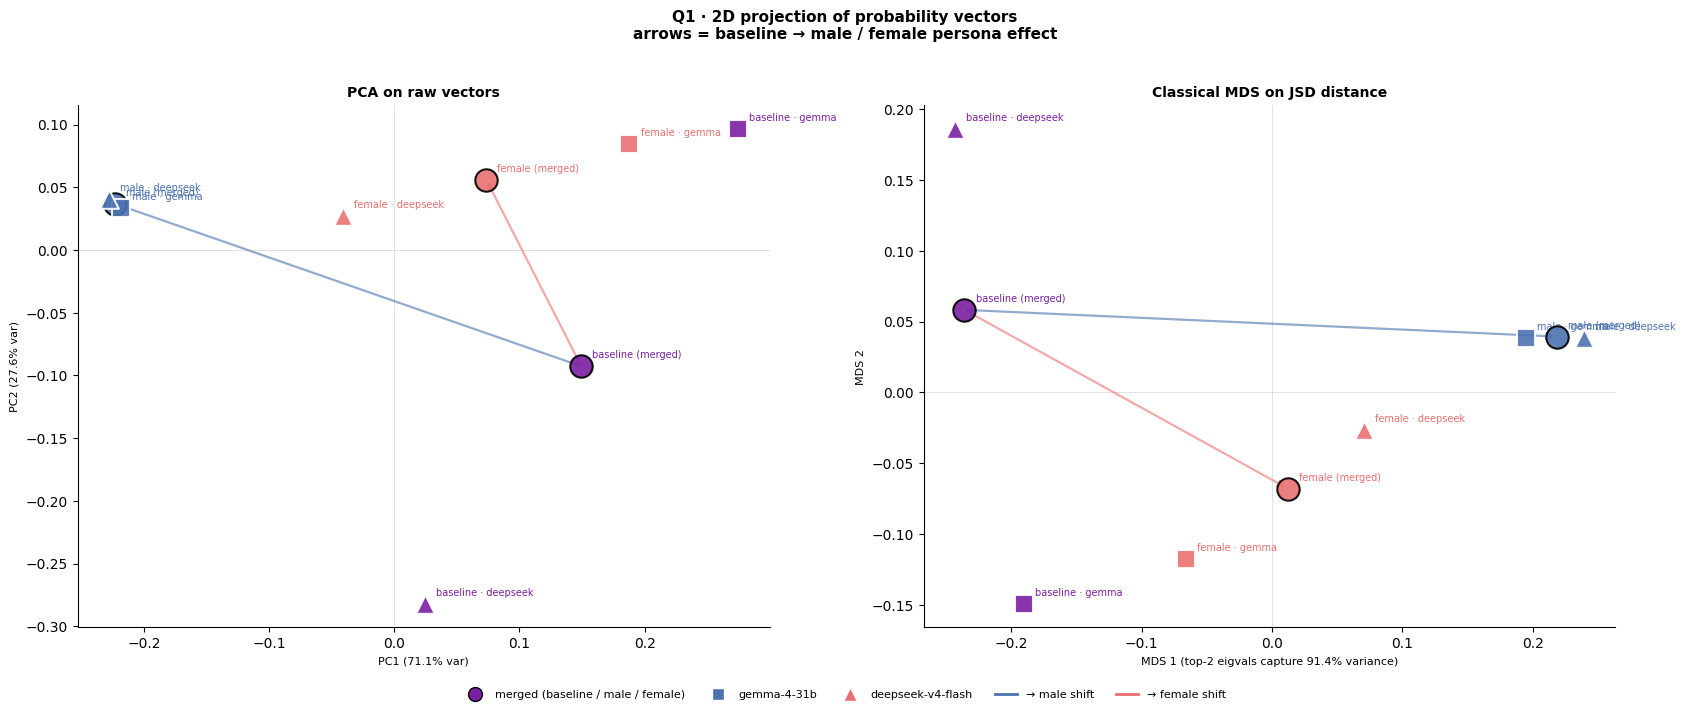

2D coordinates per condition:
                       PC1    PC2   MDS1   MDS2
baseline (merged)   +0.149 -0.093 -0.236 +0.058
male (merged)       -0.223 +0.037 +0.219 +0.039
female (merged)     +0.074 +0.056 +0.012 -0.068
baseline · gemma    +0.275 +0.096 -0.190 -0.149
baseline · deepseek +0.024 -0.282 -0.243 +0.186
male · gemma        -0.218 +0.033 +0.195 +0.039
male · deepseek     -0.228 +0.040 +0.239 +0.039
female · gemma      +0.188 +0.085 -0.066 -0.118
female · deepseek   -0.041 +0.027 +0.070 -0.026

PCA explained variance: PC1 71.1%, PC2 27.6%
MDS top-2 eigenvalues capture 91.4% of positive variance


In [ ]:
# ── 13.4  Viz B — 2D projection via PCA and classical MDS on JSD ─────────
#
# We stay dependency-light: PCA via SVD on centered matrix, MDS via classical
# double-centering trick — no sklearn required.

# stack vectors into (n_conditions, n_groups)
V     = np.stack([Q1_VECTORS[k] for k in keys], axis=0)
n_c   = V.shape[0]

# ── PCA ───────────────────────────────────────────────────────────────────
V_centered      = V - V.mean(axis=0, keepdims=True)
U, S, Vt        = np.linalg.svd(V_centered, full_matrices=False)
pca_coords      = U[:, :2] * S[:2]                          # projected onto PC1/PC2
explained_var   = (S ** 2) / (S ** 2).sum()
pca_var_pct     = explained_var[:2] * 100

# ── Classical MDS from JSD distance matrix ────────────────────────────────
jsd_M = metric_matrices["JSD ↓"].values.astype(float)
# JSD is a proper metric only when we take sqrt(JSD). Use that for MDS.
D  = np.sqrt(np.clip(jsd_M, 0, None))
D2 = D ** 2
n  = D2.shape[0]
J  = np.eye(n) - np.ones((n, n)) / n
B  = -0.5 * J @ D2 @ J
eigvals, eigvecs = np.linalg.eigh(B)
# take top 2 positive eigenvalues
order       = np.argsort(eigvals)[::-1]
eigvals     = eigvals[order]
eigvecs     = eigvecs[:, order]
pos         = np.clip(eigvals[:2], 0, None)
mds_coords  = eigvecs[:, :2] * np.sqrt(pos)
mds_stress_pct = (eigvals[:2].clip(0).sum() / eigvals.clip(0).sum()) * 100

# ── plotting helpers ──────────────────────────────────────────────────────
def _marker_style(name):
    """Return (marker, colour, size, edgecolour) based on condition name."""
    # colour by gender/condition
    if name.startswith("baseline"):
        c = "#7B1FA2"   # purple
    elif name.startswith("male"):
        c = "#4C72B0"   # blue
    elif name.startswith("female"):
        c = "#E97070"   # rose
    else:
        c = "#666666"
    # marker by model (merged/gemma/deepseek)
    if "gemma" in name:
        m, s = "s", 160
    elif "deepseek" in name:
        m, s = "^", 180
    else:
        m, s = "o", 260
    return m, c, s, "black" if "merged" in name else "white"


def _draw_scatter(ax, coords, title, xlabel, ylabel):
    for i, name in enumerate(keys):
        m, c, s, ec = _marker_style(name)
        ax.scatter(coords[i, 0], coords[i, 1], marker=m, color=c, s=s,
                   edgecolor=ec, linewidth=1.5, zorder=5, alpha=0.9)
        ax.annotate(name, (coords[i, 0], coords[i, 1]),
                    textcoords="offset points", xytext=(8, 6),
                    fontsize=7, color=c)

    # arrows: baseline (merged) → male / female (merged)
    idx_base   = keys.index("baseline (merged)")
    idx_male   = keys.index("male (merged)")
    idx_female = keys.index("female (merged)")
    for tgt, col in [(idx_male, "#4C72B0"), (idx_female, "#E97070")]:
        ax.annotate(
            "",
            xy=coords[tgt], xytext=coords[idx_base],
            arrowprops=dict(arrowstyle="->", color=col, lw=1.6, alpha=0.6),
        )

    ax.axhline(0, color="#DDD", linewidth=0.6, zorder=1)
    ax.axvline(0, color="#DDD", linewidth=0.6, zorder=1)
    ax.set_title(title, fontsize=10, fontweight="bold")
    ax.set_xlabel(xlabel, fontsize=8)
    ax.set_ylabel(ylabel, fontsize=8)
    ax.spines["top"].set_visible(False)
    ax.spines["right"].set_visible(False)


fig, axes = plt.subplots(1, 2, figsize=(17, 7))
fig.suptitle(
    "Q1 · 2D projection of probability vectors\n"
    "arrows = baseline → male / female persona effect",
    fontsize=11, fontweight="bold"
)

_draw_scatter(
    axes[0], pca_coords, "PCA on raw vectors",
    f"PC1 ({pca_var_pct[0]:.1f}% var)",
    f"PC2 ({pca_var_pct[1]:.1f}% var)",
)
_draw_scatter(
    axes[1], mds_coords, "Classical MDS on JSD distance",
    f"MDS 1 (top-2 eigvals capture {mds_stress_pct:.1f}% variance)",
    "MDS 2",
)

# global legend
legend_handles = [
    plt.Line2D([], [], marker="o", color="#7B1FA2", markersize=10,
               markeredgecolor="black", linestyle="", label="merged (baseline / male / female)"),
    plt.Line2D([], [], marker="s", color="#4C72B0", markersize=9,
               markeredgecolor="white", linestyle="", label="gemma-4-31b"),
    plt.Line2D([], [], marker="^", color="#E97070", markersize=10,
               markeredgecolor="white", linestyle="", label="deepseek-v4-flash"),
    plt.Line2D([], [], color="#4C72B0", lw=2, label="→ male shift"),
    plt.Line2D([], [], color="#E97070", lw=2, label="→ female shift"),
]
fig.legend(handles=legend_handles, loc="lower center", ncol=5, fontsize=8,
           frameon=False, bbox_to_anchor=(0.5, -0.02))

plt.tight_layout(rect=[0, 0.02, 1, 0.96])
fig.savefig(FIGURES_DIR / "q1_gender_vec_2d_projection.png", bbox_inches="tight", dpi=150)
plt.show()
plt.close(fig)

# ── print the coordinates for reference ───────────────────────────────────
proj_df = pd.DataFrame({
    "PC1": pca_coords[:, 0], "PC2": pca_coords[:, 1],
    "MDS1": mds_coords[:, 0], "MDS2": mds_coords[:, 1],
}, index=keys)
print("2D coordinates per condition:")
print(proj_df.to_string(float_format="{:+.3f}".format))
print(f"\nPCA explained variance: PC1 {pca_var_pct[0]:.1f}%, PC2 {pca_var_pct[1]:.1f}%")
print(f"MDS top-2 eigenvalues capture {mds_stress_pct:.1f}% of positive variance")

### 13.5 — Viz C: polar overlay of the three merged vectors

Each vector as a polygon on a polar chart with 10 axes = the 10 major_groups. Overlaying baseline / male / female makes shape differences visible: axes where the polygons diverge = where persona-of-that-gender pushes the model.

- Left panel — polygon per condition (baseline / Male / Female), radial value = **probability**
- Right panel — same layout but radial value = **deviation from baseline** (Male − Base, Female − Base) with a shared 0-circle

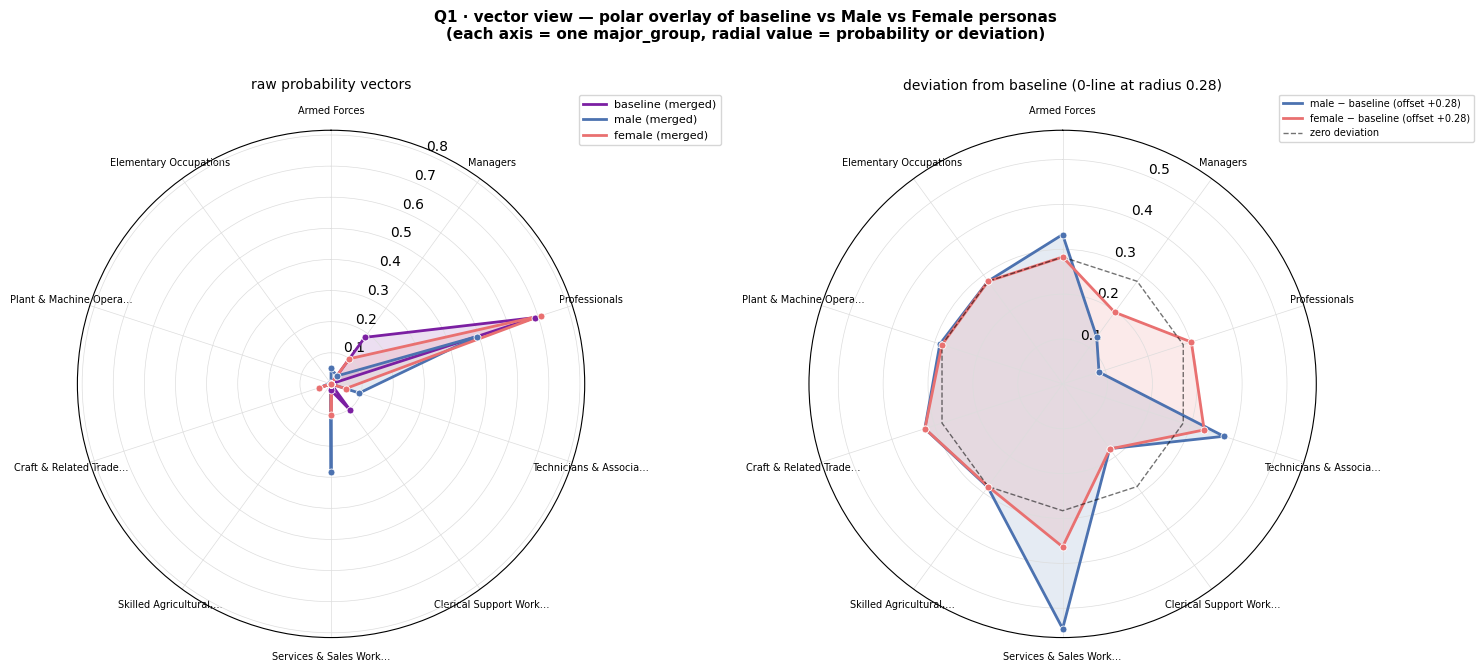

In [ ]:
# ── 13.5  Viz C — polar overlay of baseline / Male / Female ──────────────

BASE_C   = "#7B1FA2"
MALE_C   = "#4C72B0"
FEMALE_C = "#E97070"

# short axis labels — polar charts get cramped with the full names
def _short(lbl, max_len=22):
    return lbl if len(lbl) <= max_len else lbl[: max_len - 1] + "…"

axis_labels  = [_short(l) for l in Q1_LEVELS]
n_axes       = len(Q1_LEVELS)
angles       = np.linspace(0, 2 * np.pi, n_axes, endpoint=False).tolist()
angles_close = angles + [angles[0]]


def _polygon(ax, vec, color, label):
    v = list(vec) + [vec[0]]
    ax.plot(angles_close, v, color=color, lw=2.0, label=label)
    ax.fill(angles_close, v, color=color, alpha=0.14)
    # dot markers
    ax.scatter(angles, vec, color=color, s=25, zorder=5, edgecolor="white", linewidth=0.6)


fig, axes = plt.subplots(1, 2, figsize=(15, 7), subplot_kw={"polar": True})
fig.suptitle(
    "Q1 · vector view — polar overlay of baseline vs Male vs Female personas\n"
    "(each axis = one major_group, radial value = probability or deviation)",
    fontsize=11, fontweight="bold"
)

# ── LEFT: raw probability polygons ────────────────────────────────────────
ax = axes[0]
ax.set_theta_offset(np.pi / 2)
ax.set_theta_direction(-1)
ax.set_thetagrids(np.degrees(angles), axis_labels, fontsize=7)

_polygon(ax, v_baseline, BASE_C,   "baseline (merged)")
_polygon(ax, v_male,     MALE_C,   "male (merged)")
_polygon(ax, v_female,   FEMALE_C, "female (merged)")

ax.set_ylim(0, max(v_baseline.max(), v_male.max(), v_female.max()) * 1.15)
ax.set_title("raw probability vectors", fontsize=10, pad=12)
ax.legend(fontsize=8, loc="upper right", bbox_to_anchor=(1.28, 1.08))
ax.grid(linewidth=0.5, color="#DDD")

# ── RIGHT: deviation from baseline ────────────────────────────────────────
ax2 = axes[1]
ax2.set_theta_offset(np.pi / 2)
ax2.set_theta_direction(-1)
ax2.set_thetagrids(np.degrees(angles), axis_labels, fontsize=7)

dev_m = v_male   - v_baseline
dev_f = v_female - v_baseline

# radar cannot show negative radii — shift by offset then annotate 0-circle
offset = max(abs(dev_m).max(), abs(dev_f).max()) + 0.02
_polygon(ax2, dev_m + offset, MALE_C,   f"male − baseline (offset +{offset:.2f})")
_polygon(ax2, dev_f + offset, FEMALE_C, f"female − baseline (offset +{offset:.2f})")

# 0-circle
zero_r = [offset] * len(angles_close)
ax2.plot(angles_close, zero_r, color="black", lw=1.0, linestyle="--", alpha=0.55, label="zero deviation")

ax2.set_ylim(0, offset + max(abs(dev_m).max(), abs(dev_f).max()) + 0.02)
ax2.set_title(f"deviation from baseline (0-line at radius {offset:.2f})", fontsize=10, pad=12)
ax2.legend(fontsize=7, loc="upper right", bbox_to_anchor=(1.32, 1.08))
ax2.grid(linewidth=0.5, color="#DDD")

plt.tight_layout()
fig.savefig(FIGURES_DIR / "q1_gender_vec_polar_overlay.png", bbox_inches="tight", dpi=150)
plt.show()
plt.close(fig)

### 13.6 — Viz D: vector arrow decomposition

Focus purely on the **shift vectors** rather than the raw distributions:

- **Δmale** = `v_male − v_baseline`
- **Δfemale** = `v_female − v_baseline`
- **Δgap** = `v_female − v_male` (how differently the two personas move things)

We visualise three ways:

1. **Grouped bars per axis** — shows Δmale and Δfemale side-by-side, with Δgap as a line, so you can see per-group where the gender shifts agree vs diverge.
2. **Shift-magnitude / direction summary** — for each shift vector we report ‖Δ‖₁ (total moved probability mass), ‖Δ‖₂, and the cosine similarity between Δmale and Δfemale (are the two shifts pointing the same way in ℝ¹⁰?).
3. **Cumulative stacked view** — start from baseline bars and stack Δmale / Δfemale on top so the final `v_male` and `v_female` bars appear next to `v_baseline`, colour-coded by the sign of the shift.

Shift-vector summary:
                                 ‖Δ‖₁ (TV × 2)   ‖Δ‖₂  max |Δ|  cos(Δ_this, Δ_other)
Δmale   (v_male − v_baseline)           0.9102 0.3945   0.2627                0.7099
Δfemale (v_female − v_baseline)         0.3774 0.1697   0.1034                0.7099
Δgap    (v_female − v_male)             0.5708 0.2989   0.2165                   NaN



/var/folders/bq/hdtlcyk572l9dklh54vxrpg80000gn/T/ipykernel_35752/3171961536.py:148: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout(rect=[0, 0, 1, 0.94])


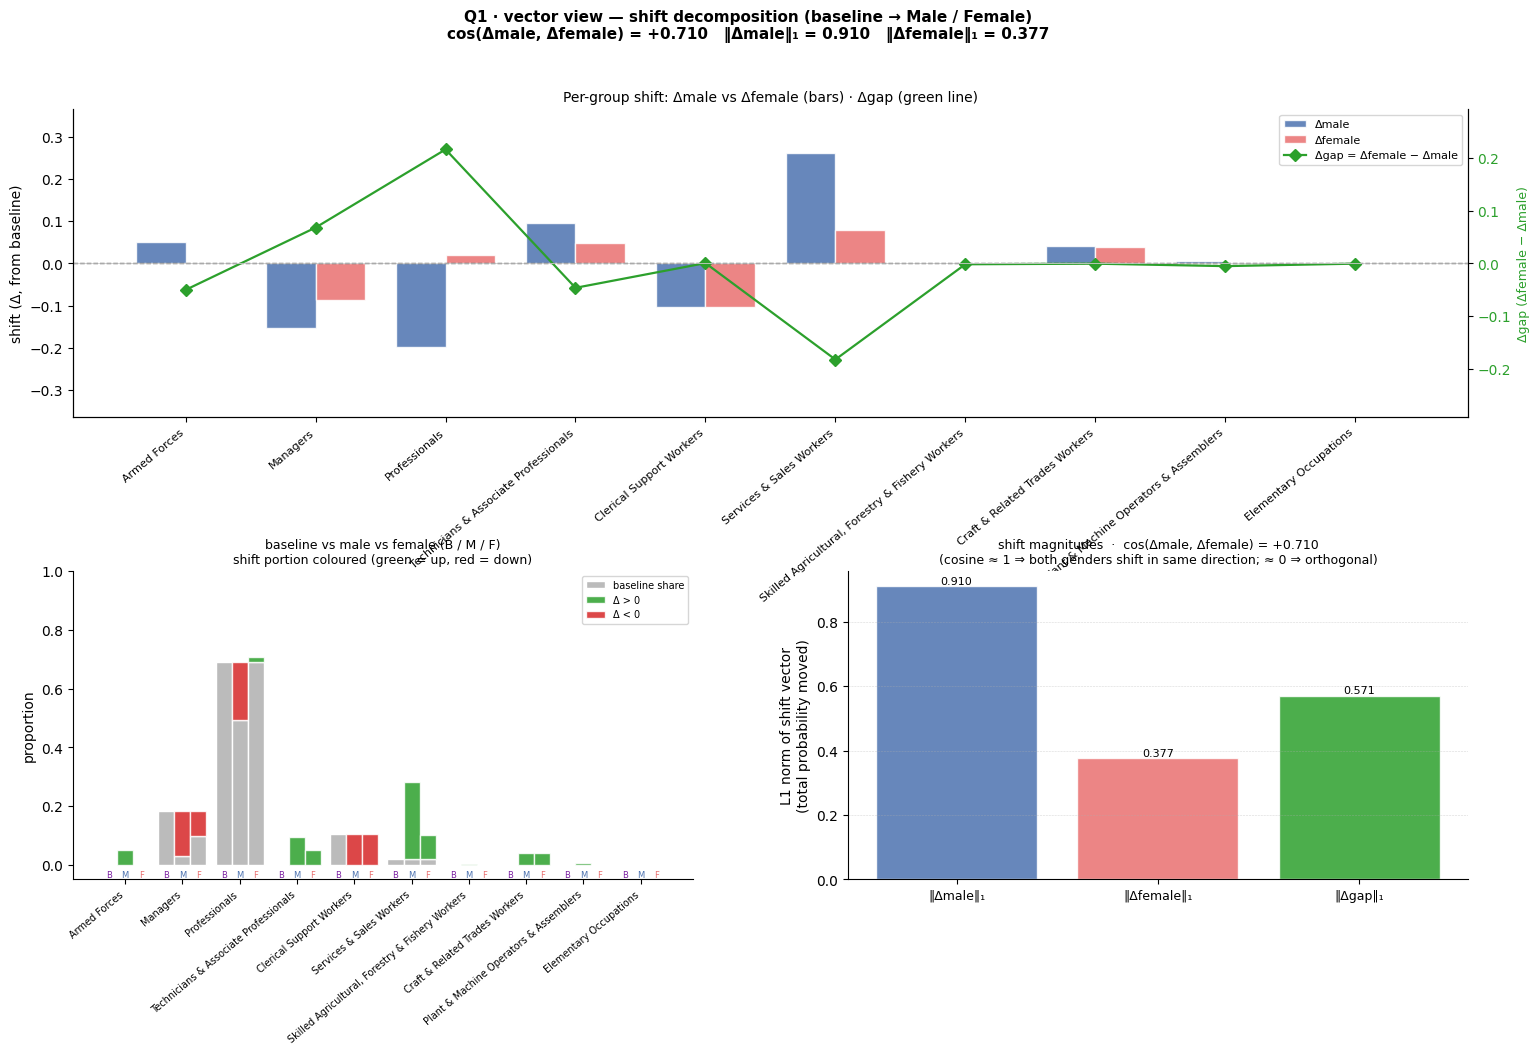

In [ ]:
# ── 13.6  Viz D — vector arrow / shift decomposition ─────────────────────

delta_male   = v_male   - v_baseline
delta_female = v_female - v_baseline
delta_gap    = v_female - v_male

# ── Compact numeric summary of the shift vectors ──────────────────────────
def _mag_row(name, d, ref_pair=None):
    row = {
        "‖Δ‖₁ (TV × 2)": _l1(d, np.zeros_like(d)),
        "‖Δ‖₂":          _l2(d, np.zeros_like(d)),
        "max |Δ|":       float(np.max(np.abs(d))),
    }
    if ref_pair is not None:
        a, b = ref_pair
        row["cos(Δ_this, Δ_other)"] = _cosine(a, b)
    return pd.Series(row, name=name)


shift_summary = pd.DataFrame([
    _mag_row("Δmale   (v_male − v_baseline)",   delta_male,   ref_pair=(delta_male,   delta_female)),
    _mag_row("Δfemale (v_female − v_baseline)", delta_female, ref_pair=(delta_female, delta_male)),
    _mag_row("Δgap    (v_female − v_male)",     delta_gap),
])
print("Shift-vector summary:")
print(shift_summary.to_string(float_format="{:.4f}".format))
print()

# ── Combined figure: 3 panels ─────────────────────────────────────────────
fig = plt.figure(figsize=(18, 10))
gs  = fig.add_gridspec(2, 2, height_ratios=[1.0, 1.0], hspace=0.5, wspace=0.25)
ax_bars   = fig.add_subplot(gs[0, :])   # full-width per-axis Δmale/Δfemale bars
ax_stack  = fig.add_subplot(gs[1, 0])   # baseline + shift-stack view
ax_summary= fig.add_subplot(gs[1, 1])   # magnitude / cosine summary

fig.suptitle(
    "Q1 · vector view — shift decomposition (baseline → Male / Female)\n"
    f"cos(Δmale, Δfemale) = {_cosine(delta_male, delta_female):+.3f}   "
    f"‖Δmale‖₁ = {_l1(delta_male, np.zeros_like(delta_male)):.3f}   "
    f"‖Δfemale‖₁ = {_l1(delta_female, np.zeros_like(delta_female)):.3f}",
    fontsize=11, fontweight="bold"
)

# ── PANEL 1: per-axis Δmale vs Δfemale grouped bars + Δgap line ──────────
n     = len(Q1_LEVELS)
x     = np.arange(n)
bar_w = 0.38

ax_bars.bar(x - bar_w / 2, delta_male,   bar_w,
            color=MALE_C,   alpha=0.85, edgecolor="white", label="Δmale")
ax_bars.bar(x + bar_w / 2, delta_female, bar_w,
            color=FEMALE_C, alpha=0.85, edgecolor="white", label="Δfemale")
ax_bars.axhline(0, color="black", linewidth=0.9, linestyle="--")

ax2 = ax_bars.twinx()
ax2.plot(x, delta_gap, color="#2CA02C", marker="D", lw=1.6,
         label="Δgap = Δfemale − Δmale")
ax2.axhline(0, color="#CCC", linewidth=0.6)
ax2.set_ylabel("Δgap (Δfemale − Δmale)", color="#2CA02C", fontsize=9)
ax2.tick_params(axis="y", labelcolor="#2CA02C")
# sync 0-lines so both zeros align visually
lim1 = max(abs(delta_male).max(), abs(delta_female).max()) * 1.35 + 0.01
lim2 = max(abs(delta_gap).max(), 0.02) * 1.35
ax_bars.set_ylim(-lim1, lim1)
ax2.set_ylim(-lim2, lim2)

ax_bars.set_xticks(x)
ax_bars.set_xticklabels(Q1_LEVELS, rotation=40, ha="right", fontsize=8)
ax_bars.set_ylabel("shift (Δ, from baseline)")
ax_bars.set_title("Per-group shift: Δmale vs Δfemale (bars) · Δgap (green line)",
                  fontsize=10)
ax_bars.spines["top"].set_visible(False)
ax2.spines["top"].set_visible(False)

# combined legend
h1, l1 = ax_bars.get_legend_handles_labels()
h2, l2 = ax2.get_legend_handles_labels()
ax_bars.legend(h1 + h2, l1 + l2, fontsize=8, loc="upper right")

# ── PANEL 2: baseline + shift-stack ("waterfall" style) ──────────────────
# For each group axis, draw three thin bars side by side:
#   baseline  ▮  →  male final ▮  →  female final ▮
# and colour the shift portion (green up, red down).

sub_w = 0.28
offsets = [-sub_w, 0.0, +sub_w]
labels_top = ["baseline", "male", "female"]
vec_stack  = [v_baseline, v_male, v_female]

for i, (off, vec, lbl) in enumerate(zip(offsets, vec_stack, labels_top)):
    # base bar (baseline proportion)
    ax_stack.bar(x + off, np.minimum(v_baseline, vec), sub_w,
                 color="#BBB", edgecolor="white", label="baseline share" if i == 0 else None)
    # shift on top (positive) or subtracted (negative)
    shift = vec - v_baseline
    up_mask   = shift >  0
    down_mask = shift <  0
    ax_stack.bar(x[up_mask]   + off, shift[up_mask],
                 sub_w, bottom=v_baseline[up_mask],
                 color="#2CA02C", alpha=0.85, edgecolor="white",
                 label="Δ > 0" if i == 1 else None)
    ax_stack.bar(x[down_mask] + off, shift[down_mask],
                 sub_w, bottom=v_baseline[down_mask],
                 color="#D62728", alpha=0.85, edgecolor="white",
                 label="Δ < 0" if i == 1 else None)

# invisible "column label" markers under each triplet
for i in range(n):
    for off, lbl, colr in zip(offsets, labels_top, [BASE_C, MALE_C, FEMALE_C]):
        ax_stack.text(i + off, -0.02, lbl[0].upper(),
                      ha="center", va="top", fontsize=6, color=colr)

ax_stack.set_xticks(x)
ax_stack.set_xticklabels(Q1_LEVELS, rotation=40, ha="right", fontsize=7)
ax_stack.set_ylabel("proportion")
ax_stack.set_title("baseline vs male vs female (B / M / F)\nshift portion coloured (green = up, red = down)", fontsize=9)
ax_stack.set_ylim(-0.05, 1.0)
ax_stack.legend(fontsize=7, loc="upper right")
ax_stack.spines["top"].set_visible(False)
ax_stack.spines["right"].set_visible(False)

# ── PANEL 3: shift-vector magnitude / direction summary bar ──────────────
labels_s = ["‖Δmale‖₁", "‖Δfemale‖₁", "‖Δgap‖₁"]
values_s = [
    _l1(delta_male,   np.zeros_like(delta_male)),
    _l1(delta_female, np.zeros_like(delta_female)),
    _l1(delta_gap,    np.zeros_like(delta_gap)),
]
colors_s = [MALE_C, FEMALE_C, "#2CA02C"]

xs = np.arange(len(labels_s))
bars = ax_summary.bar(xs, values_s, color=colors_s, alpha=0.85, edgecolor="white")
for bar, v in zip(bars, values_s):
    ax_summary.text(bar.get_x() + bar.get_width() / 2, v + 0.005,
                    f"{v:.3f}", ha="center", fontsize=8)
ax_summary.set_xticks(xs)
ax_summary.set_xticklabels(labels_s, fontsize=9)
ax_summary.set_ylabel("L1 norm of shift vector\n(total probability moved)")
ax_summary.set_title(
    f"shift magnitudes  ·  cos(Δmale, Δfemale) = {_cosine(delta_male, delta_female):+.3f}\n"
    "(cosine ≈ 1 ⇒ both genders shift in same direction; ≈ 0 ⇒ orthogonal)",
    fontsize=9
)
ax_summary.spines["top"].set_visible(False)
ax_summary.spines["right"].set_visible(False)
ax_summary.grid(axis="y", linestyle="--", linewidth=0.4, alpha=0.5)

plt.tight_layout(rect=[0, 0, 1, 0.94])
fig.savefig(FIGURES_DIR / "q1_gender_vec_shift_decomposition.png", bbox_inches="tight", dpi=150)
plt.show()
plt.close(fig)

### 13.7 — Viz E: "look, they're the same" — female overlaid on baseline

The metrics say `cos(v_baseline, v_female) = 0.973` and `‖v_female − v_baseline‖₁ = 0.377`, vs `cos(v_baseline, v_male) = 0.838` and `‖v_male − v_baseline‖₁ = 0.910`.

This figure makes that visually obvious.

- **Top panel** — the three vectors as thin lines over the 10 group axes. `v_female` (rose) hugs `v_baseline` (grey) almost everywhere; `v_male` (blue) departs.
- **Bottom-left** — `v_female` overlaid directly on `v_baseline` with the residual `v_female − v_baseline` drawn as a faint band. Small band ⇒ near-identity.
- **Bottom-right** — same layout for `v_male` on `v_baseline`. The band is much bigger.

/var/folders/bq/hdtlcyk572l9dklh54vxrpg80000gn/T/ipykernel_35752/3552556889.py:108: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout(rect=[0, 0, 1, 0.94])


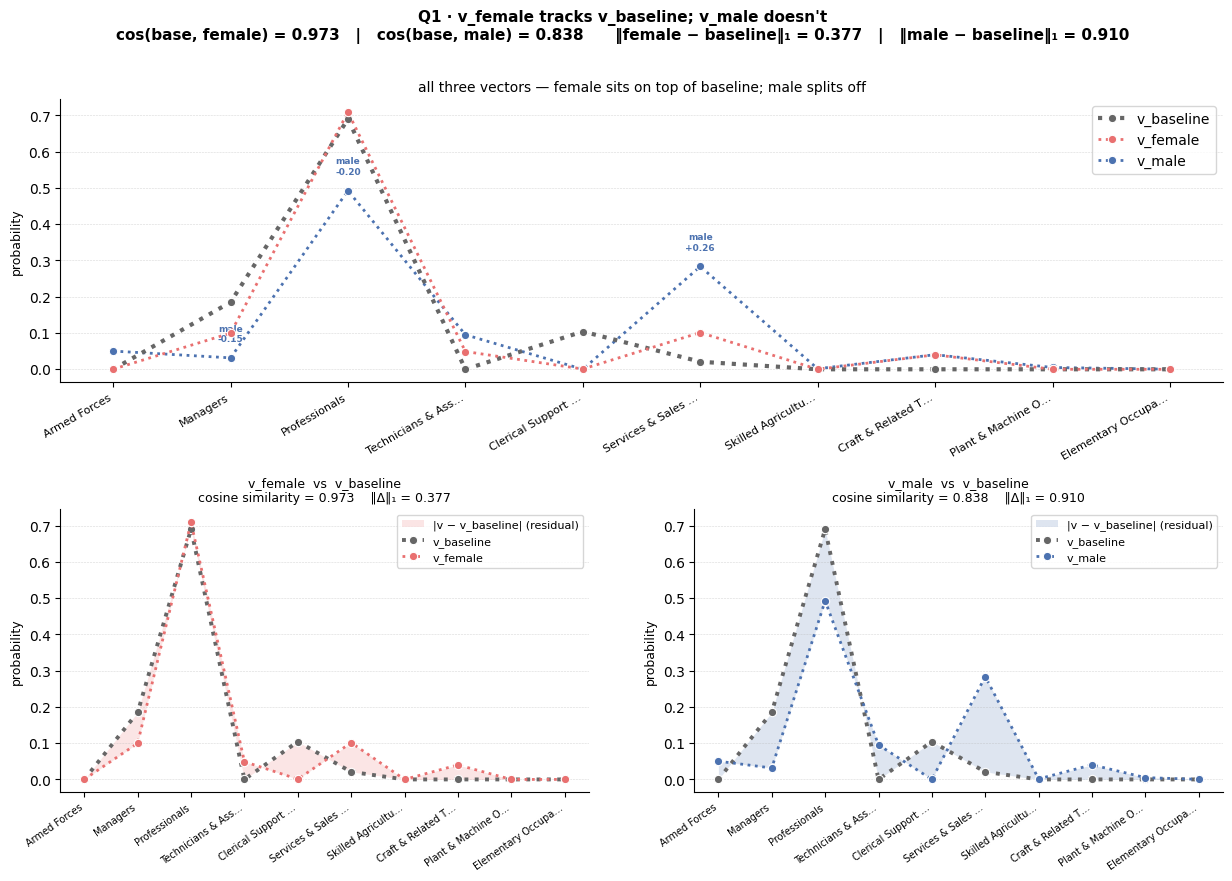

In [ ]:
# ── 13.7  Viz E — female overlaid on baseline (visual proof of similarity) ─

BASE_C   = "#666666"   # grey — anchor
MALE_C   = "#4C72B0"
FEMALE_C = "#E97070"

# short axis labels
def _short2(lbl, n=18):
    return lbl if len(lbl) <= n else lbl[: n - 1] + "…"

labels_short = [_short2(l) for l in Q1_LEVELS]
xi = np.arange(len(Q1_LEVELS))

# compute headline metrics for the title
cos_bf = _cosine(v_baseline, v_female)
cos_bm = _cosine(v_baseline, v_male)
l1_bf  = _l1(v_baseline, v_female)
l1_bm  = _l1(v_baseline, v_male)

fig = plt.figure(figsize=(15, 9))
gs  = fig.add_gridspec(2, 2, height_ratios=[1.0, 1.0], hspace=0.45, wspace=0.2)
ax_top   = fig.add_subplot(gs[0, :])
ax_fem   = fig.add_subplot(gs[1, 0])
ax_male  = fig.add_subplot(gs[1, 1], sharey=ax_fem)

fig.suptitle(
    "Q1 · v_female tracks v_baseline; v_male doesn't\n"
    f"cos(base, female) = {cos_bf:.3f}   |   cos(base, male) = {cos_bm:.3f}      "
    f"‖female − baseline‖₁ = {l1_bf:.3f}   |   ‖male − baseline‖₁ = {l1_bm:.3f}",
    fontsize=11, fontweight="bold"
)

# ── TOP: all three vectors as connected lines ─────────────────────────────
def _line(ax, v, c, lbl, lw=2.2, alpha=1.0, marker="o", zorder=3):
    ax.plot(xi, v, color=c, lw=lw, alpha=alpha, linestyle=":", marker=marker,
            markersize=6, markeredgecolor="white", markeredgewidth=0.8,
            label=lbl, zorder=zorder)

_line(ax_top, v_baseline, BASE_C,   "v_baseline",  lw=3.0, zorder=4)
_line(ax_top, v_female,   FEMALE_C, "v_female",    lw=2.0, zorder=5)
_line(ax_top, v_male,     MALE_C,   "v_male",      lw=2.0, zorder=3)

ax_top.set_xticks(xi)
ax_top.set_xticklabels(labels_short, rotation=30, ha="right", fontsize=8)
ax_top.set_ylabel("probability", fontsize=9)
ax_top.set_title("all three vectors — female sits on top of baseline; male splits off",
                 fontsize=10)
ax_top.grid(axis="y", linestyle="--", linewidth=0.4, alpha=0.5)
ax_top.spines["top"].set_visible(False)
ax_top.spines["right"].set_visible(False)
ax_top.legend(fontsize=10, loc="upper right")

# annotate where they diverge most
for i, (lbl, dm, df_) in enumerate(zip(
    Q1_LEVELS, v_male - v_baseline, v_female - v_baseline
)):
    if abs(dm) > 0.14:
        ax_top.annotate(
            f"male\n{dm:+.2f}", xy=(xi[i], v_male[i]),
            xytext=(0, 12), textcoords="offset points",
            ha="center", fontsize=6.5, color=MALE_C, fontweight="bold"
        )


# ── shared helper for bottom panels: overlay + residual band ──────────────
def _overlay_panel(ax, v_top, top_c, top_lbl, cos_val, l1_val):
    # residual band between baseline and this vector
    ax.fill_between(xi, v_baseline, v_top,
                    color=top_c, alpha=0.18, linewidth=0,
                    label=f"|v − v_baseline| (residual)")
    _line(ax, v_baseline, BASE_C, "v_baseline", lw=2.8, zorder=4)
    _line(ax, v_top,      top_c,  top_lbl,      lw=2.0, zorder=5)

    ax.set_xticks(xi)
    ax.set_xticklabels(labels_short, rotation=35, ha="right", fontsize=7)
    ax.set_ylabel("probability", fontsize=9)
    ax.set_title(
        f"{top_lbl}  vs  v_baseline\n"
        f"cosine similarity = {cos_val:.3f}    ‖Δ‖₁ = {l1_val:.3f}",
        fontsize=9
    )
    ax.grid(axis="y", linestyle="--", linewidth=0.4, alpha=0.5)
    ax.spines["top"].set_visible(False)
    ax.spines["right"].set_visible(False)
    ax.legend(fontsize=8, loc="upper right")

_overlay_panel(ax_fem,  v_female, FEMALE_C, "v_female", cos_bf, l1_bf)
_overlay_panel(ax_male, v_male,   MALE_C,   "v_male",   cos_bm, l1_bm)

# small text callout on female panel
# ax_fem.text(
#     0.02, 0.85,
#     "band is thin →\nfemale ≈ baseline",
#     transform=ax_fem.transAxes,
#     fontsize=9, color=FEMALE_C, fontweight="bold",
#     va="top",
#     bbox=dict(boxstyle="round,pad=0.3", fc="white", ec=FEMALE_C, lw=1),
# )
# ax_male.text(
#     0.02, 0.85,
#     "band is fat →\nmale departs from baseline",
#     transform=ax_male.transAxes,
#     fontsize=9, color=MALE_C, fontweight="bold",
#     va="top",
#     bbox=dict(boxstyle="round,pad=0.3", fc="white", ec=MALE_C, lw=1),
# )

plt.tight_layout(rect=[0, 0, 1, 0.94])
fig.savefig(FIGURES_DIR / "q1_gender_vec_female_tracks_baseline.png",
            bbox_inches="tight", dpi=150)
plt.show()
plt.close(fig)

/var/folders/bq/hdtlcyk572l9dklh54vxrpg80000gn/T/ipykernel_35752/1295932110.py:59: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout(rect=[0, 0, 1, 0.94])
/var/folders/bq/hdtlcyk572l9dklh54vxrpg80000gn/T/ipykernel_35752/3787743250.py:2: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


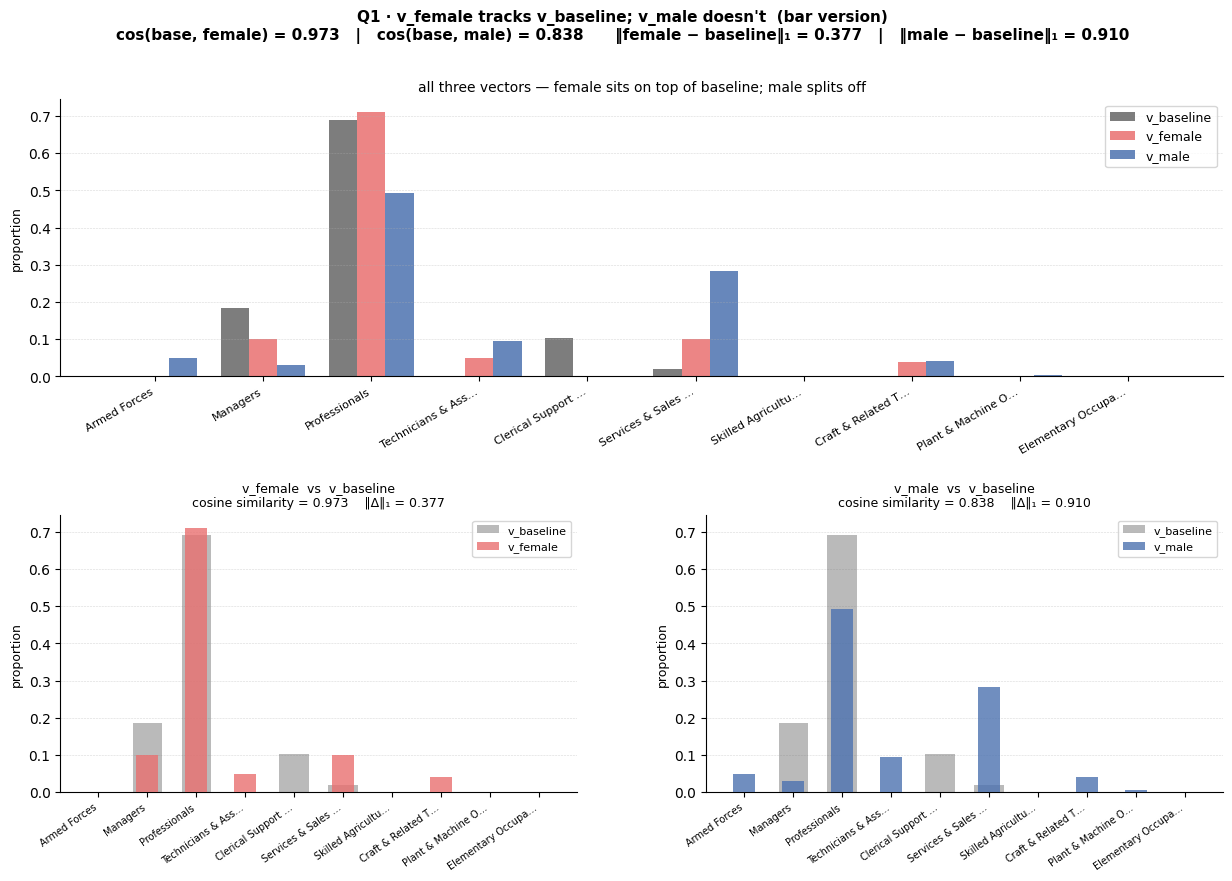

In [ ]:
# ── 13.8  Viz E (bar version) — same layout as 13.7 but with bars ──────────
# Top: grouped bars (baseline / female / male) per category
# Bottom-left: baseline vs female overlapping bars + residual visible
# Bottom-right: baseline vs male overlapping bars + residual visible

fig = plt.figure(figsize=(15, 9))
gs  = fig.add_gridspec(2, 2, height_ratios=[1.0, 1.0], hspace=0.5, wspace=0.25)
ax_top  = fig.add_subplot(gs[0, :])
ax_fem  = fig.add_subplot(gs[1, 0])
ax_male = fig.add_subplot(gs[1, 1], sharey=ax_fem)

fig.suptitle(
    "Q1 · v_female tracks v_baseline; v_male doesn't  (bar version)\n"
    f"cos(base, female) = {cos_bf:.3f}   |   cos(base, male) = {cos_bm:.3f}      "
    f"‖female − baseline‖₁ = {l1_bf:.3f}   |   ‖male − baseline‖₁ = {l1_bm:.3f}",
    fontsize=11, fontweight="bold"
)

w = 0.26   # individual bar width for grouped chart
xi = np.arange(len(Q1_LEVELS))

# ── TOP: grouped bars ─────────────────────────────────────────────────────
ax_top.bar(xi - w, v_baseline, width=w, color=BASE_C,   alpha=0.85, label="v_baseline")
ax_top.bar(xi,     v_female,   width=w, color=FEMALE_C, alpha=0.85, label="v_female")
ax_top.bar(xi + w, v_male,     width=w, color=MALE_C,   alpha=0.85, label="v_male")

ax_top.set_xticks(xi)
ax_top.set_xticklabels(labels_short, rotation=30, ha="right", fontsize=8)
ax_top.set_ylabel("proportion", fontsize=9)
ax_top.set_title("all three vectors — female sits on top of baseline; male splits off", fontsize=10)
ax_top.grid(axis="y", linestyle="--", linewidth=0.4, alpha=0.5)
ax_top.spines["top"].set_visible(False)
ax_top.spines["right"].set_visible(False)
ax_top.legend(fontsize=9, loc="upper right")

# ── BOTTOM helper: overlapping bars, baseline behind, comparison in front ─
def _bar_panel(ax, v_top, top_c, top_lbl, cos_val, l1_val):
    # baseline as full-width background bar
    ax.bar(xi, v_baseline, width=0.6, color=BASE_C,  alpha=0.45, label="v_baseline", zorder=2)
    # comparison bar on top, slightly narrower so baseline edge shows through
    ax.bar(xi, v_top,      width=0.45, color=top_c,  alpha=0.80, label=top_lbl,      zorder=3)

    ax.set_xticks(xi)
    ax.set_xticklabels(labels_short, rotation=35, ha="right", fontsize=7)
    ax.set_ylabel("proportion", fontsize=9)
    ax.set_title(
        f"{top_lbl}  vs  v_baseline\n"
        f"cosine similarity = {cos_val:.3f}    ‖Δ‖₁ = {l1_val:.3f}",
        fontsize=9
    )
    ax.grid(axis="y", linestyle="--", linewidth=0.4, alpha=0.5)
    ax.spines["top"].set_visible(False)
    ax.spines["right"].set_visible(False)
    ax.legend(fontsize=8, loc="upper right")

_bar_panel(ax_fem,  v_female, FEMALE_C, "v_female", cos_bf, l1_bf)
_bar_panel(ax_male, v_male,   MALE_C,   "v_male",   cos_bm, l1_bm)

plt.tight_layout(rect=[0, 0, 1, 0.94])
_save(fig, FIGURES_DIR / "q1_gender_vec_female_tracks_baseline_bars.png")


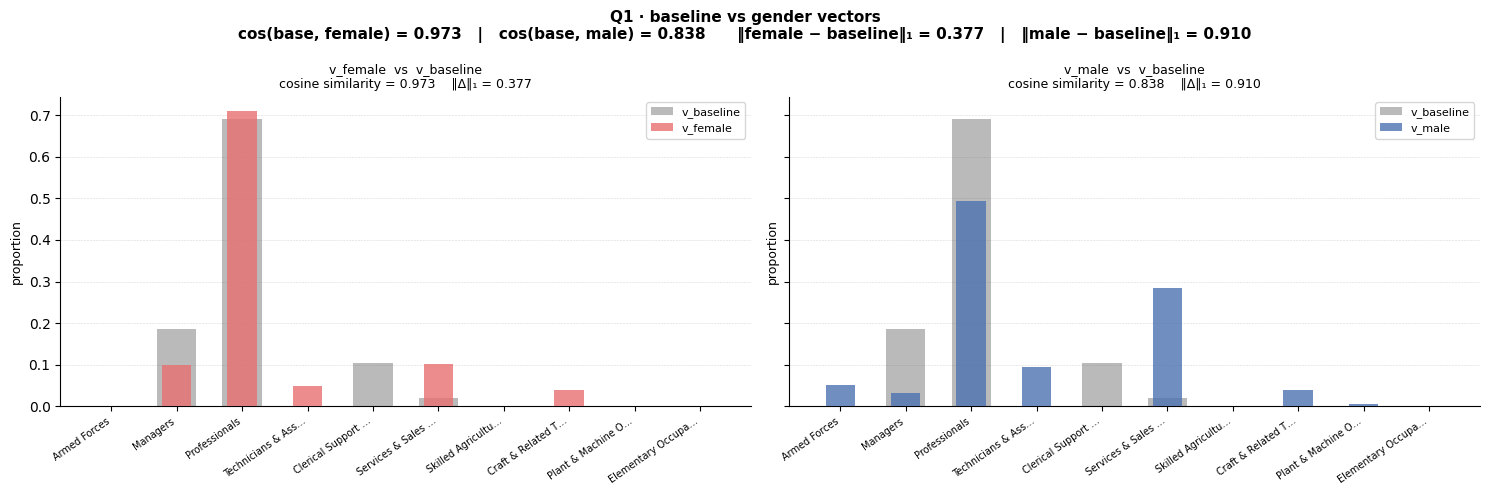

In [ ]:
# ── 13.9  Viz E — bottom panels only (overlapping bars, no grouped top) ───
fig, (ax_fem, ax_male) = plt.subplots(1, 2, figsize=(15, 5), sharey=True)

fig.suptitle(
    "Q1 · baseline vs gender vectors\n"
    f"cos(base, female) = {cos_bf:.3f}   |   cos(base, male) = {cos_bm:.3f}      "
    f"‖female − baseline‖₁ = {l1_bf:.3f}   |   ‖male − baseline‖₁ = {l1_bm:.3f}",
    fontsize=11, fontweight="bold"
)

_bar_panel(ax_fem,  v_female, FEMALE_C, "v_female", cos_bf, l1_bf)
_bar_panel(ax_male, v_male,   MALE_C,   "v_male",   cos_bm, l1_bm)

plt.tight_layout(rect=[0, 0, 1, 0.93])
_save(fig, FIGURES_DIR / "q1_gender_vec_overlay_bars.png")


### 13.8 — Viz F: the three vectors in an actual 2D vector space

Each condition is a point in ℝ¹⁰. We project down to 2-D so the Euclidean distance in the picture is a faithful proxy for the real distance between the distributions, and we plot **only the three merged vectors** so the geometry is uncluttered.

Three panels:

- **Left — PCA (raw ℝ¹⁰)**: arrows from the origin to each vector, plus dashed connectors between them so you can see that `v_female` sits close to `v_baseline` while `v_male` is far.
- **Middle — MDS on √JSD**: same three points, but distances now reflect the information-theoretic distance between the distributions (JSD).
- **Right — "distance to baseline" number line**: 1-D projection along the direction `v_male − v_baseline`, so you literally read off "how far from baseline is each vector along the persona-shift axis".

All three panels tell the same story: `v_female` is next to `v_baseline`, `v_male` is far away.

/var/folders/bq/hdtlcyk572l9dklh54vxrpg80000gn/T/ipykernel_35752/354962802.py:150: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout(rect=[0, 0, 1, 0.95])


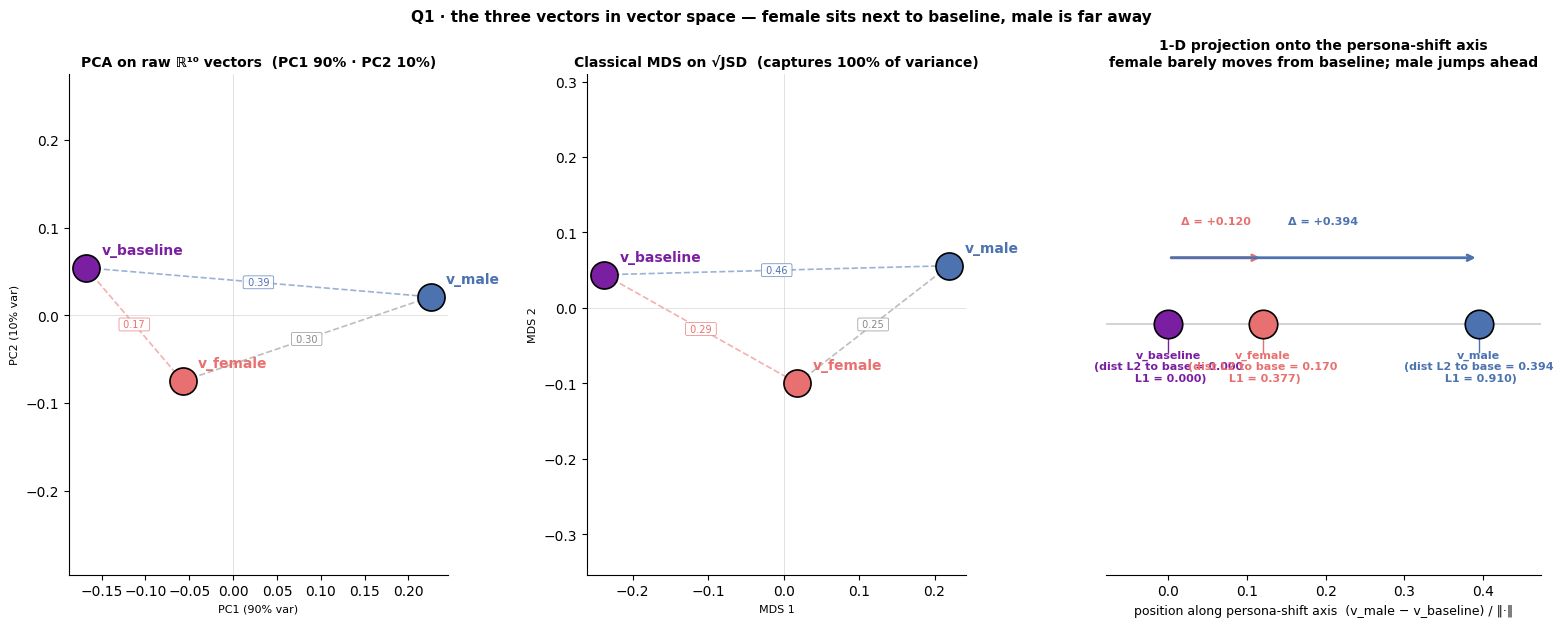


Euclidean (L2) distance to v_baseline:
  v_baseline   → L2 = 0.000   L1 = 0.000
  v_female     → L2 = 0.170   L1 = 0.377
  v_male       → L2 = 0.394   L1 = 0.910

Projection onto persona-shift axis (unit vector along v_male − v_baseline):
  v_baseline   → +0.000
  v_female     → +0.120
  v_male       → +0.394

  ‖v_male   − v_baseline‖₂ = 0.394
  ‖v_female − v_baseline‖₂ = 0.170
  ratio (male / female) = 2.32×


In [ ]:
# ── 13.8  Viz F — the three vectors in a real 2D vector space ────────────

BASE_C   = "#7B1FA2"
MALE_C   = "#4C72B0"
FEMALE_C = "#E97070"

three = {
    "v_baseline": (v_baseline, BASE_C),
    "v_female":   (v_female,   FEMALE_C),
    "v_male":     (v_male,     MALE_C),
}
names  = list(three.keys())
Vmat   = np.stack([three[n][0] for n in names], axis=0)       # (3, 10)
colors = [three[n][1] for n in names]

# ── PCA on the three merged vectors ───────────────────────────────────────
Vc      = Vmat - Vmat.mean(axis=0, keepdims=True)
U, S, Vt = np.linalg.svd(Vc, full_matrices=False)
pca_xy  = U[:, :2] * S[:2]
var_pct = (S ** 2) / (S ** 2).sum() * 100

# ── Classical MDS on √JSD across the three vectors ────────────────────────
Djsd = np.array([[_jsd(a, b) for b in Vmat] for a in Vmat])
D    = np.sqrt(np.clip(Djsd, 0, None))
D2   = D ** 2
J    = np.eye(3) - np.ones((3, 3)) / 3
B    = -0.5 * J @ D2 @ J
w, Vv = np.linalg.eigh(B)
order = np.argsort(w)[::-1]
w     = np.clip(w[order], 0, None)
Vv    = Vv[:, order]
mds_xy = Vv[:, :2] * np.sqrt(w[:2])
mds_pct = (w[:2].sum() / max(w.sum(), 1e-12)) * 100

# ── 1D projection along persona-shift axis (v_male − v_baseline) ─────────
axis   = v_male - v_baseline
axis_n = axis / (np.linalg.norm(axis) + 1e-12)
proj_1d = np.array([np.dot(three[n][0] - v_baseline, axis_n) for n in names])
# distance to baseline along raw direction (not just projected)
euclid_to_base = np.array([_l2(three[n][0], v_baseline) for n in names])
l1_to_base     = np.array([_l1(three[n][0], v_baseline) for n in names])


# ── Plot ──────────────────────────────────────────────────────────────────
fig = plt.figure(figsize=(19, 6.5))
gs  = fig.add_gridspec(1, 3, width_ratios=[1.0, 1.0, 1.15], wspace=0.35)
ax_pca = fig.add_subplot(gs[0, 0])
ax_mds = fig.add_subplot(gs[0, 1])
ax_line= fig.add_subplot(gs[0, 2])

fig.suptitle(
    "Q1 · the three vectors in vector space — female sits next to baseline, male is far away",
    fontsize=11, fontweight="bold"
)


def _draw_2d(ax, coords, title, xlabel, ylabel):
    # dashed connectors baseline↔female, baseline↔male, female↔male
    edge_list = [
        ("v_baseline", "v_female", FEMALE_C),
        ("v_baseline", "v_male",   MALE_C),
        ("v_female",   "v_male",   "#888888"),
    ]
    for a, b, c in edge_list:
        i, j = names.index(a), names.index(b)
        ax.plot(
            [coords[i, 0], coords[j, 0]],
            [coords[i, 1], coords[j, 1]],
            "--", color=c, alpha=0.55, linewidth=1.2, zorder=2,
        )
        # midpoint distance label
        mid = (coords[i] + coords[j]) / 2
        d = np.linalg.norm(coords[i] - coords[j])
        ax.text(mid[0], mid[1], f" {d:.2f} ",
                fontsize=7, color=c, ha="center", va="center",
                bbox=dict(boxstyle="round,pad=0.15", fc="white", ec=c, lw=0.5, alpha=0.9),
                zorder=3)

    # points
    for i, name in enumerate(names):
        ax.scatter(coords[i, 0], coords[i, 1], color=colors[i],
                   s=380, edgecolor="black", linewidth=1.2, zorder=5)
        ax.annotate(name, (coords[i, 0], coords[i, 1]),
                    xytext=(11, 10), textcoords="offset points",
                    fontsize=10, color=colors[i], fontweight="bold")

    ax.axhline(0, color="#DDD", linewidth=0.6, zorder=1)
    ax.axvline(0, color="#DDD", linewidth=0.6, zorder=1)
    ax.set_title(title, fontsize=10, fontweight="bold")
    ax.set_xlabel(xlabel, fontsize=8)
    ax.set_ylabel(ylabel, fontsize=8)
    ax.spines["top"].set_visible(False)
    ax.spines["right"].set_visible(False)
    ax.set_aspect("equal", adjustable="datalim")


_draw_2d(
    ax_pca, pca_xy,
    f"PCA on raw ℝ¹⁰ vectors  (PC1 {var_pct[0]:.0f}% · PC2 {var_pct[1]:.0f}%)",
    f"PC1 ({var_pct[0]:.0f}% var)", f"PC2 ({var_pct[1]:.0f}% var)"
)
_draw_2d(
    ax_mds, mds_xy,
    f"Classical MDS on √JSD  (captures {mds_pct:.0f}% of variance)",
    "MDS 1", "MDS 2"
)


# ── Right panel: 1D "distance to baseline" number line ───────────────────
y0 = 1.0
ax_line.axhline(y0, color="#CCC", linewidth=1.2, zorder=1)

# baseline anchor at x=0
for i, name in enumerate(names):
    x = proj_1d[i]
    ax_line.scatter(x, y0, color=colors[i], s=420, edgecolor="black",
                    linewidth=1.2, zorder=5)
    ax_line.annotate(
        f"{name}\n(dist L2 to base = {euclid_to_base[i]:.3f}\n L1 = {l1_to_base[i]:.3f})",
        (x, y0), xytext=(0, -18), textcoords="offset points",
        ha="center", va="top", fontsize=8, color=colors[i], fontweight="bold"
    )
    # vertical drop lines for clarity
    ax_line.plot([x, x], [y0 - 0.05, y0], color=colors[i], linewidth=1.0, zorder=3)

# arrows from baseline to female / male on the line
i_b, i_f, i_m = names.index("v_baseline"), names.index("v_female"), names.index("v_male")
for j, c in [(i_f, FEMALE_C), (i_m, MALE_C)]:
    ax_line.annotate(
        "",
        xy=(proj_1d[j], y0 + 0.12), xytext=(proj_1d[i_b], y0 + 0.12),
        arrowprops=dict(arrowstyle="->", color=c, lw=2.0)
    )
    ax_line.text((proj_1d[i_b] + proj_1d[j]) / 2, y0 + 0.18,
                 f"Δ = {proj_1d[j] - proj_1d[i_b]:+.3f}",
                 ha="center", fontsize=8, color=c, fontweight="bold")

ax_line.set_xlim(min(proj_1d) - 0.08, max(proj_1d) + 0.08)
ax_line.set_ylim(0.55, 1.45)
ax_line.set_yticks([])
ax_line.set_xlabel("position along persona-shift axis  (v_male − v_baseline) / ‖·‖", fontsize=9)
ax_line.set_title(
    "1-D projection onto the persona-shift axis\n"
    "female barely moves from baseline; male jumps ahead",
    fontsize=10, fontweight="bold"
)
for spine in ["top", "right", "left"]:
    ax_line.spines[spine].set_visible(False)

plt.tight_layout(rect=[0, 0, 1, 0.95])
fig.savefig(FIGURES_DIR / "q1_gender_vector_space.png", bbox_inches="tight", dpi=150)
plt.show()
plt.close(fig)

print(f"\nEuclidean (L2) distance to v_baseline:")
for i, n in enumerate(names):
    print(f"  {n:12s} → L2 = {euclid_to_base[i]:.3f}   L1 = {l1_to_base[i]:.3f}")

print(f"\nProjection onto persona-shift axis (unit vector along v_male − v_baseline):")
for i, n in enumerate(names):
    print(f"  {n:12s} → {proj_1d[i]:+.3f}")
print(f"\n  ‖v_male   − v_baseline‖₂ = {euclid_to_base[names.index('v_male')]:.3f}")
print(f"  ‖v_female − v_baseline‖₂ = {euclid_to_base[names.index('v_female')]:.3f}")
print(f"  ratio (male / female) = "
      f"{euclid_to_base[names.index('v_male')] / max(euclid_to_base[names.index('v_female')], 1e-9):.2f}×")

### 14.1 — Viz E (Q2): "look, they're the same" — female overlaid on baseline

Same visual as 13.7 but for **Q2 broad fields** (11 dimensions).

- **Top panel** — the three vectors as connected lines over the 11 broad-field axes.
- **Bottom-left** — `v_female_q2` overlaid on `v_baseline_q2` with residual band.
- **Bottom-right** — same for `v_male_q2`.

/var/folders/bq/hdtlcyk572l9dklh54vxrpg80000gn/T/ipykernel_35752/3670295587.py:104: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout(rect=[0, 0, 1, 0.94])
/var/folders/bq/hdtlcyk572l9dklh54vxrpg80000gn/T/ipykernel_35752/3787743250.py:2: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


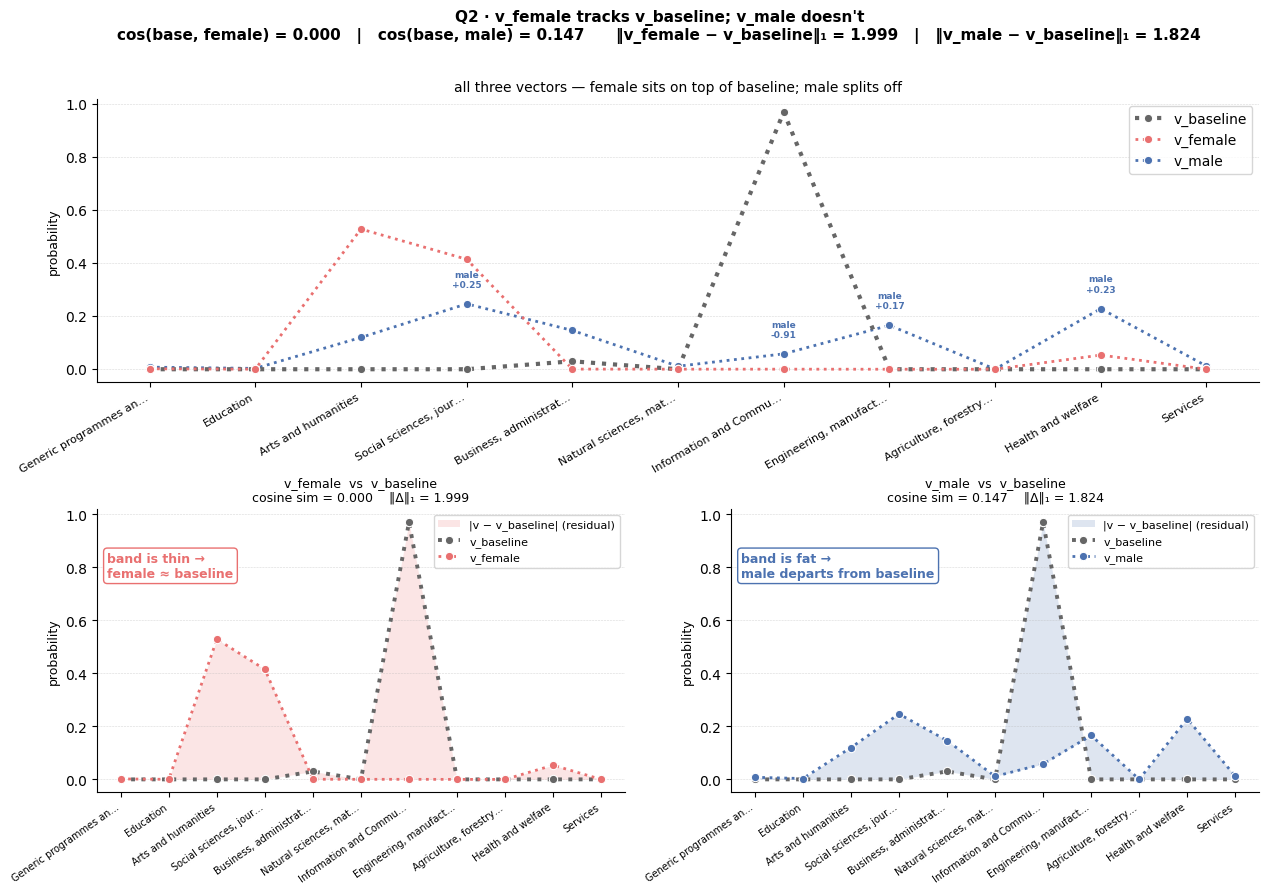

In [ ]:
# ── 14.1  Viz E (Q2) — female overlaid on baseline ───────────────────────

Q2_LEVELS = levels_q2   # 11 broad fields

# build Q2 vectors (same pattern as 13.1 but for broad_field / Q2)
v_baseline_q2 = _merged_prob_vec(df_b_q2, "broad_field", Q2_LEVELS)

df_f_male_q2   = df_f_q2[df_f_q2["true_gender"].astype(str).str.lower() == "male"]
df_f_female_q2 = df_f_q2[df_f_q2["true_gender"].astype(str).str.lower() == "female"]

v_male_q2   = _merged_prob_vec(df_f_male_q2,   "broad_field", Q2_LEVELS)
v_female_q2 = _merged_prob_vec(df_f_female_q2, "broad_field", Q2_LEVELS)

BASE_C   = "#666666"
MALE_C   = "#4C72B0"
FEMALE_C = "#E97070"

def _short2(lbl, n=22):
    return lbl if len(lbl) <= n else lbl[: n - 1] + "…"

labels_short_q2 = [_short2(l) for l in Q2_LEVELS]
xi_q2 = np.arange(len(Q2_LEVELS))

cos_bf_q2 = _cosine(v_baseline_q2, v_female_q2)
cos_bm_q2 = _cosine(v_baseline_q2, v_male_q2)
l1_bf_q2  = _l1(v_baseline_q2, v_female_q2)
l1_bm_q2  = _l1(v_baseline_q2, v_male_q2)

fig = plt.figure(figsize=(15, 9))
gs  = fig.add_gridspec(2, 2, height_ratios=[1.0, 1.0], hspace=0.45, wspace=0.2)
ax_top  = fig.add_subplot(gs[0, :])
ax_fem  = fig.add_subplot(gs[1, 0])
ax_male = fig.add_subplot(gs[1, 1], sharey=ax_fem)

fig.suptitle(
    "Q2 · v_female tracks v_baseline; v_male doesn't\n"
    f"cos(base, female) = {cos_bf_q2:.3f}   |   cos(base, male) = {cos_bm_q2:.3f}      "
    f"‖v_female − v_baseline‖₁ = {l1_bf_q2:.3f}   |   ‖v_male − v_baseline‖₁ = {l1_bm_q2:.3f}",
    fontsize=11, fontweight="bold"
)

# ── TOP ───────────────────────────────────────────────────────────────────
def _line(ax, v, c, lbl, lw=2.2, alpha=1.0, marker="o", zorder=3):
    ax.plot(xi_q2, v, color=c, lw=lw, alpha=alpha, linestyle=":", marker=marker,
            markersize=6, markeredgecolor="white", markeredgewidth=0.8,
            label=lbl, zorder=zorder)

_line(ax_top, v_baseline_q2, BASE_C,   "v_baseline", lw=3.0, zorder=4)
_line(ax_top, v_female_q2,   FEMALE_C, "v_female",   lw=2.0, zorder=5)
_line(ax_top, v_male_q2,     MALE_C,   "v_male",     lw=2.0, zorder=3)

ax_top.set_xticks(xi_q2)
ax_top.set_xticklabels(labels_short_q2, rotation=30, ha="right", fontsize=8)
ax_top.set_ylabel("probability", fontsize=9)
ax_top.set_title("all three vectors — female sits on top of baseline; male splits off",
                 fontsize=10)
ax_top.grid(axis="y", linestyle="--", linewidth=0.4, alpha=0.5)
ax_top.spines["top"].set_visible(False)
ax_top.spines["right"].set_visible(False)
ax_top.legend(fontsize=10, loc="upper right")

for i, dm in enumerate(v_male_q2 - v_baseline_q2):
    if abs(dm) > 0.14:
        ax_top.annotate(
            f"male\n{dm:+.2f}", xy=(xi_q2[i], v_male_q2[i]),
            xytext=(0, 12), textcoords="offset points",
            ha="center", fontsize=6.5, color=MALE_C, fontweight="bold"
        )

# ── BOTTOM panels ─────────────────────────────────────────────────────────
def _overlay_panel(ax, v_top, top_c, top_lbl, cos_val, l1_val):
    ax.fill_between(xi_q2, v_baseline_q2, v_top,
                    color=top_c, alpha=0.18, linewidth=0,
                    label="|v − v_baseline| (residual)")
    _line(ax, v_baseline_q2, BASE_C, "v_baseline", lw=2.8, zorder=4)
    _line(ax, v_top,         top_c,  top_lbl,      lw=2.0, zorder=5)
    ax.set_xticks(xi_q2)
    ax.set_xticklabels(labels_short_q2, rotation=35, ha="right", fontsize=7)
    ax.set_ylabel("probability", fontsize=9)
    ax.set_title(
        f"{top_lbl}  vs  v_baseline\n"
        f"cosine sim = {cos_val:.3f}    ‖Δ‖₁ = {l1_val:.3f}",
        fontsize=9
    )
    ax.grid(axis="y", linestyle="--", linewidth=0.4, alpha=0.5)
    ax.spines["top"].set_visible(False)
    ax.spines["right"].set_visible(False)
    ax.legend(fontsize=8, loc="upper right")

_overlay_panel(ax_fem,  v_female_q2, FEMALE_C, "v_female", cos_bf_q2, l1_bf_q2)
_overlay_panel(ax_male, v_male_q2,   MALE_C,   "v_male",   cos_bm_q2, l1_bm_q2)

ax_fem.text(
    0.02, 0.85, "band is thin →\nfemale ≈ baseline",
    transform=ax_fem.transAxes, fontsize=9, color=FEMALE_C, fontweight="bold", va="top",
    bbox=dict(boxstyle="round,pad=0.3", fc="white", ec=FEMALE_C, lw=1),
)
ax_male.text(
    0.02, 0.85, "band is fat →\nmale departs from baseline",
    transform=ax_male.transAxes, fontsize=9, color=MALE_C, fontweight="bold", va="top",
    bbox=dict(boxstyle="round,pad=0.3", fc="white", ec=MALE_C, lw=1),
)

plt.tight_layout(rect=[0, 0, 1, 0.94])
_save(fig, FIGURES_DIR / "q2_gender_vec_female_tracks_baseline.png")

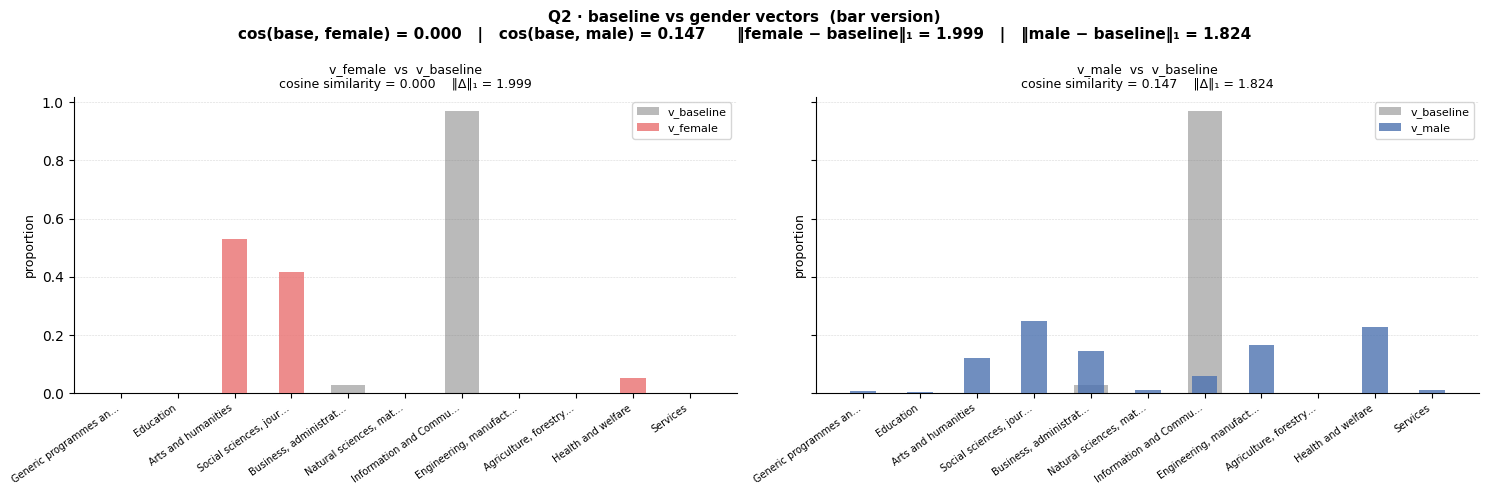

In [ ]:
# ── 14.2  Viz E (Q2, bar version) — overlapping bars, female and male vs baseline ──
fig, (ax_fem, ax_male) = plt.subplots(1, 2, figsize=(15, 5), sharey=True)

fig.suptitle(
    "Q2 · baseline vs gender vectors  (bar version)\n"
    f"cos(base, female) = {cos_bf_q2:.3f}   |   cos(base, male) = {cos_bm_q2:.3f}      "
    f"‖female − baseline‖₁ = {l1_bf_q2:.3f}   |   ‖male − baseline‖₁ = {l1_bm_q2:.3f}",
    fontsize=11, fontweight="bold"
)

def _bar_panel_q2(ax, v_top, top_c, top_lbl, cos_val, l1_val):
    ax.bar(xi_q2, v_baseline_q2, width=0.6,  color=BASE_C, alpha=0.45, label="v_baseline", zorder=2)
    ax.bar(xi_q2, v_top,         width=0.45, color=top_c,  alpha=0.80, label=top_lbl,      zorder=3)
    ax.set_xticks(xi_q2)
    ax.set_xticklabels(labels_short_q2, rotation=35, ha="right", fontsize=7)
    ax.set_ylabel("proportion", fontsize=9)
    ax.set_title(
        f"{top_lbl}  vs  v_baseline\n"
        f"cosine similarity = {cos_val:.3f}    ‖Δ‖₁ = {l1_val:.3f}",
        fontsize=9
    )
    ax.grid(axis="y", linestyle="--", linewidth=0.4, alpha=0.5)
    ax.spines["top"].set_visible(False)
    ax.spines["right"].set_visible(False)
    ax.legend(fontsize=8, loc="upper right")

_bar_panel_q2(ax_fem,  v_female_q2, FEMALE_C, "v_female", cos_bf_q2, l1_bf_q2)
_bar_panel_q2(ax_male, v_male_q2,   MALE_C,   "v_male",   cos_bm_q2, l1_bm_q2)

plt.tight_layout(rect=[0, 0, 1, 0.93])
_save(fig, FIGURES_DIR / "q2_gender_vec_overlay_bars.png")


### 15. Region vector analysis — Q1 & Q2

Three complementary views of how each region's probability vector compares to the no-persona baseline.

- **Viz R1 — Residual heatmap**: rows = regions, cols = group levels, colour = `v_region − v_baseline`. Compact overview of all regions at once.
- **Viz R2 — Fan chart**: baseline as a thick grey line; all region vectors as thin coloured lines overlaid, with a min–max envelope shaded. Shows the spread without 15 individual panels.
- **Viz R3 — Small multiples**: one overlay panel per region, same layout as the bottom panels in Viz E. Residual band = `v_region − v_baseline`.

Q1 regions: 8   Q2 regions: 8


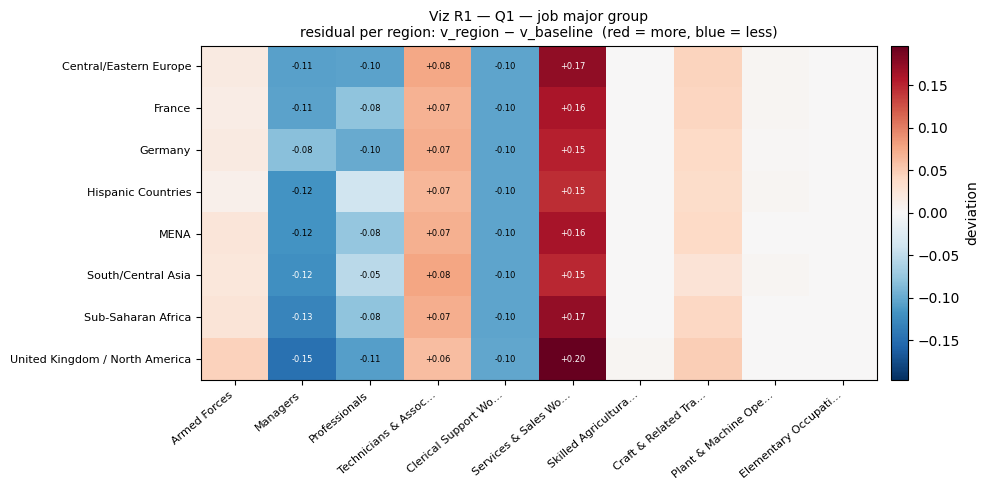

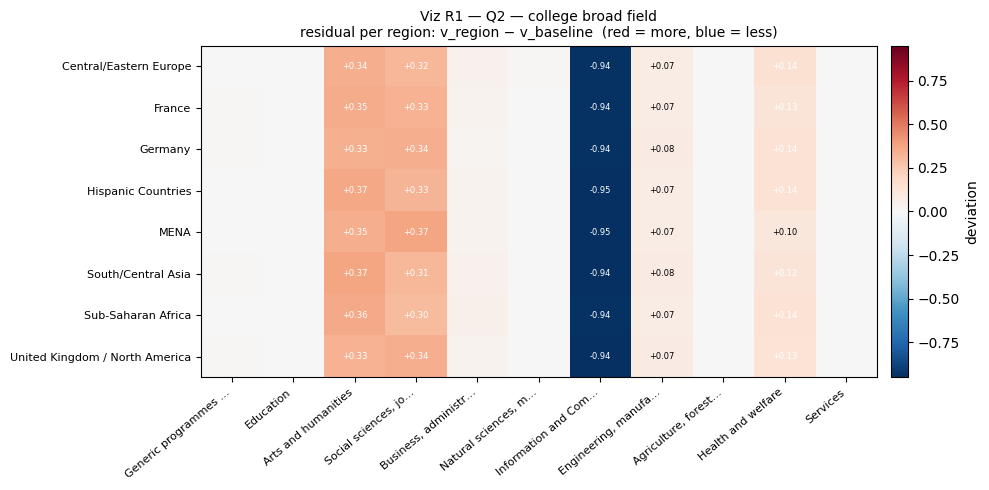

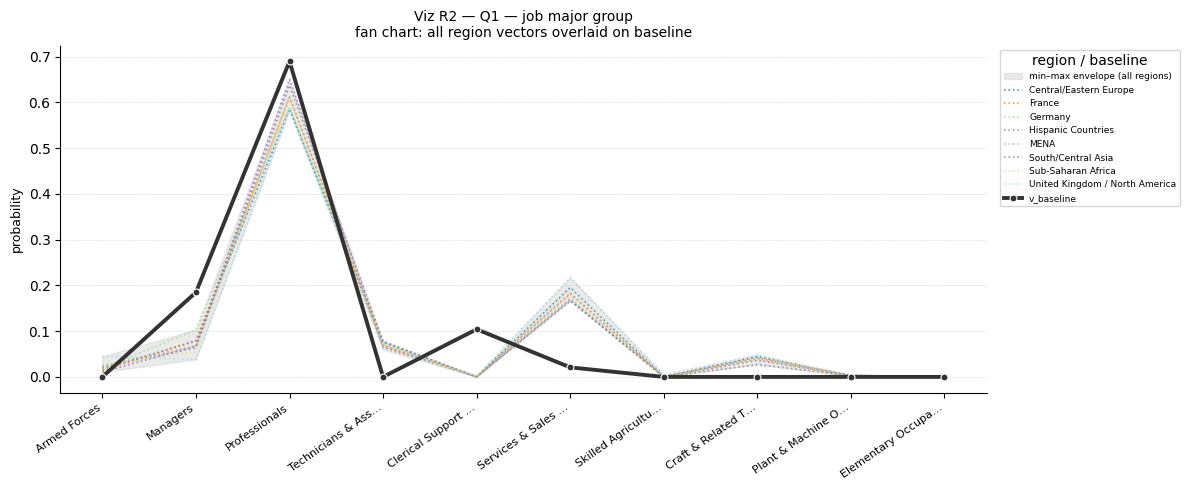

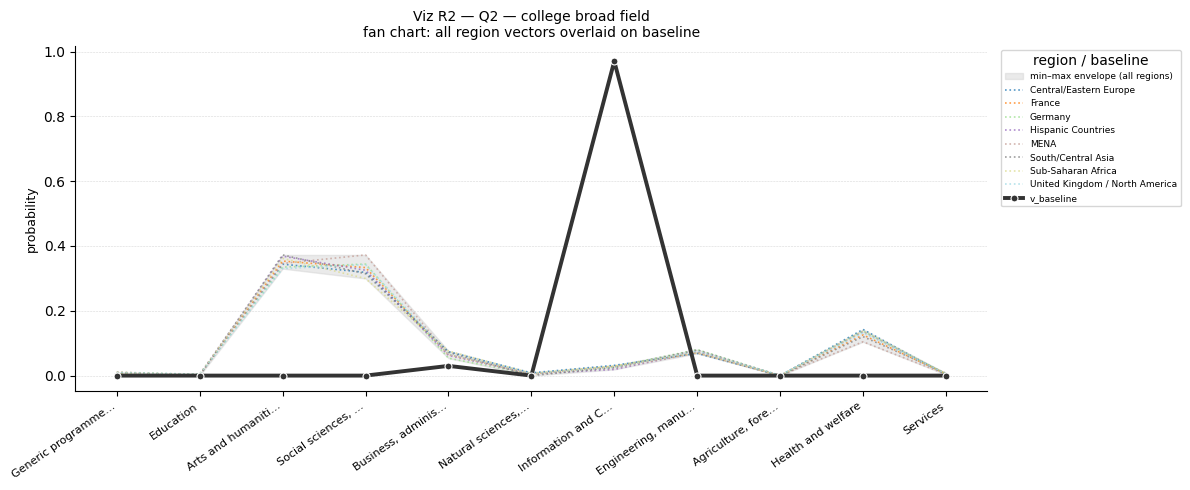

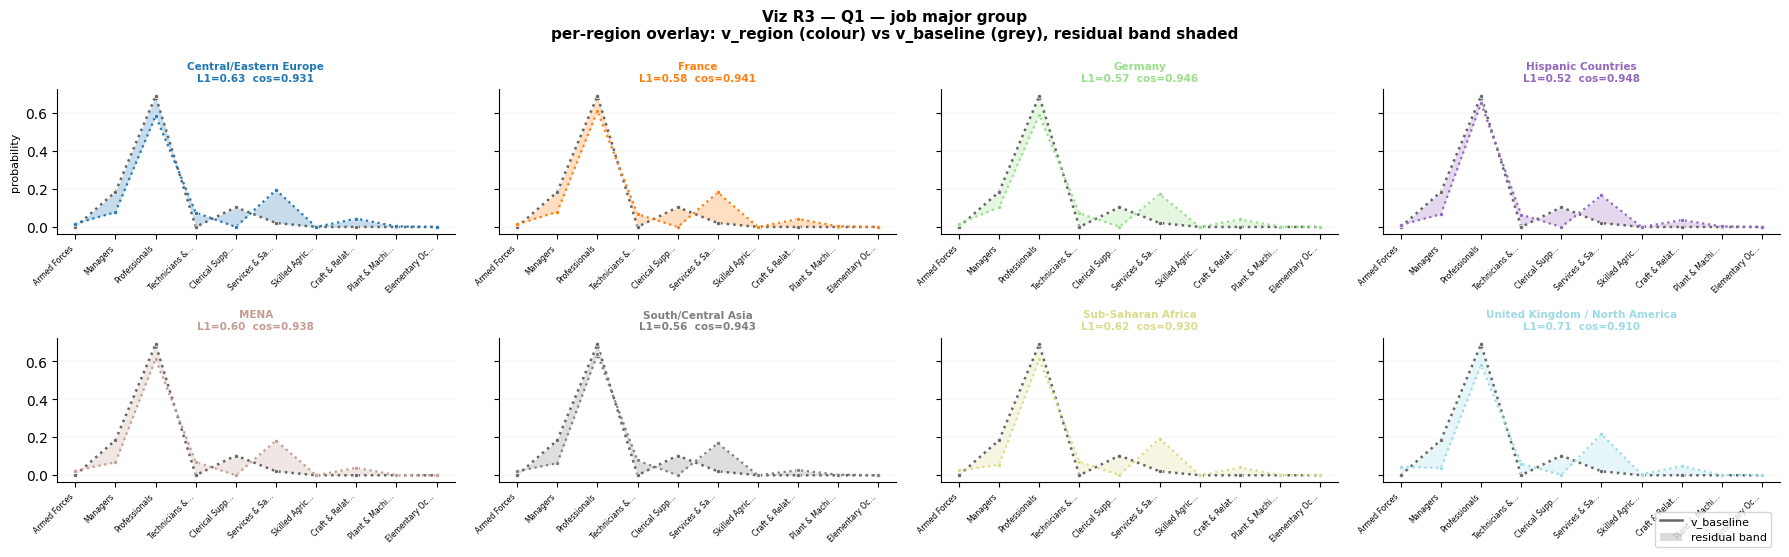

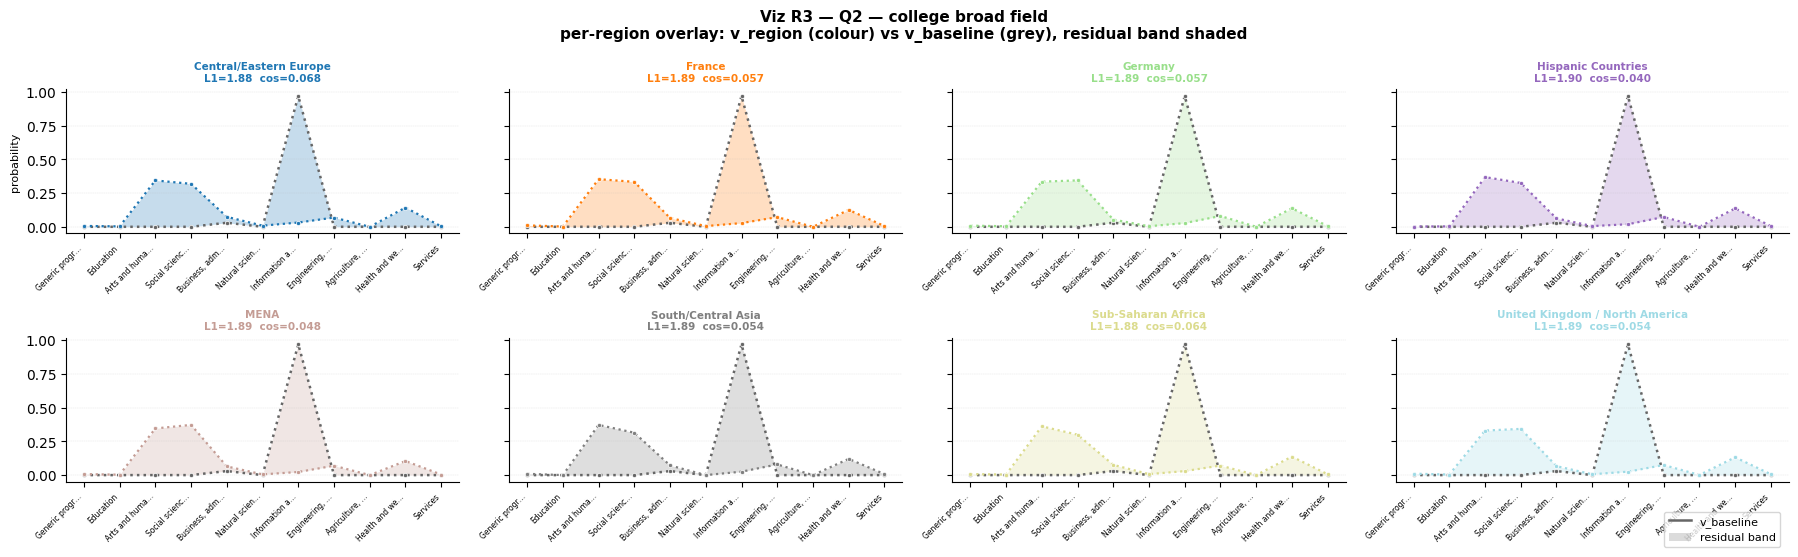

In [ ]:
# ── 15.  Region vector analysis helpers ──────────────────────────────────

def _region_vectors(df_f, group_col, levels):
    """
    Returns dict: region → probability vector (np.ndarray, length=len(levels)).
    Merged across BASELINE_MODELS (equal model weight).
    """
    regions = sorted(df_f["true_race"].dropna().unique())
    vecs = {}
    for reg in regions:
        sub = df_f[df_f["true_race"] == reg]
        vecs[reg] = _merged_prob_vec(sub, group_col, levels, models=BASELINE_MODELS)
    return vecs

# build per-region vectors for Q1 and Q2
region_vecs_q1 = _region_vectors(df_f_q1, "major_group", levels_q1)
region_vecs_q2 = _region_vectors(df_f_q2, "broad_field",  levels_q2)

print(f"Q1 regions: {len(region_vecs_q1)}   Q2 regions: {len(region_vecs_q2)}")

# ── Viz R1 — Residual heatmap ─────────────────────────────────────────────
for q_label, vecs, v_base, levels in [
    ("Q1 — job major group",     region_vecs_q1, v_baseline,    levels_q1),
    ("Q2 — college broad field", region_vecs_q2, v_baseline_q2, levels_q2),
]:
    regions = list(vecs.keys())
    mat = np.array([vecs[r] - v_base for r in regions])   # (n_regions, n_levels)

    # short axis labels
    short_lvls = [l if len(l) <= 20 else l[:19] + "…" for l in levels]

    fig, ax = plt.subplots(figsize=(max(10, len(levels) * 0.9), max(5, len(regions) * 0.45)))
    vmax = np.abs(mat).max()
    im = ax.imshow(mat, aspect="auto", cmap="RdBu_r", vmin=-vmax, vmax=vmax)
    ax.set_xticks(range(len(levels)))
    ax.set_xticklabels(short_lvls, rotation=40, ha="right", fontsize=8)
    ax.set_yticks(range(len(regions)))
    ax.set_yticklabels(regions, fontsize=8)
    ax.set_title(f"Viz R1 — {q_label}\nresidual per region: v_region − v_baseline  (red = more, blue = less)",
                 fontsize=10)
    plt.colorbar(im, ax=ax, fraction=0.03, pad=0.02, label="deviation")
    # annotate cells with value if |dev| > 0.05
    for ri in range(len(regions)):
        for ci in range(len(levels)):
            v = mat[ri, ci]
            if abs(v) > 0.05:
                ax.text(ci, ri, f"{v:+.2f}", ha="center", va="center",
                        fontsize=6, color="white" if abs(v) > 0.12 else "black")
    q_slug = "q1" if "Q1" in q_label else "q2"
    _save(fig, FIGURES_DIR / f"{q_slug}_region_residual_heatmap.png")


# ── Viz R2 — Fan chart ────────────────────────────────────────────────────
REGION_CMAP = plt.cm.tab20

for q_label, vecs, v_base, levels in [
    ("Q1 — job major group",     region_vecs_q1, v_baseline,    levels_q1),
    ("Q2 — college broad field", region_vecs_q2, v_baseline_q2, levels_q2),
]:
    regions = list(vecs.keys())
    mat     = np.array([vecs[r] for r in regions])   # (n_regions, n_levels)
    xi      = np.arange(len(levels))
    short_lvls = [l if len(l) <= 18 else l[:17] + "…" for l in levels]

    fig, ax = plt.subplots(figsize=(max(12, len(levels) * 0.9), 5))

    # min-max envelope across all regions
    env_lo = mat.min(axis=0)
    env_hi = mat.max(axis=0)
    ax.fill_between(xi, env_lo, env_hi, color="#CCCCCC", alpha=0.4,
                    label="min–max envelope (all regions)", zorder=1)

    # individual region lines
    for ri, reg in enumerate(regions):
        ax.plot(xi, mat[ri], color=REGION_CMAP(ri / max(len(regions) - 1, 1)),
                linewidth=1.2, linestyle=":", alpha=0.75, label=reg, zorder=2)

    # baseline on top
    ax.plot(xi, v_base, color="#333333", linewidth=2.8, zorder=5,
            marker="o", markersize=5, markeredgecolor="white", markeredgewidth=0.8,
            label="v_baseline")

    ax.set_xticks(xi)
    ax.set_xticklabels(short_lvls, rotation=35, ha="right", fontsize=8)
    ax.set_ylabel("probability", fontsize=9)
    ax.set_title(f"Viz R2 — {q_label}\nfan chart: all region vectors overlaid on baseline",
                 fontsize=10)
    ax.grid(axis="y", linestyle="--", linewidth=0.4, alpha=0.5)
    ax.spines["top"].set_visible(False)
    ax.spines["right"].set_visible(False)
    ax.legend(fontsize=6.5, bbox_to_anchor=(1.01, 1), loc="upper left",
              ncol=1, title="region / baseline")

    q_slug = "q1" if "Q1" in q_label else "q2"
    _save(fig, FIGURES_DIR / f"{q_slug}_region_fan_chart.png")


# ── Viz R3 — Small multiples (one overlay panel per region) ───────────────
for q_label, vecs, v_base, levels in [
    ("Q1 — job major group",     region_vecs_q1, v_baseline,    levels_q1),
    ("Q2 — college broad field", region_vecs_q2, v_baseline_q2, levels_q2),
]:
    regions    = list(vecs.keys())
    n_regions  = len(regions)
    ncols      = 4
    nrows      = int(np.ceil(n_regions / ncols))
    xi         = np.arange(len(levels))
    short_lvls = [l if len(l) <= 14 else l[:13] + "…" for l in levels]

    fig, axes = plt.subplots(nrows, ncols,
                              figsize=(ncols * 4.5, nrows * 2.8),
                              sharey=True)
    fig.suptitle(
        f"Viz R3 — {q_label}\nper-region overlay: v_region (colour) vs v_baseline (grey), residual band shaded",
        fontsize=11, fontweight="bold"
    )
    axes_flat = axes.flatten()

    for ri, reg in enumerate(regions):
        ax  = axes_flat[ri]
        v_r = vecs[reg]
        col = REGION_CMAP(ri / max(n_regions - 1, 1))

        # residual band
        ax.fill_between(xi, v_base, v_r, color=col, alpha=0.25,
                        linewidth=0, label="residual")
        # baseline
        ax.plot(xi, v_base, color="#666666", linewidth=1.8, linestyle=":", zorder=4,
                marker="o", markersize=3, markeredgecolor="white", markeredgewidth=0.5)
        # region vector
        ax.plot(xi, v_r, color=col, linewidth=1.6, linestyle=":", zorder=5,
                marker="o", markersize=3, markeredgecolor="white", markeredgewidth=0.5)

        l1_dev = float(np.abs(v_r - v_base).sum())
        cos_s  = _cosine(v_base, v_r)
        ax.set_title(f"{reg}\nL1={l1_dev:.2f}  cos={cos_s:.3f}",
                     fontsize=7.5, color=col, fontweight="bold")
        ax.set_xticks(xi)
        ax.set_xticklabels(short_lvls, rotation=45, ha="right", fontsize=5.5)
        ax.grid(axis="y", linestyle="--", linewidth=0.3, alpha=0.4)
        ax.spines["top"].set_visible(False)
        ax.spines["right"].set_visible(False)

    # hide unused panels
    for ri in range(n_regions, len(axes_flat)):
        axes_flat[ri].set_visible(False)

    axes_flat[0].set_ylabel("probability", fontsize=8)
    # shared legend
    from matplotlib.lines import Line2D
    from matplotlib.patches import Patch
    leg = [Line2D([0],[0], color="#666666", lw=1.8, label="v_baseline"),
           Patch(facecolor="#888888", alpha=0.3, label="residual band")]
    fig.legend(handles=leg, fontsize=8, loc="lower right", bbox_to_anchor=(0.99, 0.01))

    q_slug = "q1" if "Q1" in q_label else "q2"
    _save(fig, FIGURES_DIR / f"{q_slug}_region_small_multiples.png")

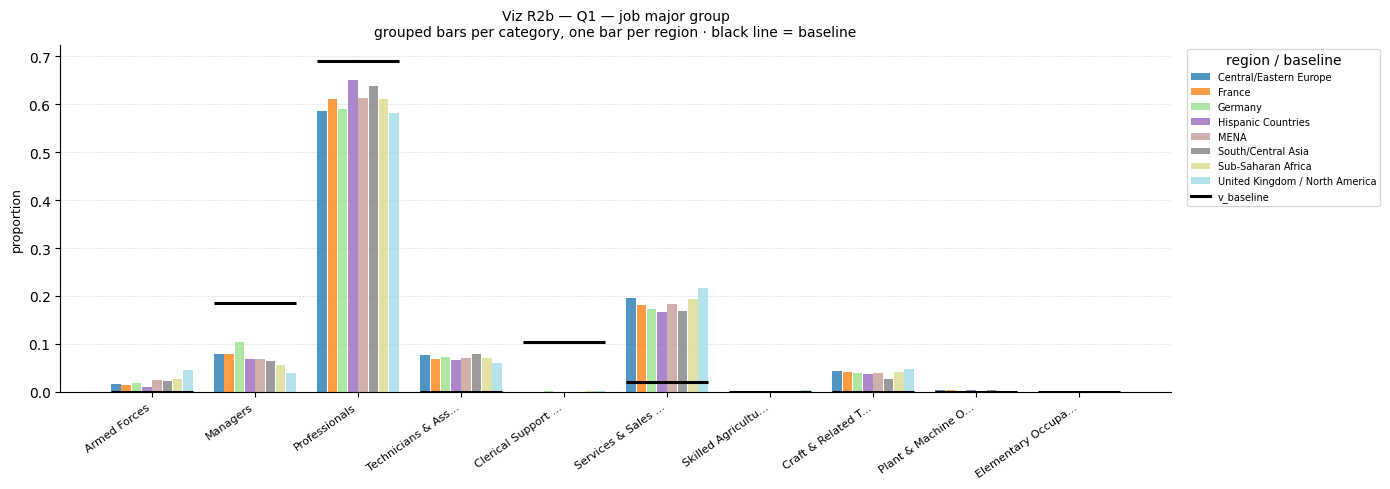

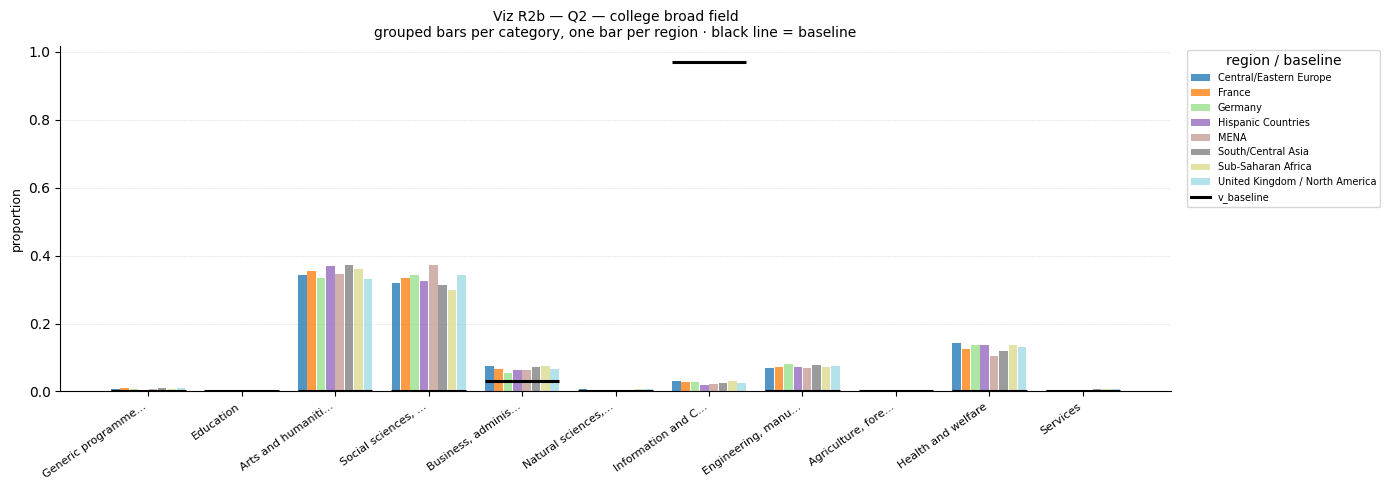

In [ ]:
# ── Viz R2b — Grouped bar chart (replaces fan chart trend lines) ──────────
# Each category = one group; one bar per region; baseline as horizontal tick per category

from matplotlib.lines import Line2D as _L2D

for q_label, vecs, v_base, levels in [
    ("Q1 — job major group",     region_vecs_q1, v_baseline,    levels_q1),
    ("Q2 — college broad field", region_vecs_q2, v_baseline_q2, levels_q2),
]:
    regions    = list(vecs.keys())
    n_reg      = len(regions)
    n_lev      = len(levels)
    mat        = np.array([vecs[r] for r in regions])   # (n_reg, n_lev)
    short_lvls = [l if len(l) <= 18 else l[:17] + "..." for l in levels]

    bar_w = 0.8 / n_reg          # total width 0.8 split across regions
    half  = 0.4                  # half-width of baseline tick = full group span
    xi    = np.arange(n_lev)

    fig, ax = plt.subplots(figsize=(max(14, n_lev * 1.1), 5))

    for ri, reg in enumerate(regions):
        offset = (ri - n_reg / 2 + 0.5) * bar_w
        color  = REGION_CMAP(ri / max(n_reg - 1, 1))
        ax.bar(xi + offset, mat[ri], width=bar_w * 0.92,
               color=color, alpha=0.78, label=reg, zorder=2)

    # baseline as a short horizontal line spanning each category group
    for i_lev, b_val in enumerate(v_base):
        ax.plot([xi[i_lev] - half, xi[i_lev] + half], [b_val, b_val],
                color="black", linewidth=2.2, solid_capstyle="butt", zorder=6)

    # legend: region bars + baseline tick
    region_handles, region_labels = ax.get_legend_handles_labels()
    baseline_handle = _L2D([0], [0], color="black", lw=2.2, label="v_baseline")
    ax.legend(handles=region_handles + [baseline_handle],
              labels=region_labels + ["v_baseline"],
              fontsize=7, bbox_to_anchor=(1.01, 1), loc="upper left",
              ncol=1, title="region / baseline")

    ax.set_xticks(xi)
    ax.set_xticklabels(short_lvls, rotation=35, ha="right", fontsize=8)
    ax.set_ylabel("proportion", fontsize=9)
    q_slug = "q1" if "Q1" in q_label else "q2"
    ax.set_title(
        "Viz R2b — " + q_label + "\ngrouped bars per category, one bar per region · black line = baseline",
        fontsize=10
    )
    ax.grid(axis="y", linestyle="--", linewidth=0.4, alpha=0.5)
    ax.spines["top"].set_visible(False)
    ax.spines["right"].set_visible(False)

    _save(fig, FIGURES_DIR / (q_slug + "_region_grouped_bars.png"))
